<img src = "https://drive.google.com/uc?export=view&id=1rSrsZ04aJ_D3BC67Cy2dBUZ6tmguydNf" alt = "Encabezado MLDS" width = "100%">  </img>

# **Preparación de los datos**
---

Este notebook es una plantilla que le puede servir como guía para el tercer entregable del proyecto aplicado.

## **0. Integrantes del equipo de trabajo**
---

Por favor incluya los nombres completos y número de identificación de los integrantes del equipo de trabajo:

1. ---**Alejandra Jaramillo Mejia**---
2. ---**Brayan Sebastian Yepes Garcia**---
3. ---**Santiago Chaparro Suzunaga**---

# ICARE

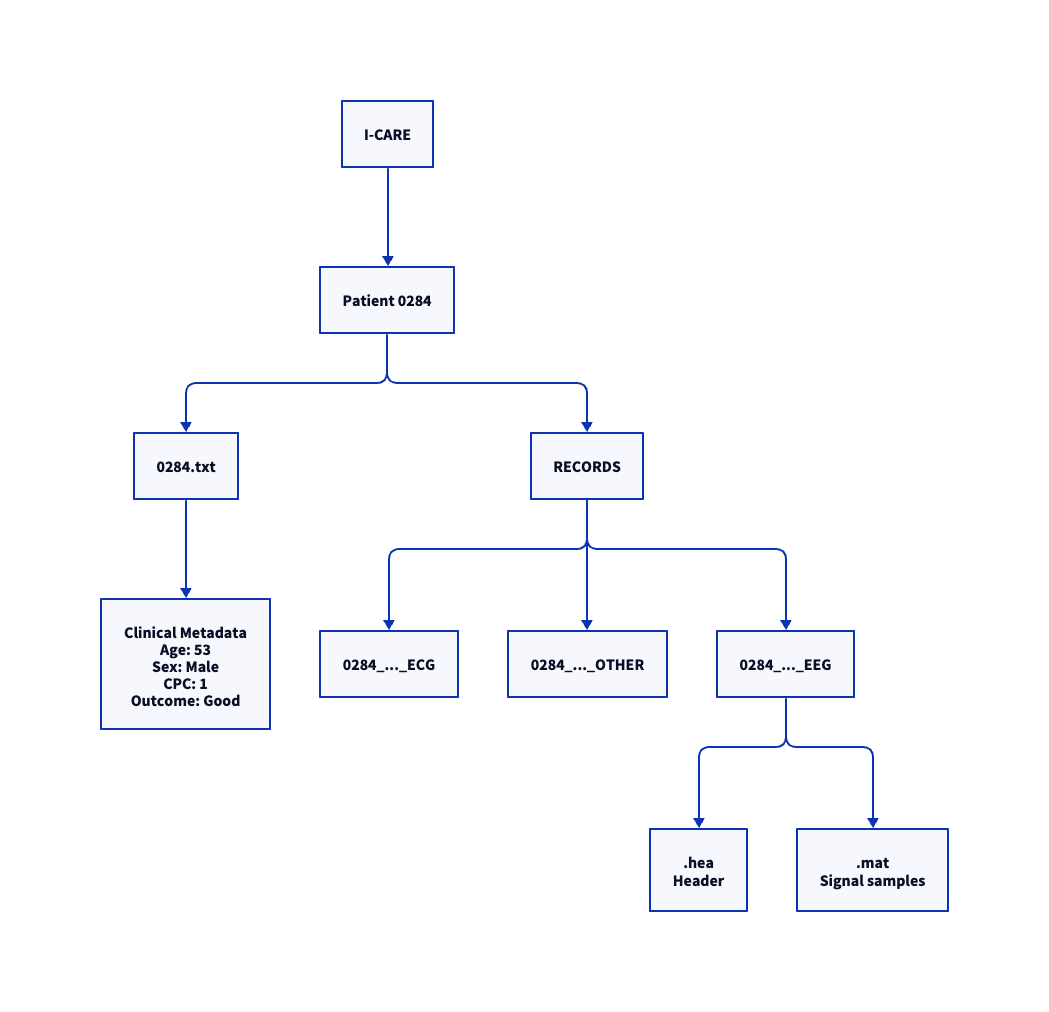

# Clinical

## **1. Limpieza de los Datos**
---

La elección de las técnicas de preprocesamiento puede diferir en cada conjunto de datos. Recuerde que es posible aplicar, según sea necesario (no necesariamente todas), las técnicas generales que se han explorado en el curso. La elección dependerá del tipo de datos con el que esté trabajando.

A lo largo de esta entrega, busque responder las siguientes preguntas:

- ¿Cuáles fueron los criterios utilizados para identificar y tratar valores atípicos, datos faltantes o cualquier otra anomalía en el conjunto de datos durante el proceso de limpieza?
- ¿Cómo se justificaría la necesidad de cada paso de preprocesamiento en términos de mejora de la calidad de los datos y preparación para el análisis subsiguiente?

A continuación encontrará los puntos a tratar a medida que va realizando la preparación de los datos. En cada punto defina el estado en que se encontraba el dataset, ademas de explicar y justificar las acciones y decisiones que se tomaron.

### **1.1. Valores faltantes**
---
Al encontrarnos con valores faltantes en el conjunto de datos, es crucial preguntarse:
* ¿Cómo afectan estos valores a la integridad y representatividad de la información?
* ¿Cómo se identificaron los valores faltantes en el conjunto de datos?
* ¿Cuáles fueron los criterios para decidir si rellenar con valores estimados o eliminar los valores faltantes? En caso que aplique, ¿qué método de relleno se utilizó y por qué se consideró apropiado?
* ¿Se realizó un análisis de la distribución de los valores faltantes en relación con las variables clave? Por ejemplo, si hay valores faltantes en una variable crítica, ¿cómo podría afectar la interpretación de los resultados?

In [ ]:
import urllib3
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from matplotlib.patches import Patch
from pathlib import Path


In [2]:
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [3]:
BASE_URL = "https://physionet.org/files/i-care/2.1"
RECORDS_URL = f"{BASE_URL}/RECORDS"

# Sesión con reintentos automáticos para errores transitorios del servidor
# (502/503/504) y fallos de conexión, en vez de que todo el proceso se caiga
# por un solo paciente como pasó con el 0419.
session = requests.Session()
retries = Retry(
    total=5,
    backoff_factor=1.5,
    status_forcelist=[502, 503, 504],
    allowed_methods=["GET"],
)
session.mount("https://", HTTPAdapter(max_retries=retries))

# 1. Índice de pacientes
response = session.get(RECORDS_URL, verify=False,timeout=30)
response.raise_for_status()
records = response.text.splitlines()
patient_ids = [record.strip("/").split("/")[-1] for record in records]
print("Número de pacientes encontrados:", len(patient_ids))

# 2. Descarga y parseo del archivo clínico de cada paciente
patients = []
failed_patients = []

for i, pid in enumerate(patient_ids, start=1):
    url = f"{BASE_URL}/training/{pid}/{pid}.txt"
    try:
        response = session.get(url, verify=False, timeout=30)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Fallo definitivo en paciente {pid}: {e}")
        failed_patients.append(pid)
        continue

    data = {}
    for line in response.text.strip().splitlines():
        key, value = line.split(":", 1)
        data[key.strip()] = value.strip()
    patients.append(data)

    if i % 100 == 0:
        print(f"Progreso: {i}/{len(patient_ids)} pacientes descargados")

print(f"\nDescarga completa: {len(patients)} ok, {len(failed_patients)} fallidos")
assert len(failed_patients) == 0, f"Revisar pacientes fallidos: {failed_patients}"

# 3. Consolidación en un único DataFrame integrado
clinical_df = pd.DataFrame(patients)
clinical_df.to_csv("icare_clinical_data.csv", index=False)

clinical_df.head()

Número de pacientes encontrados: 607
Progreso: 100/607 pacientes descargados
Progreso: 200/607 pacientes descargados
Progreso: 300/607 pacientes descargados
Progreso: 400/607 pacientes descargados
Progreso: 500/607 pacientes descargados
Progreso: 600/607 pacientes descargados

Descarga completa: 607 ok, 0 fallidos


,Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,0284,A,53,Male,nan,True,True,33,Good,1
1,0286,F,85,Female,7,False,False,nan,Good,1
2,0296,A,48,Male,nan,True,True,36,Good,1
3,0299,A,45,Male,nan,True,True,33,Good,1
4,0303,D,51,Male,24,True,True,33,Good,1


In [4]:
clinical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Patient           607 non-null    str  
 1   Hospital          607 non-null    str  
 2   Age               607 non-null    str  
 3   Sex               607 non-null    str  
 4   ROSC              607 non-null    str  
 5   OHCA              607 non-null    str  
 6   Shockable Rhythm  607 non-null    str  
 7   TTM               607 non-null    str  
 8   Outcome           607 non-null    str  
 9   CPC               607 non-null    str  
dtypes: str(10)
memory usage: 47.6 KB


In [5]:
clinical_df.isnull().sum()

Patient             0
Hospital            0
Age                 0
Sex                 0
ROSC                0
OHCA                0
Shockable Rhythm    0
TTM                 0
Outcome             0
CPC                 0
dtype: int64

**Estado inicial del dataset antes de la conversión de tipos**

Al ejecutar `clinical_df.isnull().sum()` y `clinical_df.info()` justo después de la descarga, el resultado indica que las 10 columnas tienen 607 valores no nulos (0 valores faltantes en total) y que todas están almacenadas con tipo de dato `object` (texto).

Esto es engañoso y no significa que el dataset esté realmente completo ya que la forma en que se construyó `clinical_df` los datos provienen de archivos de texto plano de PhysioNet con formato `Variable: Value`, que se parsearon directamente a un diccionario y luego a un DataFrame, sin ninguna conversión de tipos todavía. En ese proceso, cualquier campo que en el archivo original no tenía valor quedó guardado como el texto literal `"nan"` (la palabra, como string), no como un valor nulo real de pandas.



Como `.isnull()` solo reconoce como faltante un `NaN` o `None` real, pero `"nan"` es una cadena de texto para Pandas, el conteo de nulos da 0 en todas las columnas.



**Ver todos los valores únicos de las variables numericas**

In [6]:
numeric_cols = ["Age", "ROSC", "TTM"]
for col in numeric_cols:
    valores_no_numericos = clinical_df.loc[
        pd.to_numeric(clinical_df[col], errors="coerce").isna(), col
    ].unique()
    print(f"{col}: valores no numéricos encontrados -> {valores_no_numericos}")

Age: valores no numéricos encontrados -> <StringArray>
['nan']
Length: 1, dtype: str
ROSC: valores no numéricos encontrados -> <StringArray>
['nan']
Length: 1, dtype: str
TTM: valores no numéricos encontrados -> <StringArray>
['nan']
Length: 1, dtype: str


Age: valores no numéricos encontrados -> ['nan'] significa que en la columna Age, el único valor que no se pudo convertir directamente a número es el texto "nan", es decir, algunos pacientes no tienen la edad registrada, y ese vacío quedó guardado como la palabra "nan" en vez de quedar realmente vacío. Lo mismo aplica para ROSC y TTM: en ambas, el único valor problemático es también "nan".

**Ver todos los valores únicos de las categóricas**

In [7]:
# Ver todos los valores únicos de las categóricas, para detectar cualquier código raro a simple vista
categorical_cols = ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]
for col in categorical_cols:
    print(f"{col}: {sorted(clinical_df[col].astype(str).unique())}")


Sex: ['Female', 'Male', 'nan']
Hospital: ['A', 'B', 'D', 'E', 'F']
OHCA: ['False', 'True', 'nan']
Shockable Rhythm: ['False', 'True', 'nan']
Outcome: ['Good', 'Poor']
CPC: ['1', '2', '3', '4', '5']


 Esto confirma que `Hospital`, `Outcome` y `CPC` no tienen valores faltantes, mientras que `Sex`, `OHCA` y `Shockable Rhythm` sí los tienen, codificados únicamente como el texto `"nan"`.

En conjunto, ambas verificaciones confirman que `"nan"` es el único código utilizado en todo el dataset para representar un valor faltante, no existen otros formatos ocultos que hayan podido pasar desapercibidos.

**Tratamiento de datos faltantes para las variables numericas**



Con la certeza de que `"nan"` es el único código de valor faltante presente en el dataset, se procede a convertir `Age`, `ROSC` y `TTM` a tipo numérico con `pd.to_numeric(..., errors="coerce")`.

Este método intenta convertir cada valor de la columna a número; cuando encuentra un valor que no puede convertir (en este caso, el texto `"nan"`), en vez de generar un error lo reemplaza automáticamente por un `NaN` real de pandas, reconocible por `.isnull()`.

El resultado (`clinical_df[numeric_cols].dtypes`) confirma que las tres columnas pasaron de `object` (texto) a `float64` (numérico decimal), quedando ya listas para calcular estadísticas, graficarlas y, en el conteo de nulos, reflejar por fin los valores faltantes reales que antes estaban ocultos como texto.

In [8]:
for col in numeric_cols:
    clinical_df[col] = pd.to_numeric(clinical_df[col], errors="coerce")

clinical_df[numeric_cols].dtypes

Age     float64
ROSC    float64
TTM     float64
dtype: object

Ahora revisemos como hacer el tratamiento de datos faltantes de los datos numericos

**Variable Age**

`Age` es una variable numérica continua que registra la edad del paciente en años. Presenta un único valor faltante sobre 607 registros, equivalente al 0.16% del conjunto, la menor proporción de todas las variables con datos incompletos.

En esta variable el tratamiento de faltantes involucra dos decisiones: si conservar o eliminar el registro afectado, y con qué estadístico realizar el relleno en caso de imputar. Cabe aclarar que `Age` presenta además una particularidad identificada en la Fase 2, la acumulación anómala de pacientes en el valor 90 producto de la censura por anonimización aplicada por los autores del conjunto de datos. 

In [9]:

n_total = len(clinical_df)
n_falt = clinical_df['Age'].isnull().sum()

print(f"Tipo de dato de Age: {clinical_df['Age'].dtype}")
print(f"Valores faltantes en Age: {n_falt} ({n_falt/n_total*100:.2f}%)\n")
print("Estadística descriptiva de Age (casos conocidos):")
print(clinical_df['Age'].describe().round(2).to_string())

print("\nPerfil del paciente sin dato de Age:")
print(clinical_df[clinical_df['Age'].isnull()][
    ['Patient', 'Hospital', 'Sex', 'OHCA', 'Shockable Rhythm', 'ROSC', 'Outcome', 'CPC']
].to_string(index=False))

Tipo de dato de Age: float64
Valores faltantes en Age: 1 (0.16%)

Estadística descriptiva de Age (casos conocidos):
count    606.00
mean      61.17
std       15.65
min       16.00
25%       52.00
50%       63.00
75%       72.00
max       90.00

Perfil del paciente sin dato de Age:
Patient Hospital Sex OHCA Shockable Rhythm  ROSC Outcome CPC
   0592        F nan True            False   NaN    Good   1


La conversión de `Age` a tipo numérico confirma 1 valor faltante (0.16%) sobre 607 pacientes.

El examen del registro afectado arroja tres observaciones relevantes.

En primer lugar, se trata del paciente 0592, cuya fila presenta también valores faltantes en `Sex` y en `ROSC`. Es el único paciente con un registro demográfico incompleto, lo que sugiere un problema puntual de captura del caso y no una deficiencia propia de la variable `Age`.

El paciente cuenta con la variable objetivo completa: registra `Outcome = Good` y `CPC = 1`, es decir, recuperación neurológica completa, junto con `Shockable Rhythm = False`. Esta combinación es poco frecuente en el conjunto, dado que únicamente el 17.3% de los pacientes sin ritmo desfibrilable alcanzan un desenlace favorable. Eliminar el registro implicaría perder uno de los 225 casos de la clase minoritaria `Good` y, adicionalmente, uno de los pocos casos que documentan esa combinación clínica particular, argumento que refuerza la decisión de imputar en lugar de descartar el registro.

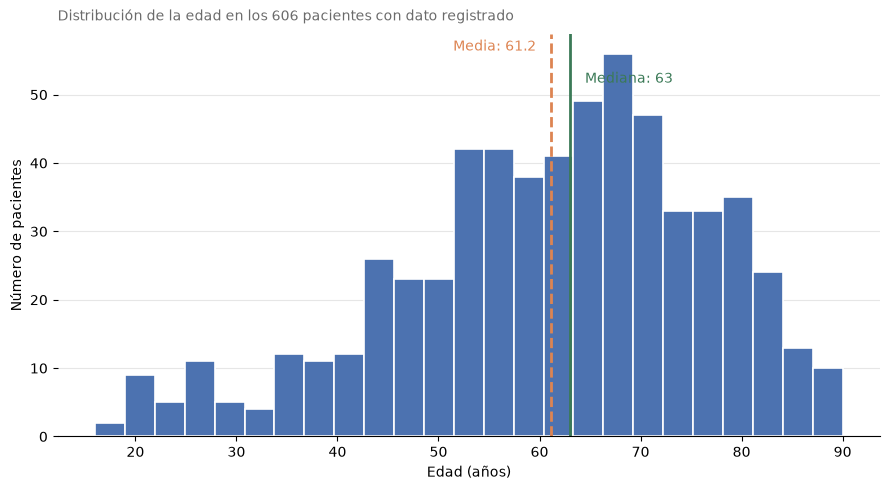

Asimetría (skew): -0.592
Media: 61.17  |  Mediana: 63.0  |  Diferencia: 1.83 años


In [10]:
edad = clinical_df['Age'].dropna()
media = edad.mean()
mediana = edad.median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(edad, bins=25, color='#4C72B0', edgecolor='white', linewidth=1.2)

ax.axvline(media, color='#DD8452', linestyle='--', linewidth=2)
ax.axvline(mediana, color='#3B7A57', linestyle='-', linewidth=2)

ymax = ax.get_ylim()[1]
ax.text(media - 1.5, ymax * 0.96, f'Media: {media:.1f}', color='#DD8452',
        ha='right', fontsize=10)
ax.text(mediana + 1.5, ymax * 0.88, f'Mediana: {mediana:.0f}', color='#3B7A57',
        ha='left', fontsize=10)


ax.text(0, 1.035,
        f'Distribución de la edad en los {len(edad)} pacientes con dato registrado',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Número de pacientes')
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Asimetría (skew): {edad.skew():.3f}")
print(f"Media: {media:.2f}  |  Mediana: {mediana:.1f}  |  Diferencia: {abs(media-mediana):.2f} años")

El histograma confirma que la distribución de `Age` no es simétrica. El coeficiente de asimetría es de -0.592, un valor negativo que indica un sesgo hacia la izquierda de magnitud moderada, es decir, una cola que se extiende hacia las edades menores mientras el grueso de los datos se concentra en el extremo superior.

Visualmente esto se traduce en que la mayor densidad de pacientes se ubica entre los 50 y los 85 años, con el pico en el rango de 65 a 70, mientras que por debajo de los 45 años los casos son escasos y dispersos, extendiéndose hasta un mínimo de 16 años. Debido a lo anterior, la cola de pacientes jóvenes es la que arrastra la media hacia abajo.

La consecuencia directa se observa al comparar las dos medidas de tendencia central: la media es de 61.17 años y la mediana de 63.0, una diferencia de 1.83 años en la que la media queda por debajo de la mediana. En una distribución perfectamente simétrica ambos valores coincidirían, y su separación es precisamente la manifestación numérica del sesgo.

Por este motivo se seleccionó la **mediana** como estadístico de imputación. En distribuciones asimétricas la mediana constituye el estimador robusto de tendencia central, ya que depende de la posición central de los datos y no de la magnitud de los valores extremos, mientras que la media se desplaza en dirección a la cola y resulta menos representativa del paciente típico de la cohorte.

Cabe señalar adicionalmente que parte de esta asimetría es de origen artificial: la censura por anonimización aplicada por los autores del conjunto agrupa en el valor 90 a todos los pacientes mayores de 89 años, lo que trunca la cola derecha de la distribución y acentúa el sesgo negativo observado. Esta particularidad se aborda en detalle en la sección de valores atípicos.

In [11]:
escenarios = {
    'Sin tratar (n=606)': clinical_df['Age'].dropna(),
    'Eliminando el registro (n=606)': clinical_df['Age'].dropna(),
    'Imputando con la mediana (n=607)': clinical_df['Age'].fillna(clinical_df['Age'].median()),
    'Imputando con la media (n=607)': clinical_df['Age'].fillna(clinical_df['Age'].mean()),
}

resumen = pd.DataFrame({
    nombre: {
        'n': int(serie.count()),
        'Media': round(serie.mean(), 2),
        'Mediana': round(serie.median(), 2),
        'Desv. estándar': round(serie.std(), 2),
    }
    for nombre, serie in escenarios.items()
}).T

print("Efecto de cada alternativa de tratamiento sobre la distribución de Age:\n")
print(resumen.to_string())

Efecto de cada alternativa de tratamiento sobre la distribución de Age:

                                      n  Media  Mediana  Desv. estándar
Sin tratar (n=606)                606.0  61.17     63.0           15.65
Eliminando el registro (n=606)    606.0  61.17     63.0           15.65
Imputando con la mediana (n=607)  607.0  61.17     63.0           15.64
Imputando con la media (n=607)    607.0  61.17     63.0           15.64


Respecto al análisis del faltante frente a variables clave, el paciente afectado cuenta con información completa en el resto de las variables del conjunto, incluida la variable objetivo `Outcome`. Y la decisión de tratamiento se fundamenta en el efecto que cada alternativa produce sobre la distribución de la variable.

**Criterio de decisión y tratamiento aplicado para `Age`**

Se aplicó **imputación con la mediana (63 años)**, decisión que responde a dos criterios independientes.

El primero es si conservar o eliminar el registro. El análisis de sensibilidad muestra que la media, la mediana y la desviación estándar de `Age` permanecen prácticamente idénticas bajo cualquiera de las alternativas, por lo que la decisión resulta indiferente en términos de la distribución de la variable. Siendo así, el criterio pasa a ser preservar la mayor cantidad de información posible: eliminar el registro implicaría descartar también los datos completos de ese paciente en `Shockable Rhythm`, `OHCA`, `ROSC` y `Outcome`, sacrificando información valiosa a cambio de ningún beneficio.

El segundo criterio es con qué estadístico rellenar. Se optó por la mediana en lugar de la media porque la distribución de `Age` no es simétrica: presenta un sesgo hacia las edades menores, con valores atípicos de pacientes jóvenes por debajo de los 20 años y una acumulación artificial en el extremo superior producto de la censura en 90 años. En distribuciones asimétricas y con valores extremos, la mediana es el estimador robusto de tendencia central, mientras que la media se desplaza en dirección a los valores extremos y resulta menos representativa del paciente típico del conjunto.

In [12]:
mediana_age = clinical_df['Age'].median()
clinical_df['Age'] = clinical_df['Age'].fillna(mediana_age)

print(f"Imputación aplicada con la mediana: {mediana_age:.0f} años\n")
print("Estadística descriptiva final de Age:")
print(clinical_df['Age'].describe().round(2).to_string())

print(f"\nValores faltantes restantes en Age: {clinical_df['Age'].isnull().sum()}")
assert clinical_df['Age'].isnull().sum() == 0, "Aún quedan faltantes en Age"
print("Verificación superada: la variable Age no contiene valores faltantes.")

Imputación aplicada con la mediana: 63 años

Estadística descriptiva final de Age:
count    607.00
mean      61.17
std       15.64
min       16.00
25%       52.00
50%       63.00
75%       72.00
max       90.00

Valores faltantes restantes en Age: 0
Verificación superada: la variable Age no contiene valores faltantes.


**Variable `ROSC`**



`ROSC` (Return of Spontaneous Circulation) es una variable numérica continua que registra el tiempo transcurrido, en minutos, hasta el retorno de la circulación espontánea del paciente. Presenta 304 valores faltantes sobre 607 registros, equivalentes al 50.1% del conjunto, la proporción más alta de todo el dataset.

Este caso requiere un tratamiento distinto al de `Age`. Cuando la mitad de los valores de una variable están ausentes, la decisión no se limita a elegir un estadístico de relleno, sino que debe evaluarse previamente si la imputación es siquiera un procedimiento apropiado, dado que rellenar 304 registros implicaría que la mitad del contenido de la variable sería información generada artificialmente y no observada.

El análisis se estructura en cuatro pasos:
* Determinar el origen del faltante.
* Evaluar si su ausencia lleva información propia respecto al desenlace.
* Verificar si dicha asociación es genuina o está confundida por otra variable.
* Cuantificar el efecto que tendría la imputación sobre la distribución.




1. ¿Los pacientes sin dato presentan un desenlace distinto al de los demás?
2. Si es así, ¿esa diferencia se debe realmente a la ausencia del dato o a algún otro factor?
3. ¿Qué ocurre al controlar ese factor?
4. ¿Es viable imputar los valores faltantes?

In [13]:
clinical_df['ROSC'] = pd.to_numeric(clinical_df['ROSC'], errors='coerce')

n_total = len(clinical_df)
n_falt = clinical_df['ROSC'].isnull().sum()

print(f"Pacientes totales: {n_total}")
print(f"Pacientes sin dato de ROSC: {n_falt} ({n_falt/n_total*100:.1f}%)")
print(f"Pacientes con dato de ROSC: {n_total - n_falt}\n")

print("Estadística descriptiva de los casos con dato:")
print(clinical_df['ROSC'].describe().round(2).to_string())
print(f"\nAsimetría: {clinical_df['ROSC'].skew():.2f}   Curtosis: {clinical_df['ROSC'].kurt():.2f}")

Pacientes totales: 607
Pacientes sin dato de ROSC: 304 (50.1%)
Pacientes con dato de ROSC: 303

Estadística descriptiva de los casos con dato:
count    303.00
mean      23.27
std       18.79
min        1.00
25%       10.00
50%       19.00
75%       30.00
max      111.00

Asimetría: 1.85   Curtosis: 4.21




Solo 303 de los 607 pacientes cuentan con el dato. Entre ellos, el tiempo hasta la recuperación de la circulación tiene una mediana de 19 minutos y una media de 23.27, con valores que van de 1 a 111 minutos.

La asimetría de 1.85 y la curtosis de 4.21 indican una distribución con la mayoría de los casos en tiempos cortos y una cola larga de reanimaciones prolongadas. Por eso la media supera a la mediana en más de cuatro minutos: los casos extremos la arrastran hacia arriba.

Primera pregunta: ¿los pacientes sin dato presentan un desenlace distinto?

Antes de decidir cómo tratar los registros ausentes se debe verificar si corresponden a pacientes comparables al resto o si constituyen un grupo con características propias. La forma de comprobarlo es comparar el desenlace neurológico de ambos grupos.

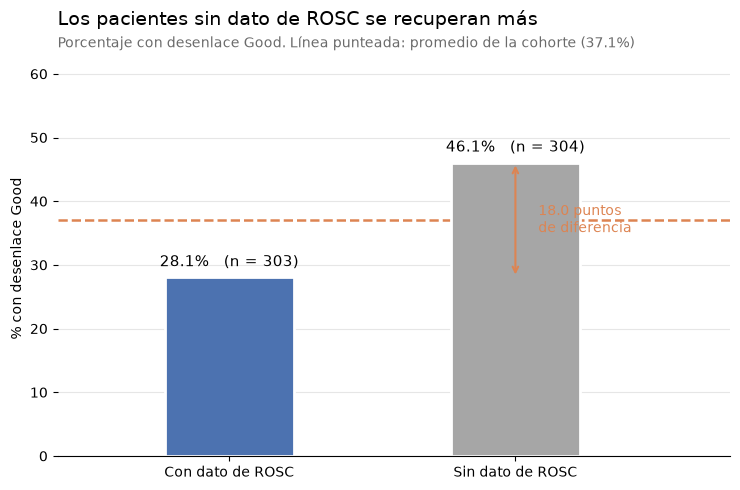

In [14]:
grupo = clinical_df['ROSC'].isnull().map({False: 'Con dato', True: 'Sin dato'})
tabla = pd.crosstab(grupo, clinical_df['Outcome']).reindex(['Con dato', 'Sin dato'])
pct_good = tabla['Good'] / tabla.sum(axis=1) * 100
conteos = tabla.sum(axis=1)
baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(7.5, 5))
barras = ax.bar(['Con dato de ROSC', 'Sin dato de ROSC'], pct_good.values, width=0.45,
                color=['#4C72B0', '#A6A6A6'], edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.2,
            f'{pct:.1f}%   (n = {int(n)})', ha='center', va='bottom', fontsize=10.5)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)
ax.annotate('', xy=(1, pct_good['Sin dato']), xytext=(1, pct_good['Con dato']),
            arrowprops=dict(arrowstyle='<->', color='#DD8452', lw=1.5))
ax.text(1.08, (pct_good['Sin dato'] + pct_good['Con dato'])/2,
        f"{pct_good['Sin dato'] - pct_good['Con dato']:.1f} puntos\nde diferencia",
        fontsize=10, color='#DD8452', va='center')

ax.set_title('Los pacientes sin dato de ROSC se recuperan más',
             fontsize=13.5, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje con desenlace Good. Línea punteada: promedio de la cohorte ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, 62)
ax.set_xlim(-0.6, 1.75)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

Respuesta: sí, pero el resultado no tiene sentido clínico

Los pacientes sin dato de `ROSC` presentan un 46.1% de desenlaces favorables, frente a un 28.1% entre quienes sí lo tienen. Una diferencia de 18 puntos porcentuales.

Interpretado de forma literal, este resultado afirmaría que no tener el dato registrado mejora el pronóstico del paciente, lo cual es imposible: la omisión de un campo en un formulario no puede influir en la recuperación neurológica de nadie.

Cuando una comparación arroja un resultado sin sentido, la explicación habitual es que los dos grupos comparados difieren en algo más además de la característica que se está evaluando.

Segunda pregunta: ¿de dónde provienen los registros sin dato?

Si los pacientes sin dato no están repartidos de forma homogénea entre los hospitales, entonces la comparación anterior podría estar midiendo diferencias entre instituciones en lugar del efecto del dato ausente.

Disponibilidad de ROSC y desenlace por hospital:
              n  % sin dato ROSC  % Good
Hospital                                
A         261.0            100.0    46.7
B         120.0              0.0    28.3
D          83.0             26.5    32.5
E          74.0              2.7    20.3
F          69.0             27.5    39.1


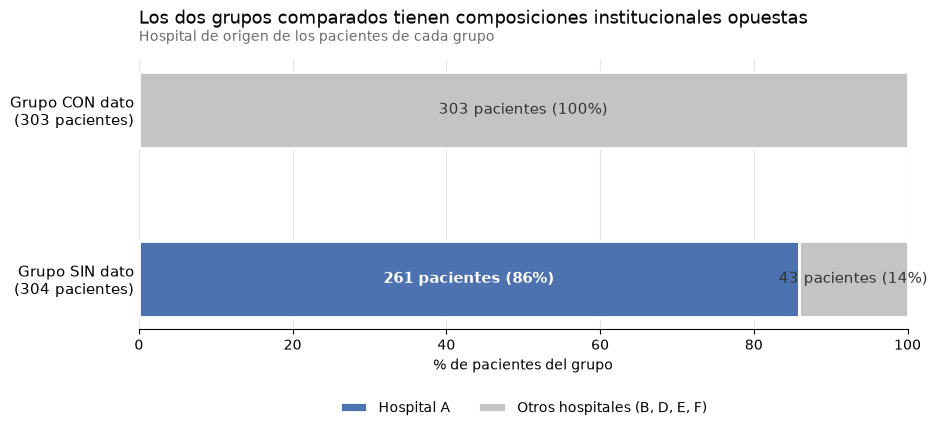

In [15]:
print("Disponibilidad de ROSC y desenlace por hospital:")
resumen_hosp = clinical_df.groupby('Hospital').apply(
    lambda g: pd.Series({
        'n': len(g),
        '% sin dato ROSC': g['ROSC'].isnull().mean() * 100,
        '% Good': (g['Outcome'] == 'Good').mean() * 100,
    }), include_groups=False
).round(1)
print(resumen_hosp.to_string())

# Composición de cada grupo según su hospital de origen
es_A = clinical_df['Hospital'] == 'A'
n_con = (grupo == 'Con dato').sum()
n_sin = (grupo == 'Sin dato').sum()
a_con = ((grupo == 'Con dato') & es_A).sum()
a_sin = ((grupo == 'Sin dato') & es_A).sum()

pct_a = [a_con/n_con*100, a_sin/n_sin*100]
pct_otros = [(n_con-a_con)/n_con*100, (n_sin-a_sin)/n_sin*100]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
y = [0, 1]
ax.barh(y, pct_a, 0.45, label='Hospital A', color='#4C72B0', edgecolor='white', linewidth=2)
ax.barh(y, pct_otros, 0.45, left=pct_a, label='Otros hospitales (B, D, E, F)',
        color='#C4C4C4', edgecolor='white', linewidth=2)

datos = [(pct_a[0], pct_otros[0], a_con, n_con-a_con, 0),
         (pct_a[1], pct_otros[1], a_sin, n_sin-a_sin, 1)]
for pa, po, na, no, i in datos:
    if pa > 5:
        ax.text(pa/2, i, f'{na} pacientes ({pa:.0f}%)', ha='center', va='center',
                fontsize=10.5, color='white', weight='bold')
    if po > 5:
        ax.text(pa + po/2, i, f'{no} pacientes ({po:.0f}%)', ha='center', va='center',
                fontsize=10.5, color='#333333')

ax.set_yticks(y)
ax.set_yticklabels([f'Grupo CON dato\n({n_con} pacientes)', f'Grupo SIN dato\n({n_sin} pacientes)'],
                   fontsize=10.5)
ax.set_xlim(0, 100)
ax.set_xlabel('% de pacientes del grupo')
ax.invert_yaxis()
ax.set_title('Los dos grupos comparados tienen composiciones institucionales opuestas',
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.07, 'Hospital de origen de los pacientes de cada grupo',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.xaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2)

plt.tight_layout()
plt.show()

Respuesta: los faltantes provienen casi en su totalidad de un solo hospital

| Hospital | n | % sin dato de ROSC | % desenlace Good |
|---|---|---|---|
| A | 261 | 100.0% | 46.7% |
| B | 120 | 0.0% | 28.3% |
| D | 83 | 26.5% | 32.5% |
| E | 74 | 2.7% | 20.3% |
| F | 69 | 27.5% | 39.1% |

El Hospital A no registra esta variable en ninguno de sus 261 pacientes, mientras que el Hospital B la registra en los 120 suyos. No se trata de omisiones aisladas sino de una diferencia de protocolo entre instituciones.

La consecuencia se aprecia en el gráfico de composición: el grupo con dato no contiene ni un solo paciente del Hospital A, mientras que el grupo sin dato está formado en un 86% por pacientes de esa institución. Los dos grupos que se compararon en la primera pregunta no eran por lo tanto comparables entre sí.

Y aquí aparece el elemento decisivo: el Hospital A es además el que presenta el mejor desenlace de todo el conjunto, con 46.7% de recuperaciones favorables frente a un rango de 20.3% a 39.1% en los demás centros.

Esto significa que la comparación inicial no medía el efecto de la ausencia del dato, sino en gran medida el de pertenecer al Hospital A. La condición "no tener dato de ROSC" estaba funcionando como un sustituto de la condición "ser paciente del Hospital A".

¿Tercera pregunta: ¿qué ocurre si se elimina ese factor?

Si la diferencia la produjera realmente el dato ausente, excluir un hospital del análisis no debería alterarla de forma apreciable. Si en cambio la producía el Hospital A, la diferencia debería reducirse al retirarlo.

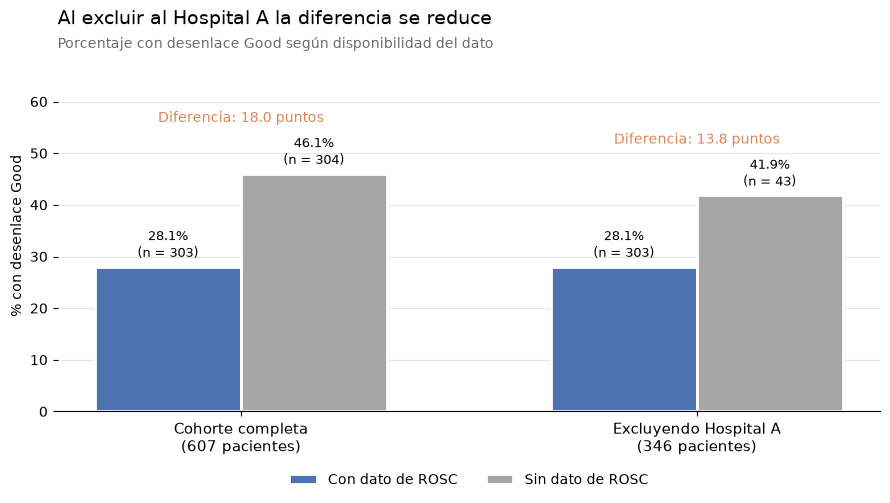

In [16]:
def desenlace_por_disponibilidad(df):
    g = df['ROSC'].isnull().map({False: 'Con dato', True: 'Sin dato'})
    t = pd.crosstab(g, df['Outcome']).reindex(['Con dato', 'Sin dato'])
    return (t['Good'] / t.sum(axis=1) * 100), t.sum(axis=1)

pct_full, n_full = desenlace_por_disponibilidad(clinical_df)
sin_A = clinical_df[clinical_df['Hospital'] != 'A']
pct_sinA, n_sinA = desenlace_por_disponibilidad(sin_A)

x = np.arange(2)
w = 0.32
con = [pct_full['Con dato'], pct_sinA['Con dato']]
sin = [pct_full['Sin dato'], pct_sinA['Sin dato']]
n_con_l = [n_full['Con dato'], n_sinA['Con dato']]
n_sin_l = [n_full['Sin dato'], n_sinA['Sin dato']]

fig, ax = plt.subplots(figsize=(9, 5.2))
b1 = ax.bar(x - w/2, con, w, label='Con dato de ROSC', color='#4C72B0',
            edgecolor='white', linewidth=2)
b2 = ax.bar(x + w/2, sin, w, label='Sin dato de ROSC', color='#A6A6A6',
            edgecolor='white', linewidth=2)

for barras, enes in ((b1, n_con_l), (b2, n_sin_l)):
    for barra, n in zip(barras, enes):
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, alto + 1.0,
                f'{alto:.1f}%\n(n = {int(n)})', ha='center', va='bottom', fontsize=9.5)

for i, (c, s) in enumerate(zip(con, sin)):
    ax.text(i, max(c, s) + 10, f'Diferencia: {s-c:.1f} puntos',
            ha='center', fontsize=10, color='#DD8452')

ax.set_title('Al excluir al Hospital A la diferencia se reduce',
             fontsize=13.5, pad=26, loc='left')
ax.text(0, 1.035, 'Porcentaje con desenlace Good según disponibilidad del dato',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_xticks(x)
ax.set_xticklabels(['Cohorte completa\n(607 pacientes)',
                    f'Excluyendo Hospital A\n({len(sin_A)} pacientes)'], fontsize=10.5)
ax.set_ylim(0, 68)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2)

plt.tight_layout()
plt.show()

Respuesta: parte de la diferencia se explica por el hospital, y el resto no puede evaluarse

Al excluir al Hospital A, la diferencia baja de 18 a 13.8 puntos porcentuales, quedando repartida en dos porciones.

Los 4.2 puntos que desaparecen corresponden al Hospital A. La atribución es inequívoca porque el grupo con dato no cambió entre ambos escenarios, ya que ninguno de esos 303 pacientes pertenecía a esa institución. Queda confirmado que parte del efecto aparente venía del hospital y no del dato ausente.

Los 13.8 puntos restantes no pueden evaluarse, porque ahora se calculan sobre 43 pacientes en lugar de 304. Con ese tamaño, cada paciente vale 2.3 puntos del resultado, de modo que el cambio de desenlace de tres casos bastaría para reducir la diferencia a la mitad. No se afirma que sea inexistente, sino que la muestra es demasiado pequeña para saberlo.

Cuarta pregunta: ¿es viable imputar los valores faltantes?

Descartado que el faltante tenga significado propio, queda por resolver si conviene rellenarlo. Para decidirlo se compara la distribución real de la variable con la que resultaría después de imputar.

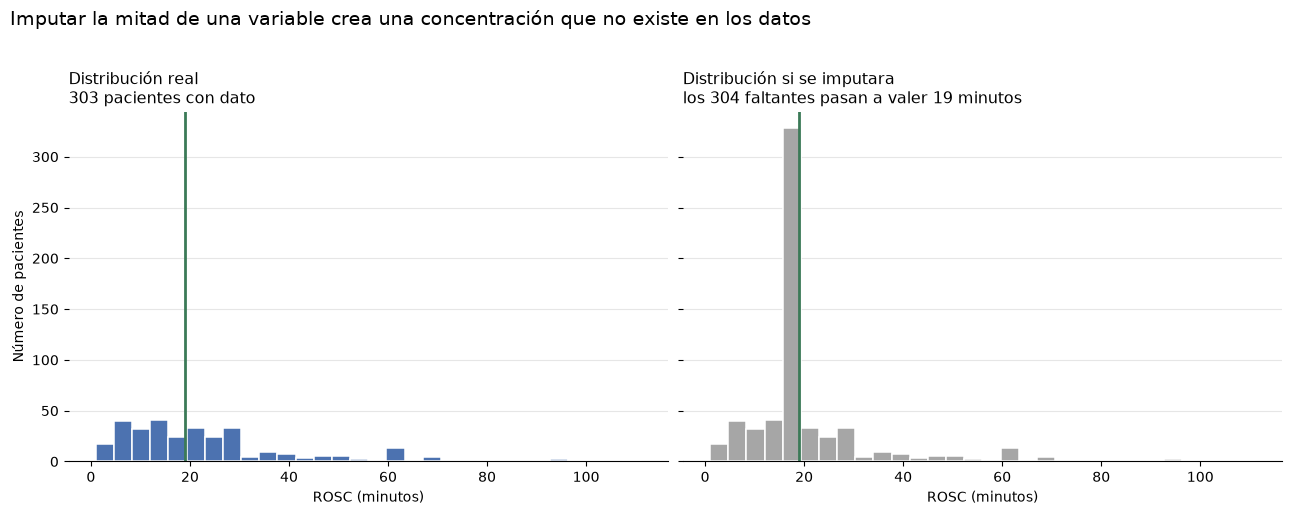

Desviación estándar real: 18.79
Desviación estándar tras imputar: 13.44
Pérdida de variabilidad: 28.5%


In [17]:
rosc = clinical_df['ROSC'].dropna()
mediana_rosc = rosc.median()
imputado = clinical_df['ROSC'].fillna(mediana_rosc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

ax1.hist(rosc, bins=30, color='#4C72B0', edgecolor='white', linewidth=1.1)
ax1.axvline(mediana_rosc, color='#3B7A57', linewidth=2)
ax1.set_title(f'Distribución real\n{len(rosc)} pacientes con dato', fontsize=11.5, loc='left')
ax1.set_xlabel('ROSC (minutos)')
ax1.set_ylabel('Número de pacientes')

ax2.hist(imputado, bins=30, color='#A6A6A6', edgecolor='white', linewidth=1.1)
ax2.axvline(mediana_rosc, color='#3B7A57', linewidth=2)
ax2.set_title(f'Distribución si se imputara\nlos 304 faltantes pasan a valer {mediana_rosc:.0f} minutos',
              fontsize=11.5, loc='left')
ax2.set_xlabel('ROSC (minutos)')

for ax in (ax1, ax2):
    ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ('top', 'right', 'left'):
        ax.spines[lado].set_visible(False)

fig.suptitle('Imputar la mitad de una variable crea una concentración que no existe en los datos',
             fontsize=13.5, x=0.01, ha='left', y=1.02)
plt.tight_layout()
plt.show()

print(f"Desviación estándar real: {rosc.std():.2f}")
print(f"Desviación estándar tras imputar: {imputado.std():.2f}")
print(f"Pérdida de variabilidad: {(1 - imputado.std()/rosc.std())*100:.1f}%")

Respuesta: no es viable imputar

El contraste entre ambos histogramas muestra el efecto de rellenar los 304 registros con la mediana: se genera una acumulación de más de 320 pacientes en el valor de 19 minutos, una concentración inexistente en los datos observados. La desviación estándar cae de 18.79 a 13.44, lo que representa una pérdida del 28.5% de la variabilidad de la variable.

En una variable donde los valores ausentes constituyen la mitad del conjunto, la imputación implica que la mitad de su contenido pasaría a ser información generada artificialmente.

**Criterio de decisión y tratamiento aplicado**

Ninguna de las tres alternativas convencionales resulta apropiada. Imputar distorsionaría la distribución en la magnitud descrita. Eliminar los registros implicaría descartar 304 pacientes, más de la mitad de la cohorte y la totalidad del Hospital A. Y conservar una variable indicadora del faltante carece de justificación, dado que se demostró que la ausencia del dato no aporta información clínica sino institucional.

El tratamiento adoptado consta por lo tanto de dos componentes.

El primero es conservar la variable numérica `ROSC` con sus valores nulos, sin modificación. En pandas, `NaN` constituye la representación nativa del dato no disponible en variables numéricas y se excluye de forma automática del cálculo de estadísticos y de la generación de gráficos. Los análisis sobre el tiempo exacto de reanimación se realizan en consecuencia sobre los 303 pacientes con información disponible.

El segundo responde a una limitación del primero: mantener los valores nulos deja al 50.1% de la cohorte inutilizable en cualquier análisis que requiera la variable. Por ello se construye adicionalmente `ROSC_cat`, una versión agrupada en tres rangos definidos por los cuartiles observados, que incorpora la ausencia del dato como una categoría explícita.



In [18]:
# 1. La variable numérica conserva sus valores nulos, sin imputar.
print(f"Valores nulos conservados en ROSC: {clinical_df['ROSC'].isnull().sum()} "
      f"({clinical_df['ROSC'].isnull().mean()*100:.1f}%)")
print(f"Pacientes con dato disponible: {clinical_df['ROSC'].notna().sum()}")

# 2. Versión agrupada que mantiene utilizable a toda la cohorte.
#    Cortes definidos por los cuartiles observados (Q1 = 10, Q3 = 30).
clinical_df['ROSC_cat'] = pd.cut(
    clinical_df['ROSC'],
    bins=[0, 10, 30, float('inf')],
    labels=['Rápido (1-10 min)', 'Intermedio (11-30 min)', 'Prolongado (>30 min)']
)
clinical_df['ROSC_cat'] = clinical_df['ROSC_cat'].cat.add_categories('Sin dato').fillna('Sin dato')

orden_cat = ['Rápido (1-10 min)', 'Intermedio (11-30 min)', 'Prolongado (>30 min)', 'Sin dato']

print("\nDistribución de ROSC_cat:")
for cat, n in clinical_df['ROSC_cat'].value_counts().reindex(orden_cat).items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

# 3. Validación: los rangos deben conservar la relación con el desenlace
print("\n% con desenlace Good por categoría:")
val = clinical_df.groupby('ROSC_cat', observed=True).apply(
    lambda g: (g['Outcome'] == 'Good').mean() * 100, include_groups=False
).reindex(orden_cat).round(1)
print(val.to_string())

assert clinical_df['ROSC_cat'].isnull().sum() == 0, "ROSC_cat contiene nulos"
print(f"\nVerificación superada: ROSC_cat cubre los {len(clinical_df)} pacientes sin valores nulos.")

Valores nulos conservados en ROSC: 304 (50.1%)
Pacientes con dato disponible: 303

Distribución de ROSC_cat:
  Rápido (1-10 min): 86 (14.2%)
  Intermedio (11-30 min): 158 (26.0%)
  Prolongado (>30 min): 59 (9.7%)
  Sin dato: 304 (50.1%)

% con desenlace Good por categoría:
ROSC_cat
Rápido (1-10 min)         38.4
Intermedio (11-30 min)    26.6
Prolongado (>30 min)      16.9
Sin dato                  46.1

Verificación superada: ROSC_cat cubre los 607 pacientes sin valores nulos.



Debe dejarse explícito que, al no registrar el Hospital A esta variable en ninguno de sus pacientes, todo análisis sobre `ROSC` en este proyecto, incluidos los realizados en la Fase 2, se sustenta en una subcohorte que excluye por completo a la institución que aporta el 43% de los pacientes y que además presenta el mejor desenlace del conjunto. Los hallazgos sobre la relación entre el tiempo hasta el retorno de la circulación espontánea y el desenlace neurológico deben interpretarse por lo tanto como válidos para los hospitales B, D, E y F, sin que pueda asumirse su generalización a la totalidad de la cohorte.

Esta limitación afecta específicamente a los análisis que emplean la variable numérica `ROSC`, calculados sobre los 303 pacientes con dato disponible. Los análisis que utilicen `ROSC_cat` sí abarcan la totalidad de los 607 registros, aunque en ellos el Hospital A queda representado íntegramente dentro de la categoría "Sin dato", de modo que cualquier comparación entre esa categoría y las demás estará reflejando también una diferencia institucional y no únicamente el tiempo de reanimación.

Finalmente, esta situación constituye en sí misma un hallazgo relevante sobre la calidad del conjunto de datos, dado que evidencia una ausencia de estandarización en los protocolos de registro entre las instituciones del consorcio, y debería tenerse en cuenta en cualquier estudio posterior que pretenda emplear esta variable como predictor del desenlace neurológico.

**Variable TTM**

`TTM` (Targeted Temperature Management) registra la temperatura objetivo del manejo de temperatura dirigido aplicado al paciente, expresada en grados centígrados. Presenta 98 valores faltantes sobre 607 registros, equivalentes al 16.1% del conjunto.

Esta variable constituye el único caso del conjunto de datos en el que la ausencia del valor no representa un problema de calidad, sino información clínica en sí misma. Según la documentación oficial de I-CARE, el valor nulo en `TTM` no corresponde a un dato que no se logró capturar, sino que está codificado de forma explícita para indicar que al paciente no se le aplicó manejo de temperatura dirigido. Se trata por lo tanto de un faltante estructural: el dato no existe porque el procedimiento no se realizó, no porque se haya omitido su registro.

Esta distinción cambia por completo el criterio de tratamiento. En las variables anteriores la pregunta era cómo manejar la ausencia de una información que sí existía; aquí la pregunta es cómo representar una categoría clínica que el formato numérico de la variable no permite expresar.

In [19]:


n_total = len(clinical_df)
n_falt = clinical_df['TTM'].isnull().sum()

print(f"Tipo de dato: {clinical_df['TTM'].dtype}")
print(f"Valores faltantes en TTM: {n_falt} ({n_falt/n_total*100:.1f}%)\n")

print("Valores observados en la variable:")
print(clinical_df['TTM'].value_counts(dropna=False).sort_index().to_string())

print("\nEstadística descriptiva de los casos con dato:")
print(clinical_df['TTM'].describe().round(2).to_string())

print("\nDistribución por hospital de los pacientes SIN TTM:")
falt_hosp = clinical_df.loc[clinical_df['TTM'].isnull(), 'Hospital'].value_counts()
total_hosp = clinical_df['Hospital'].value_counts()
comparacion = pd.DataFrame({
    'Sin TTM': falt_hosp,
    'Total pacientes': total_hosp,
}).fillna(0).astype(int)
comparacion['% del hospital'] = (comparacion['Sin TTM'] / comparacion['Total pacientes'] * 100).round(1)
print(comparacion.to_string())

Tipo de dato: float64
Valores faltantes en TTM: 98 (16.1%)

Valores observados en la variable:
TTM
33.0    448
36.0     61
NaN      98

Estadística descriptiva de los casos con dato:
count    509.00
mean      33.36
std        0.98
min       33.00
25%       33.00
50%       33.00
75%       33.00
max       36.00

Distribución por hospital de los pacientes SIN TTM:
          Sin TTM  Total pacientes  % del hospital
Hospital                                          
A               2              261             0.8
B               9              120             7.5
D              20               83            24.1
E               3               74             4.1
F              64               69            92.8




La variable presenta únicamente dos valores distintos en los 509 pacientes con dato: 33 °C en 448 casos y 36 °C en 61. Esto confirma de forma definitiva que `TTM` no constituye una variable continua sino una categórica almacenada en formato numérico, correspondiente a dos protocolos clínicos de temperatura objetivo. La media de 33.36 que arroja la estadística descriptiva carece de sentido clínico, dado que ningún paciente registra esa temperatura.

Respecto al origen de los 98 casos sin TTM, la distribución institucional es la siguiente:

| Hospital | Sin TTM | Total pacientes | % del hospital |
|---|---|---|---|
| A | 2 | 261 | 0.8% |
| B | 9 | 120 | 7.5% |
| D | 20 | 83 | 24.1% |
| E | 3 | 74 | 4.1% |
| F | 64 | 69 | 92.8% |

El Hospital F concentra 64 de los 98 casos, es decir el 65% del total, y no aplica el procedimiento en el 92.8% de sus pacientes. A diferencia de lo observado en `ROSC`, donde la ausencia del dato respondía a una omisión de registro, aquí el patrón refleja una decisión de protocolo clínico: esa institución no incorpora el manejo de temperatura dirigido en su práctica habitual. 

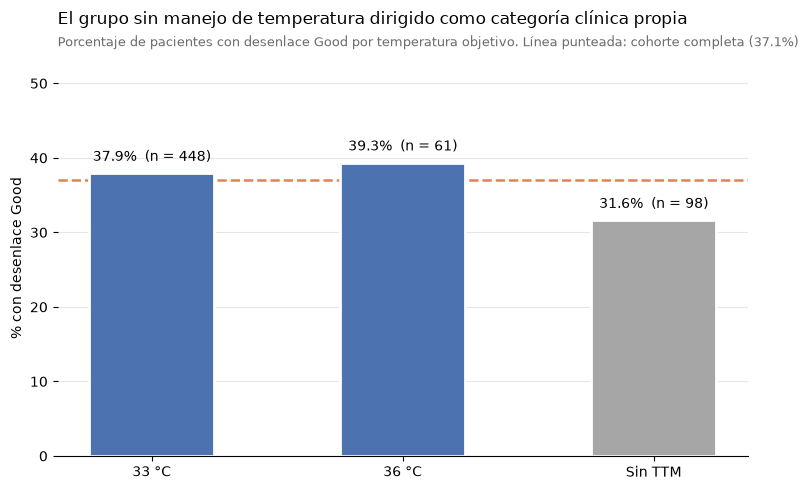

TTM_grupo
33 °C      37.9
36 °C      39.3
Sin TTM    31.6


In [20]:
clinical_df['TTM_grupo'] = clinical_df['TTM'].apply(
    lambda x: 'Sin TTM' if pd.isna(x) else f'{x:.0f} °C'
)

orden = ['33 °C', '36 °C', 'Sin TTM']
tabla = pd.crosstab(clinical_df['TTM_grupo'], clinical_df['Outcome']).reindex(orden)
pct_good = (tabla['Good'] / tabla.sum(axis=1) * 100)
conteos = tabla.sum(axis=1)

baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.bar(orden, pct_good.values, width=0.5,
                color=['#4C72B0', '#4C72B0', '#A6A6A6'],
                edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.2,
            f'{pct:.1f}%  (n = {int(n)})', ha='center', va='bottom', fontsize=10)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)

ax.set_title('El grupo sin manejo de temperatura dirigido como categoría clínica propia',
             fontsize=12.5, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje de pacientes con desenlace Good por temperatura objetivo. '
        f'Línea punteada: cohorte completa ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, max(pct_good.max(), baseline) * 1.35)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(pct_good.round(1).to_string())

Comportamiento del grupo sin TTM frente al desenlace

| Categoría | % con desenlace Good | n |
|---|---|---|
| 33 °C | 37.9% | 448 |
| 36 °C | 39.3% | 61 |
| Sin TTM | 31.6% | 98 |
| **Cohorte completa** | **37.1%** | **607** |

Dos observaciones se desprenden de esta comparación.

La primera es que ambas temperaturas objetivo producen resultados prácticamente equivalentes, con una diferencia de apenas 1.4 puntos porcentuales entre 33 y 36 grados. Este hallazgo es consistente con la evidencia clínica disponible, que no ha logrado establecer una ventaja de la hipotermia profunda frente al control de temperatura menos agresivo.



**Criterio de decisión y tratamiento aplicado en `TTM`**

Se decidió recodificar `TTM` como variable categórica de tres niveles: `33 °C`, `36 °C` y `Sin TTM`.

Conviene precisar antes qué significa el valor nulo en esta variable, porque de ello depende el tratamiento. La comparación por centro que se presenta en el apartado de datos inconsistentes muestra que las ausencias no se distribuyen al azar: el 92.8 % de los pacientes de un mismo hospital carece del dato, frente a menos del 5 % en otros dos centros. Una concentración así no responde a decisiones clínicas tomadas paciente por paciente, sino a la convención de registro de esa institución. El nulo agrupa por tanto dos situaciones que los datos no permiten separar: pacientes a los que no se aplicó el procedimiento y pacientes a los que sí se aplicó pero cuyo centro no consigna la variable.

Esa ambigüedad es justamente lo que descarta las tres alternativas habituales.

Imputar un valor sería el error más grave. Asignar 33 o 36 grados a esos 98 pacientes equivaldría a afirmar que recibieron un tratamiento del que no consta registro, lo que no es una aproximación estadística imprecisa sino una afirmación clínicamente infundada. Y como la ausencia depende del centro, la imputación introduciría además una señal institucional disfrazada de dato clínico.

Eliminar los registros tampoco procede, y por la misma razón. No reduciría la muestra al azar sino que descartaría casi por completo a un hospital, junto con su perfil de pacientes y su tasa de desenlace.

Conservar el valor como `NaN`, que fue la solución adoptada para `ROSC`, resultaría aquí insuficiente. El nulo es invisible en las tablas de frecuencias y en la mayoría de los procedimientos, de modo que el patrón que acaba de describirse quedaría oculto en lugar de documentado.

La recodificación como categoría explícita es por lo tanto la representación más fiel a lo que el dato realmente contiene: no una temperatura desconocida, sino la constancia de que no hay registro de manejo térmico, con las dos lecturas posibles declaradas. Hace visible el patrón en lugar de esconderlo, y permite que los 607 pacientes queden disponibles para cualquier análisis posterior, frente a los 509 utilizables en el formato original.

La conversión no implica además ninguna pérdida de información, dado que la variable solo contiene dos valores distintos y su formato numérico nunca aportó capacidad analítica real. Corrige de paso una inconsistencia entre el tipo de dato y la naturaleza de la variable que venía arrastrándose desde la adquisición.

In [21]:
# Recodificación de TTM como variable categórica de tres niveles.
# El nulo no es una temperatura desconocida sino la constancia de que no hay
# registro de manejo térmico. Su concentración por centro impide imputarlo.
clinical_df['TTM_cat'] = clinical_df['TTM'].apply(
    lambda x: 'Sin TTM' if pd.isna(x) else f'{x:.0f} °C'
)

orden = ['33 °C', '36 °C', 'Sin TTM']

print("Distribución final de TTM_cat:")
dist = clinical_df['TTM_cat'].value_counts().reindex(orden)
for cat, n in dist.items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

print(f"\nPacientes utilizables: {clinical_df['TTM_cat'].notna().sum()} de {len(clinical_df)}")
print(f"Valores nulos en TTM_cat: {clinical_df['TTM_cat'].isnull().sum()}")

assert clinical_df['TTM_cat'].isnull().sum() == 0, "TTM_cat contiene nulos"
print("\nVerificación superada: TTM_cat cubre la totalidad de la cohorte sin valores nulos.")

Distribución final de TTM_cat:
  33 °C: 448 (73.8%)
  36 °C: 61 (10.0%)
  Sin TTM: 98 (16.1%)

Pacientes utilizables: 607 de 607
Valores nulos en TTM_cat: 0

Verificación superada: TTM_cat cubre la totalidad de la cohorte sin valores nulos.


**Tratamiento de datos faltantes para las variables categoricas**

In [22]:
categorical_cols = ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]

print("Valores faltantes en las variables categóricas:\n")

total = 0
for col in categorical_cols:
    nan_texto = (clinical_df[col].astype(str).str.strip().str.lower() == 'nan').sum()
    pct = nan_texto / len(clinical_df) * 100
    print(f"{col}: {nan_texto} faltantes ({pct:.1f}%)")
    total += nan_texto

print(f"\nTotal de faltantes en variables categóricas: {total}")

Valores faltantes en las variables categóricas:

Sex: 3 faltantes (0.5%)
Hospital: 0 faltantes (0.0%)
OHCA: 41 faltantes (6.8%)
Shockable Rhythm: 32 faltantes (5.3%)
Outcome: 0 faltantes (0.0%)
CPC: 0 faltantes (0.0%)

Total de faltantes en variables categóricas: 76


**Valores faltantes en las variables categóricas**

El conteo confirma que solo tres de las seis variables categóricas presentan valores faltantes, sumando 76 registros en total:

| Variable | Faltantes | Porcentaje |
|---|---|---|
| `Sex` | 3 | 0.5% |
| `OHCA` | 41 | 6.8% |
| `Shockable Rhythm` | 32 | 5.3% |
| `Hospital` | 0 | 0.0% |
| `Outcome` | 0 | 0.0% |
| `CPC` | 0 | 0.0% |

Tres hallazgos relevantes se desprenden de este resultado.

Primero, la variable objetivo (`Outcome`) y su variable asociada (`CPC`) están completas para los 607 pacientes. Esto es especialmente importante, porque un faltante en la variable objetivo obligaría a descartar esos registros por completo al no poder usarse ni para caracterización ni para modelado posterior. Al estar completas, se conserva la totalidad de la cohorte para el análisis del desenlace.

Segundo, `Hospital` también está completa, lo que permite usarla con confianza como variable de estratificación o control en análisis posteriores, sin riesgo de perder pacientes al agrupar por institución.

Tercero, los faltantes se concentran en variables clínicas del evento (`OHCA` y `Shockable Rhythm`), con porcentajes moderados pero no despreciables (6.8% y 5.3%). Estas dos describen las circunstancias del paro cardíaco, información que suele registrarse en el contexto prehospitalario y que puede no estar disponible cuando el paro no fue presenciado o cuando el paciente fue remitido desde otra institución. Su ausencia no es un simple vacío administrativo, sino que puede reflejar situaciones clínicas particulares, por lo que requieren una decisión de tratamiento cuidadosa y no una imputación automática.

**Variable `Sex`**

`Sex` es una variable con dos categorías válidas (`Male` y `Female`) que registra el género del paciente. En la Fase 2 se identificó que presenta valores faltantes, los cuales estaban ocultos como el texto literal `"nan"` y no como valores nulos reales de pandas.

A continuación se cuantifica la magnitud del faltante y se evalúa su impacto sobre la representatividad de la variable antes de decidir el tratamiento.

In [23]:
# Normalizar el "nan" de texto a un valor nulo real reconocible por pandas
clinical_df['Sex'] = clinical_df['Sex'].replace('nan', pd.NA)

n_total = len(clinical_df)
n_falt = clinical_df['Sex'].isnull().sum()

print(f"Total de pacientes: {n_total}")
print(f"Valores faltantes en Sex: {n_falt} ({n_falt/n_total*100:.2f}%)\n")
print("Distribución de las categorías conocidas:")
print(clinical_df['Sex'].value_counts(dropna=False).to_string())

Total de pacientes: 607
Valores faltantes en Sex: 3 (0.49%)

Distribución de las categorías conocidas:
Sex
Male      417
Female    187
NaN         3


In [24]:
faltantes = clinical_df[clinical_df['Sex'].isnull()]

print("Perfil de los pacientes sin dato de Sex:")
print(faltantes[['Patient', 'Hospital', 'Age', 'OHCA',
                 'Shockable Rhythm', 'ROSC', 'Outcome', 'CPC']].to_string(index=False))

print("\nHospital de procedencia de los faltantes:")
print(faltantes['Hospital'].value_counts().to_string())

Perfil de los pacientes sin dato de Sex:
Patient Hospital  Age  OHCA Shockable Rhythm  ROSC Outcome CPC
   0405        B 26.0 False            False   2.0    Poor   5
   0592        F 63.0  True            False   NaN    Good   1
   0788        D 67.0   nan            False   NaN    Poor   5

Hospital de procedencia de los faltantes:
Hospital
B    1
F    1
D    1


**Identificación y análisis del faltante**

La variable `Sex` presenta 3 valores faltantes sobre 607 pacientes, equivalentes al 0.49% del total. Las categorías conocidas se distribuyen en 417 hombres y 187 mujeres.

Respecto a la distribución de los faltantes frente a variables clave, los 3 pacientes afectados cuentan con información completa en el resto de variables clínicas relevantes, incluida la variable objetivo `Outcome`. Cabe precisar que, con únicamente 3 casos, cualquier comparación estadística de este subgrupo frente al resto de la cohorte carece de poder para ser concluyente, por lo que la decisión de tratamiento no se fundamenta en el perfil de estos pacientes, sino en un análisis de sensibilidad sobre la variable completa.

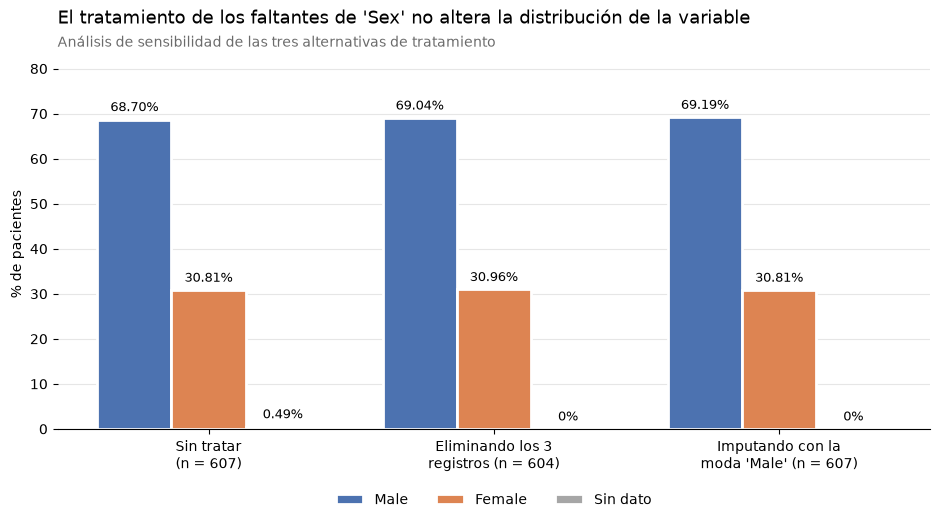

In [25]:
n_male = (clinical_df['Sex'] == 'Male').sum()
n_female = (clinical_df['Sex'] == 'Female').sum()
n_falt = clinical_df['Sex'].isnull().sum()
n_conocidos = n_male + n_female

escenarios = [
    f"Sin tratar\n(n = {n_total})",
    f"Eliminando los {n_falt}\nregistros (n = {n_conocidos})",
    f"Imputando con la\nmoda 'Male' (n = {n_total})",
]
male     = [n_male/n_total*100, n_male/n_conocidos*100, (n_male + n_falt)/n_total*100]
female   = [n_female/n_total*100, n_female/n_conocidos*100, n_female/n_total*100]
sin_dato = [n_falt/n_total*100, 0.0, 0.0]

x = np.arange(len(escenarios))
w = 0.26

fig, ax = plt.subplots(figsize=(9.5, 5.4))
b1 = ax.bar(x - w, male, w, label='Male', color='#4C72B0', edgecolor='white', linewidth=2)
b2 = ax.bar(x, female, w, label='Female', color='#DD8452', edgecolor='white', linewidth=2)
b3 = ax.bar(x + w, sin_dato, w, label='Sin dato', color='#A6A6A6', edgecolor='white', linewidth=2)

for barras in (b1, b2, b3):
    for barra in barras:
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, alto + 1.2,
                f'{alto:.2f}%' if alto > 0 else '0%',
                ha='center', va='bottom', fontsize=9)

ax.set_title("El tratamiento de los faltantes de 'Sex' no altera la distribución de la variable",
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.035, 'Análisis de sensibilidad de las tres alternativas de tratamiento',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% de pacientes')
ax.set_xticks(x)
ax.set_xticklabels(escenarios)
ax.set_ylim(0, 82)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3)

plt.tight_layout()
plt.show()

**Criterio de decisión y tratamiento aplicado**

Para decidir entre eliminar los registros o imputarlos, se realizó un análisis de sensibilidad comparando la distribución resultante de `Sex` bajo los tres escenarios posibles.

El resultado muestra que la proporción de hombres se mantiene entre 68.70% y 69.19%, y la de mujeres entre 30.81% y 30.96%, independientemente del tratamiento aplicado. La diferencia máxima entre eliminar los registros e imputarlos con la moda es de 0.15 puntos porcentuales, una variación sin ninguna relevancia práctica para el análisis.

Dado que ambas alternativas producen esencialmente el mismo resultado sobre la variable, el criterio de decisión pasa a ser cuál de las dos preserva mayor cantidad de información. Por esta razón se optó por **imputar los 3 valores con la moda (`Male`)** en lugar de eliminar los registros, con base en tres consideraciones:

1. Los 3 pacientes afectados cuentan con datos completos en variables clínicamente más determinantes para el desenlace, como `Shockable Rhythm`, `ROSC` y `Outcome`. Eliminarlos implicaría descartar esa información a cambio de un beneficio nulo.
2. El conjunto de datos es relativamente pequeño (607 pacientes) y la clase minoritaria de la variable objetivo cuenta con solo 225 casos `Good`, por lo que la pérdida de registros debe evitarse siempre que sea posible.
3. En la Fase 2 se estableció que `Sex` presenta una asociación muy débil con el desenlace neurológico. Esto se evidenció en el gráfico de **barras de proporción de `Outcome` según `Sex`**, donde la diferencia en la proporción de casos `Good` entre hombres y mujeres fue de apenas 6 puntos porcentuales (38.6% frente a 32.8%), y se confirmó numéricamente en la **matriz de correlación extendida**, donde `Sex_num` presentó una correlación cercana a cero con `Outcome_num`, muy por debajo de la de otras variables como `Shockable Rhythm` (-0.37). Dado que el sexo no es un factor determinante del desenlace en este conjunto de datos, una eventual imputación incorrecta en 3 pacientes no introduce sesgo apreciable en los análisis de asociación posteriores.

In [26]:
moda_sex = clinical_df['Sex'].mode()[0]
clinical_df['Sex'] = clinical_df['Sex'].fillna(moda_sex)

print(f"Imputación aplicada con la moda: '{moda_sex}'\n")
print("Distribución final de Sex:")
print(clinical_df['Sex'].value_counts().to_string())
print(f"\nValores faltantes restantes en Sex: {clinical_df['Sex'].isnull().sum()}")

assert clinical_df['Sex'].isnull().sum() == 0, "Aún quedan faltantes en Sex"
print("Verificación superada: la variable Sex no contiene valores faltantes.")


Imputación aplicada con la moda: 'Male'

Distribución final de Sex:
Sex
Male      420
Female    187

Valores faltantes restantes en Sex: 0
Verificación superada: la variable Sex no contiene valores faltantes.


**Variable `OHCA`**

`OHCA` (Out-of-Hospital Cardiac Arrest) es una variable categórica binaria que indica si el paro cardíaco ocurrió fuera del hospital (`True`) o dentro de este (`False`). Es la variable categórica con mayor proporción de valores faltantes del conjunto de datos.

A diferencia de `Sex`, donde el faltante era marginal, aquí el grupo sin dato es lo suficientemente grande como para evaluar si su ausencia responde a un patrón sistemático. Por ello el criterio de decisión no será un análisis de sensibilidad, sino determinar si el faltante constituye en sí mismo información relevante frente a la variable objetivo.

In [27]:
clinical_df['OHCA'] = clinical_df['OHCA'].replace('nan', pd.NA)

n_falt = clinical_df['OHCA'].isnull().sum()
print(f"Valores faltantes en OHCA: {n_falt} ({n_falt/n_total*100:.1f}%)\n")
print("Distribución de las categorías:")
print(clinical_df['OHCA'].value_counts(dropna=False).to_string())

print("\nDistribución por hospital de los pacientes SIN dato de OHCA:")
falt_hosp = clinical_df.loc[clinical_df['OHCA'].isnull(), 'Hospital'].value_counts()
total_hosp = clinical_df['Hospital'].value_counts()
comparacion = pd.DataFrame({
    'Faltantes': falt_hosp,
    'Total pacientes': total_hosp,
}).fillna(0).astype(int)
comparacion['% del hospital'] = (comparacion['Faltantes'] / comparacion['Total pacientes'] * 100).round(1)
print(comparacion.to_string())

Valores faltantes en OHCA: 41 (6.8%)

Distribución de las categorías:
OHCA
True     442
False    124
NaN       41

Distribución por hospital de los pacientes SIN dato de OHCA:
          Faltantes  Total pacientes  % del hospital
Hospital                                            
A                26              261            10.0
B                 0              120             0.0
D                11               83            13.3
E                 3               74             4.1
F                 1               69             1.4


**Análisis de la distribución de los faltantes**

Al examinar el origen institucional de los 41 registros sin dato, se observa que los faltantes no se distribuyen de manera uniforme entre los hospitales del consorcio:

| Hospital | Faltantes | Total pacientes | % del hospital |
|---|---|---|---|
| A | 26 | 261 | 10.0% |
| B | 0 | 120 | 0.0% |
| D | 11 | 83 | 13.3% |
| E | 3 | 74 | 4.1% |
| F | 1 | 69 | 1.4% |

La proporción de faltantes varía entre 0.0% y 13.3% según la institución, y los hospitales A y D concentran 37 de los 41 casos (90%). El contraste más notorio es el del Hospital B, que no presenta ningún valor faltante en 120 pacientes, frente al Hospital D, con 13.3% de sus registros incompletos.

Este patrón indica que la ausencia del dato no responde a una característica clínica de los pacientes, sino a diferencias en las prácticas de registro y documentación entre instituciones. Es decir, se trata de un faltante asociado a la variable `Hospital` y no aleatorio en sentido estricto.

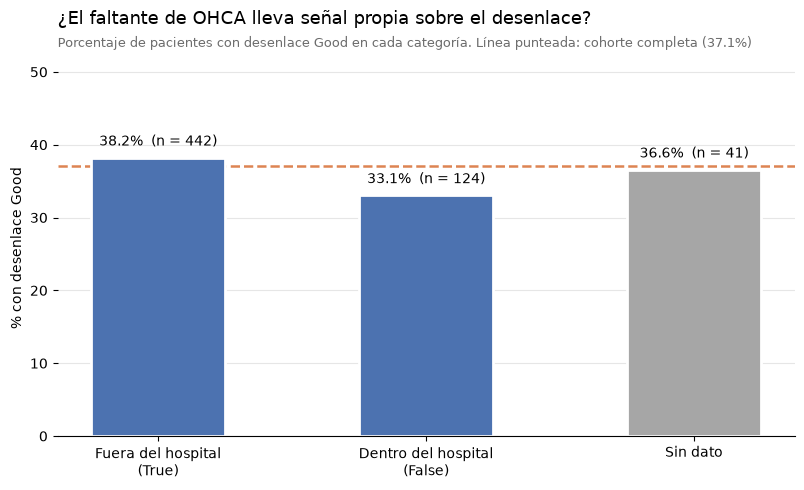

OHCA
True        38.2
False       33.1
Sin dato    36.6


In [28]:
# Los nulos reales se convierten a texto ANTES de agrupar. En versiones recientes de
# pandas, .astype(str) no transforma pd.NA en '<NA>' sino que lo conserva como nulo,
# y pd.crosstab descarta esas filas, haciendo desaparecer la categoría "Sin dato".
grupos = (clinical_df['OHCA']
          .astype(object)
          .fillna('Sin dato')
          .astype(str)
          .replace({'nan': 'Sin dato', '<NA>': 'Sin dato',
                    'None': 'Sin dato', 'Desconocido': 'Sin dato'}))

tabla = pd.crosstab(grupos, clinical_df['Outcome'])
pct_good = (tabla['Good'] / tabla.sum(axis=1) * 100)
conteos = tabla.sum(axis=1)

orden = ['True', 'False', 'Sin dato']
pct_good = pct_good.reindex(orden)
conteos = conteos.reindex(orden)

baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.bar(['Fuera del hospital\n(True)', 'Dentro del hospital\n(False)', 'Sin dato'],
                pct_good.values, width=0.5,
                color=['#4C72B0', '#4C72B0', '#A6A6A6'], edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.2,
            f'{pct:.1f}%  (n = {int(n)})', ha='center', va='bottom', fontsize=10)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)

ax.set_title('¿El faltante de OHCA lleva señal propia sobre el desenlace?',
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje de pacientes con desenlace Good en cada categoría. '
        f'Línea punteada: cohorte completa ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, max(pct_good.max(), baseline) * 1.35)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(pct_good.round(1).to_string())


**Evaluación de si el faltante lleva señal propia**

Para determinar si la ausencia del dato constituye información relevante, se comparó la proporción de pacientes con desenlace `Good` en cada categoría de `OHCA`, incluyendo el grupo sin dato.

| Categoría | % con desenlace Good | n |
|---|---|---|
| Fuera del hospital (`True`) | 38.2% | 442 |
| Dentro del hospital (`False`) | 33.1% | 124 |
| Sin dato | 36.6% | 41 |
| **Cohorte completa** | **37.1%** | **607** |

El grupo sin dato presenta un 36.6% de desenlaces favorables, prácticamente idéntico al 37.1% de la cohorte completa y ubicado entre las dos categorías conocidas. Esto indica que los pacientes sin registro de `OHCA` no constituyen un subgrupo con un pronóstico diferenciado, sino que se comportan como el promedio del conjunto de datos. El hallazgo sugiere que la ausencia del dato se debe a diferencias en las prácticas de documentación institucional y no a características clínicas de los pacientes.

**Criterio de decisión y tratamiento aplicado**

Con ambas evidencias se optó por **conservar los valores faltantes como una categoría explícita `"Desconocido"`**, en lugar de imputarlos o eliminar los registros.

La decisión se fundamenta en una asimetría de costos entre las alternativas. Conservar la categoría no tiene costo analítico, dado que el grupo sin dato se comporta como el promedio de la cohorte y por lo tanto no distorsiona las comparaciones de desenlace entre categorías. Imputar con la moda, en cambio, sí tiene un costo concreto: desplazaría la distribución de la variable de 72.8% a 79.6% de casos `True`, y atribuiría a 41 pacientes una característica clínica desconocida, cuando la única causa documentada de la ausencia es la práctica de registro de sus hospitales de origen. Eliminar los registros tampoco es viable, porque los faltantes se concentran en los hospitales A y D, lo que sub-representaría sistemáticamente a esas instituciones en todos los análisis posteriores.

Se evaluó adicionalmente una imputación por moda dentro de cada hospital, más refinada que la moda global, pero se descartó porque el 90% de los faltantes proviene de A y D, donde la moda también es `True`, con lo cual el resultado sería equivalente al de la imputación global sin resolver el problema de fondo.

Finalmente, conservar una tercera categoría no representa ninguna limitación para las fases posteriores, ya que la codificación one-hot la maneja de forma nativa en cualquier modelo de clasificación.

In [29]:
clinical_df['OHCA'] = clinical_df['OHCA'].astype(object).fillna('Desconocido')

print("Distribución final de OHCA:")
dist = clinical_df['OHCA'].value_counts()
for cat, n in dist.items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

print(f"\nValores faltantes restantes en OHCA: {clinical_df['OHCA'].isnull().sum()}")
assert clinical_df['OHCA'].isnull().sum() == 0, "Aún quedan faltantes en OHCA"
print("Verificación superada: la variable OHCA no contiene valores faltantes.")

Distribución final de OHCA:
  True: 442 (72.8%)
  False: 124 (20.4%)
  Desconocido: 41 (6.8%)

Valores faltantes restantes en OHCA: 0
Verificación superada: la variable OHCA no contiene valores faltantes.


**Variable `Shockable Rhythm`**

`Shockable Rhythm` es una variable categórica binaria que indica si el ritmo cardíaco inicial del paciente era desfibrilable (`True`), por ejemplo fibrilación ventricular, o no desfibrilable (`False`). Presenta 32 valores faltantes, equivalentes al 5.3% del conjunto.

Esta variable requiere el criterio de tratamiento más cuidadoso, por dos razones establecidas en la Fase 2. Primero, es la variable con la asociación más fuerte con el desenlace neurológico de todo el conjunto de datos: presentó la correlación de mayor magnitud con `Outcome` (-0.37) y una diferencia de 38 puntos porcentuales en la proporción de casos `Good` entre sus dos categorías (55% con ritmo desfibrilable frente a 17% sin él). Segundo, sus dos categorías están prácticamente equilibradas (297 casos `True` frente a 278 `False`), a diferencia de `OHCA`, donde existía una mayoría clara.

Cualquier valor asignado de forma incorrecta en esta variable tiene, por lo tanto, un impacto mucho mayor sobre los análisis posteriores que en las variables anteriores.

In [30]:
clinical_df['Shockable Rhythm'] = clinical_df['Shockable Rhythm'].replace('nan', pd.NA)

n_falt = clinical_df['Shockable Rhythm'].isnull().sum()
print(f"Valores faltantes en Shockable Rhythm: {n_falt} ({n_falt/n_total*100:.1f}%)\n")
print("Distribución de las categorías:")
print(clinical_df['Shockable Rhythm'].value_counts(dropna=False).to_string())

conocidos = clinical_df['Shockable Rhythm'].dropna()
print("\nDistribución entre los casos conocidos (%):")
print((conocidos.value_counts(normalize=True) * 100).round(1).to_string())

print("\nDistribución por hospital de los pacientes SIN dato:")
falt_hosp = clinical_df.loc[clinical_df['Shockable Rhythm'].isnull(), 'Hospital'].value_counts()
total_hosp = clinical_df['Hospital'].value_counts()
comparacion = pd.DataFrame({
    'Faltantes': falt_hosp,
    'Total pacientes': total_hosp,
}).fillna(0).astype(int)
comparacion['% del hospital'] = (comparacion['Faltantes'] / comparacion['Total pacientes'] * 100).round(1)
print(comparacion.to_string())

Valores faltantes en Shockable Rhythm: 32 (5.3%)

Distribución de las categorías:
Shockable Rhythm
True     297
False    278
NaN       32

Distribución entre los casos conocidos (%):
Shockable Rhythm
True     51.7
False    48.3

Distribución por hospital de los pacientes SIN dato:
          Faltantes  Total pacientes  % del hospital
Hospital                                            
A                32              261            12.3
B                 0              120             0.0
D                 0               83             0.0
E                 0               74             0.0
F                 0               69             0.0


**Análisis de la distribución de los faltantes**

El examen del origen institucional de los 32 registros sin dato arroja un resultado inequívoco:

| Hospital | Faltantes | Total pacientes | % del hospital |
|---|---|---|---|
| A | 32 | 261 | 12.3% |
| B | 0 | 120 | 0.0% |
| D | 0 | 83 | 0.0% |
| E | 0 | 74 | 0.0% |
| F | 0 | 69 | 0.0% |

La totalidad de los valores faltantes proviene del Hospital A, mientras que los cuatro hospitales restantes no presentan ni un solo registro incompleto en 346 pacientes. Se trata por lo tanto de una carencia de documentación exclusiva de una institución, sin relación con las características clínicas de los pacientes.

Este hallazgo es más categórico que el observado en `OHCA`, donde los faltantes se repartían en distinta proporción entre cuatro hospitales. Aquí la ausencia del dato depende por completo del centro de origen, lo que descarta interpretarla como una señal clínica.

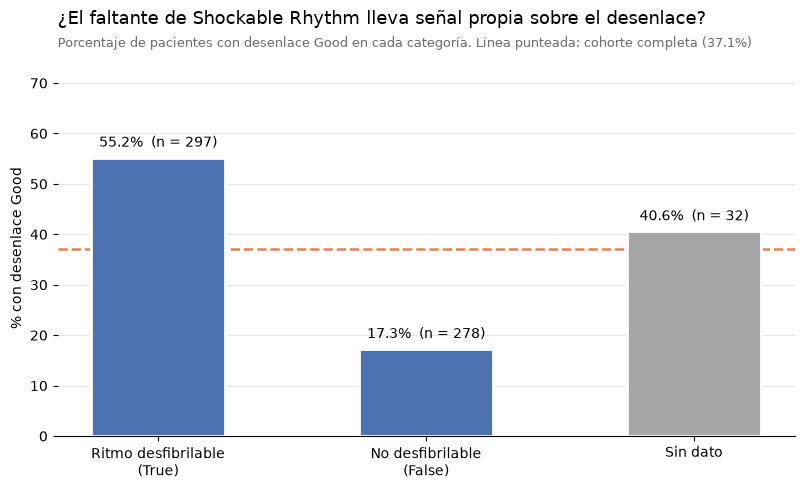

Shockable Rhythm
True        55.2
False       17.3
Sin dato    40.6


In [31]:
grupos = (clinical_df['Shockable Rhythm']
          .astype(object)
          .fillna('Sin dato')
          .astype(str)
          .replace({'nan': 'Sin dato', '<NA>': 'Sin dato',
                    'None': 'Sin dato', 'Desconocido': 'Sin dato'}))

tabla = pd.crosstab(grupos, clinical_df['Outcome'])
pct_good = (tabla['Good'] / tabla.sum(axis=1) * 100)
conteos = tabla.sum(axis=1)

orden = ['True', 'False', 'Sin dato']
pct_good = pct_good.reindex(orden)
conteos = conteos.reindex(orden)

baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.bar(['Ritmo desfibrilable\n(True)', 'No desfibrilable\n(False)', 'Sin dato'],
                pct_good.values, width=0.5,
                color=['#4C72B0', '#4C72B0', '#A6A6A6'], edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.5,
            f'{pct:.1f}%  (n = {int(n)})', ha='center', va='bottom', fontsize=10)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)

ax.set_title('¿El faltante de Shockable Rhythm lleva señal propia sobre el desenlace?',
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje de pacientes con desenlace Good en cada categoría. '
        f'Línea punteada: cohorte completa ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, max(pct_good.max(), baseline) * 1.35)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(pct_good.round(1).to_string())

In [32]:
# Costo cuantitativo de imputar con la moda.
# La celda es autocontenida: recalcula los grupos en vez de depender de celdas previas.
grupos_sr = (clinical_df['Shockable Rhythm']
             .astype(object)
             .fillna('Sin dato')
             .astype(str)
             .replace({'nan': 'Sin dato', '<NA>': 'Sin dato',
                       'None': 'Sin dato', 'Desconocido': 'Sin dato'}))

tabla_sr = pd.crosstab(grupos_sr, clinical_df['Outcome']).reindex(['True', 'False', 'Sin dato'])
pct_sr = (tabla_sr['Good'] / tabla_sr.sum(axis=1) * 100)

conocidos = grupos_sr[grupos_sr.isin(['True', 'False'])]
n_falt_sr = int((grupos_sr == 'Sin dato').sum())

moda = conocidos.mode()[0]
pct_moda = (conocidos == moda).mean() * 100
error_esperado = round(n_falt_sr * (1 - pct_moda / 100))

print(f"Moda de la variable: '{moda}', presente en {pct_moda:.1f}% de los casos conocidos")
print(f"Al imputar los {n_falt_sr} faltantes con la moda se esperaría clasificar")
print(f"incorrectamente alrededor de {error_esperado} pacientes ({100 - pct_moda:.1f}% de ellos).\n")

# Composición implícita del grupo sin dato, estimada a partir de su tasa de desenlace favorable
prop_true_estimada = (pct_sr['Sin dato'] - pct_sr['False']) / (pct_sr['True'] - pct_sr['False'])
print("Composición estimada del grupo sin dato a partir de su tasa de desenlace favorable:")
print(f"  aproximadamente {prop_true_estimada*100:.0f}% True  ({round(n_falt_sr*prop_true_estimada)} pacientes)")
print(f"  aproximadamente {(1-prop_true_estimada)*100:.0f}% False ({round(n_falt_sr*(1-prop_true_estimada))} pacientes)")


Moda de la variable: 'True', presente en 51.7% de los casos conocidos
Al imputar los 32 faltantes con la moda se esperaría clasificar
incorrectamente alrededor de 15 pacientes (48.3% de ellos).

Composición estimada del grupo sin dato a partir de su tasa de desenlace favorable:
  aproximadamente 62% True  (20 pacientes)
  aproximadamente 38% False (12 pacientes)


**Evaluación de si el faltante lleva señal propia**

| Categoría | % con desenlace Good | n |
|---|---|---|
| Ritmo desfibrilable (`True`) | 55.2% | 297 |
| No desfibrilable (`False`) | 17.3% | 278 |
| Sin dato | 40.6% | 32 |
| **Cohorte completa** | **37.1%** | **607** |

La diferencia entre las dos categorías conocidas es de 37.9 puntos porcentuales, la mayor observada entre todas las variables del conjunto, lo que confirma a `Shockable Rhythm` como el factor pronóstico más determinante disponible.

El grupo sin dato presenta un 40.6% de desenlaces favorables, un valor que no se aproxima a ninguna de las dos categorías conocidas y que se ubica cerca del promedio general de la cohorte. Este comportamiento intermedio es característico de un grupo mixto y no de uno que pertenezca mayoritariamente a una sola categoría. Asumiendo que su tasa de desenlace favorable corresponde a una combinación ponderada de ambas categorías, la proporción implícita de casos `True` en ese grupo sería cercana al 61%, es decir, alrededor de 20 pacientes `True` y 12 `False`.

**Criterio de decisión y tratamiento aplicado**

Se optó por **conservar los valores faltantes como una categoría explícita `"Desconocido"`**, en lugar de imputarlos o eliminar los registros. Esta es la variable donde dicha decisión cuenta con el fundamento más sólido de las tres, por cuatro razones.

Primero, la moda no constituye una mayoría significativa. Entre los casos conocidos la distribución es de 51.7% `True` frente a 48.3% `False`, prácticamente equilibrada. La imputación por moda es un procedimiento defendible cuando existe una categoría claramente dominante, pero con una mayoría del 51.7% equivale a asignar valores casi de forma aleatoria.

Segundo, el costo del error es el más alto del conjunto de datos. Al estimarse que cerca de 12 de los 32 pacientes pertenecen realmente a la categoría `False`, imputarlos todos como `True` los desplazaría desde un grupo con 17.3% de desenlaces favorables hacia uno con 55.2%, introduciendo ruido precisamente en la variable con mayor capacidad discriminante sobre el desenlace neurológico.

Tercero, el perfil intermedio del grupo sin dato indica que se trata de una mezcla de ambas categorías, por lo que ningún valor único sería representativo del conjunto de pacientes afectados.

Cuarto, la totalidad de los faltantes proviene del Hospital A. Eliminar esos registros sub-representaría a la institución que aporta el 43% de la cohorte, mientras que imputarlos ocultaría un hallazgo relevante sobre la calidad del registro en ese centro. Conservar la categoría explícita mantiene visible esa limitación de los datos en lugar de disimularla.

Al igual que en `OHCA`, la tercera categoría no representa ninguna limitación técnica para las fases posteriores, dado que la codificación one-hot la maneja de forma nativa en cualquier modelo de clasificación.

In [33]:
clinical_df['Shockable Rhythm'] = clinical_df['Shockable Rhythm'].astype(object).fillna('Desconocido')

print("Distribución final de Shockable Rhythm:")
dist = clinical_df['Shockable Rhythm'].value_counts()
for cat, n in dist.items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

print(f"\nValores faltantes restantes: {clinical_df['Shockable Rhythm'].isnull().sum()}")
assert clinical_df['Shockable Rhythm'].isnull().sum() == 0, "Aún quedan faltantes"
print("Verificación superada: la variable Shockable Rhythm no contiene valores faltantes.")

Distribución final de Shockable Rhythm:
  True: 297 (48.9%)
  False: 278 (45.8%)
  Desconocido: 32 (5.3%)

Valores faltantes restantes: 0
Verificación superada: la variable Shockable Rhythm no contiene valores faltantes.


**Hallazgo transversal sobre la calidad del registro**

Al comparar el origen de los faltantes de las tres variables categóricas se identifica un patrón que trasciende cada caso individual. Los 32 faltantes de `Shockable Rhythm` provienen en su totalidad del Hospital A, y 26 de los 41 faltantes de `OHCA` provienen de esa misma institución. En conjunto, el Hospital A concentra 58 de los 76 valores faltantes del conjunto de variables categóricas, es decir el 76% del total.

Esto indica que no se trata de incidencias aisladas e independientes en cada variable, sino de una deficiencia sistemática en las prácticas de documentación de las circunstancias del paro cardíaco en ese centro. Dado que el Hospital A aporta el 43% de la cohorte, esta limitación debe tenerse presente al interpretar cualquier análisis que involucre estas dos variables, y constituye en sí misma un hallazgo relevante sobre la calidad del conjunto de datos.

**Verificación final de la sección**

Una vez aplicados los tratamientos a las seis variables con valores ausentes, se verifica el estado final del conjunto de datos. El resultado esperado es que ninguna variable conserve valores nulos, con la única excepción de `ROSC`, cuyos 304 registros se mantienen deliberadamente sin imputar según el criterio justificado en su apartado correspondiente.


In [34]:
# Se elimina la columna auxiliar creada únicamente para construir el gráfico de TTM
clinical_df = clinical_df.drop(columns=['TTM_grupo'], errors='ignore')

print("Estado final de los valores faltantes tras la sección 1.1:\n")
print(clinical_df.isnull().sum().to_string())

# ROSC y TTM conservan sus nulos de forma deliberada, cada una por su propio criterio:
#   ROSC: imputar la mitad de la variable distorsionaría su distribución. Su versión
#         utilizable para toda la cohorte es ROSC_cat.
#   TTM:  el nulo indica ausencia de registro de manejo térmico, con un patrón
#         que depende del centro. Su versión recodificada es TTM_cat.
deliberados = ['ROSC', 'TTM']
falt_tratadas = clinical_df.drop(columns=deliberados).isnull().sum().sum()

print(f"\nValores faltantes en las variables tratadas: {falt_tratadas}")
print("\nNulos conservados de forma deliberada:")
print(f"  ROSC: {clinical_df['ROSC'].isnull().sum():>3}  (versión completa disponible en ROSC_cat)")
print(f"  TTM:  {clinical_df['TTM'].isnull().sum():>3}  (versión completa disponible en TTM_cat)")

assert falt_tratadas == 0, "Quedan valores faltantes sin tratar"
assert clinical_df['ROSC_cat'].isnull().sum() == 0, "ROSC_cat contiene nulos"
assert clinical_df['TTM_cat'].isnull().sum() == 0, "TTM_cat contiene nulos"

print("\nVerificación superada: todas las variables quedaron tratadas. Los nulos restantes")
print("en ROSC y TTM son intencionales y cuentan con su equivalente completo en")
print("ROSC_cat y TTM_cat, que cubren los 607 pacientes.")


Estado final de los valores faltantes tras la sección 1.1:

Patient               0
Hospital              0
Age                   0
Sex                   0
ROSC                304
OHCA                  0
Shockable Rhythm      0
TTM                  98
Outcome               0
CPC                   0
ROSC_cat              0
TTM_cat               0

Valores faltantes en las variables tratadas: 0

Nulos conservados de forma deliberada:
  ROSC: 304  (versión completa disponible en ROSC_cat)
  TTM:   98  (versión completa disponible en TTM_cat)

Verificación superada: todas las variables quedaron tratadas. Los nulos restantes
en ROSC y TTM son intencionales y cuentan con su equivalente completo en
ROSC_cat y TTM_cat, que cubren los 607 pacientes.


**Respuesta a las preguntas de la sección**

**¿Cómo afectan estos valores a la integridad y representatividad de la información?**

El conjunto presenta 479 valores ausentes distribuidos en 6 de sus 10 variables, equivalentes al 7.9% de las celdas totales. Su efecto sobre la integridad es desigual según la variable: mientras en `Age` (1 caso) y `Sex` (3 casos) resulta despreciable, en `ROSC` alcanza el 50.1% del conjunto y limita seriamente cualquier análisis que dependa de esa variable.

El efecto sobre la representatividad es el aspecto más delicado, y no proviene de la cantidad de datos ausentes sino de su distribución. Los faltantes no se reparten de forma homogénea entre las instituciones: el Hospital A concentra 321 de los 479 valores ausentes, es decir el 67% del total, y en el caso de `ROSC` no registra la variable en ninguno de sus 261 pacientes. Dado que ese hospital aporta el 43% de la cohorte y presenta el mejor desenlace del conjunto, cualquier decisión de eliminar registros incompletos habría sub-representado de forma severa a la institución más grande y con mejores resultados, distorsionando la composición del estudio. Este riesgo fue determinante en las decisiones adoptadas: en ninguna variable se eliminaron registros, y los 607 pacientes se conservaron íntegros.

**¿Cómo se identificaron los valores faltantes en el conjunto de datos?**

La identificación requirió dos pasos, porque el método directo resultaba engañoso. Al ejecutar `clinical_df.isnull().sum()` sobre los datos recién adquiridos, el resultado indicaba cero valores faltantes en las diez columnas. Ese resultado era falso: los datos provienen de archivos de texto plano donde los campos sin valor quedaron registrados como el texto literal `"nan"`, que pandas interpreta como una cadena de caracteres válida y no como un dato ausente.

Detectada la discrepancia entre ese conteo y las categorías `"nan"` visibles en los gráficos de la Fase 2, se procedió a verificar que ese fuera efectivamente el único código de faltante empleado. Para las variables numéricas se comprobó, mediante `pd.to_numeric(errors="coerce")`, que `'nan'` era el único valor no convertible a número. Para las categóricas se revisaron todos sus valores únicos, descartando la presencia de otras variantes como `"NA"`, `"-"`, `"?"` o cadenas vacías.

Confirmado el diagnóstico, se normalizaron los valores a nulos reales de pandas: mediante `pd.to_numeric(errors="coerce")` en `Age`, `ROSC` y `TTM`, y mediante `.replace('nan', pd.NA)` en `Sex`, `OHCA` y `Shockable Rhythm`. Solo entonces el conteo reflejó la magnitud real del problema.

**¿Cuáles fueron los criterios para decidir si rellenar o eliminar los valores faltantes? ¿Qué método de relleno se utilizó y por qué?**

No se eliminó ningún registro en ninguna de las seis variables, por el riesgo de sub-representación institucional ya descrito y porque el conjunto es pequeño, con solo 225 casos en la clase minoritaria de la variable objetivo. El criterio de tratamiento se definió caso por caso, en función de la magnitud del faltante, de su origen y de las consecuencias de cada alternativa:

| Variable | Faltantes | Tratamiento | Criterio |
|---|---|---|---|
| `Age` | 1 (0.2%) | Imputación con la mediana (63 años) | El análisis de sensibilidad mostró que ninguna alternativa altera la distribución. Se eligió la mediana por la asimetría de la variable |
| `Sex` | 3 (0.5%) | Imputación con la moda (`Male`) | La distribución varía menos de 0.15 puntos porcentuales bajo cualquier tratamiento, por lo que se optó por preservar los registros |
| `OHCA` | 41 (6.8%) | Categoría explícita `"Desconocido"` | Imputar desplazaría la distribución de 72.8% a 79.6% y atribuiría una condición clínica desconocida a 41 pacientes |
| `Shockable Rhythm` | 32 (5.3%) | Categoría explícita `"Desconocido"` | La moda representa apenas el 51.7% de los casos, por lo que imputar equivaldría a asignar valores casi al azar en la variable más asociada al desenlace |
| `TTM` | 98 (16.1%) | Recodificación a categoría `"Sin TTM"` | El nulo indica ausencia de registro de manejo térmico, concentrada en un centro; imputar una temperatura sería infundado
| `ROSC` | 304 (50.1%) | Conservación del nulo más versión agrupada `ROSC_cat` | Imputar la mitad de la variable concentraría 320 pacientes en un único valor y reduciría su variabilidad en 28.5% |

El criterio transversal que orientó estas decisiones fue evitar la generación de información inexistente. La imputación solo se aplicó donde resultaba inocua, es decir, en las dos variables cuyo faltante era marginal y donde se verificó empíricamente que la elección no alteraba la distribución. En el resto se optó por hacer explícita la ausencia mediante una categoría propia, preservando así la totalidad de los registros sin fabricar valores.

**¿Se realizó un análisis de la distribución de los valores faltantes en relación con las variables clave?**

Sí, en dos dimensiones para cada variable afectada.

La primera fue el origen institucional, que reveló que los faltantes responden a prácticas de registro y no a características de los pacientes. Los casos más evidentes son `ROSC`, ausente en el 100% de los pacientes del Hospital A y en el 0% de los del Hospital B, y `Shockable Rhythm`, cuyos 32 faltantes provienen en su totalidad del Hospital A.

La segunda fue la relación con la variable objetivo `Outcome`, orientada a determinar si la ausencia del dato constituía información pronóstica. Este análisis produjo el hallazgo metodológicamente más relevante de la sección. En `ROSC`, los pacientes sin dato mostraban un 46.1% de desenlaces favorables frente a un 28.1% de quienes sí lo tenían, una diferencia de 18 puntos que, interpretada literalmente, sugeriría que la ausencia del registro mejora el pronóstico. Al identificarse que el 86% de esos faltantes provenía del Hospital A, que es además el hospital con mejor desenlace, se repitió la comparación excluyéndolo, y la diferencia se redujo a 13.8 puntos calculados sobre apenas 43 pacientes. Se concluyó que la asociación aparente correspondía al hospital de origen y no al dato ausente.

La implicación para la interpretación de los resultados es directa y debe tenerse presente en las fases posteriores: dado que el Hospital A no aporta ningún valor de `ROSC`, todo análisis que involucre esa variable se sustenta en una subcohorte de 303 pacientes que excluye por completo a la institución más grande del estudio, por lo que sus conclusiones no pueden generalizarse a la cohorte completa.

### **1.2. Valores duplicados**
----
Ante la presencia de valores duplicados, es esencial reflexionar sobre su impacto en los resultados.

* ¿Cómo se identificaron y manejaron los valores duplicados en el conjunto de datos?
* ¿Hubo alguna consideración especial al tratar duplicados en función de ciertas variables?
* ¿Pueden estos duplicados sesgar el análisis, y en qué medida?
* ¿Se justifica la eliminación de duplicados para mantener la coherencia y singularidad de los datos?
* ¿Cómo se aseguró de que la eliminación de duplicados no afectara negativamente la representación del conjunto de datos?

La identificación y eliminación de duplicados busca asegurar que cada registro aporte información única y valiosa.

--------------------------------------------------------------------------

En este conjunto de datos cada fila corresponde a un paciente distinto, identificado por la variable `Patient`. Un duplicado significaría por lo tanto que un mismo paciente quedó registrado dos veces, lo que inflaría artificialmente el peso de ese caso en cualquier estadístico o modelo posterior.

La verificación se realiza en tres niveles, porque no todos los chequeos de duplicados detectan lo mismo:

1. **Filas completamente idénticas**, incluyendo el identificador. Es el chequeo estándar, pero también el más débil en este contexto: al ser `Patient` un identificador único, dos filas no pueden coincidir en todas sus columnas salvo que el propio identificador esté repetido.
2. **Identificadores repetidos.** Detecta si un mismo código de paciente aparece más de una vez, que es el error de captura más común en registros clínicos.
3. **Perfiles clínicos idénticos, ignorando el identificador.** Detecta el caso en que un mismo paciente haya sido registrado dos veces bajo códigos distintos, algo que los dos chequeos anteriores no alcanzarían a ver.

In [35]:
n_total = len(clinical_df)
cols_clinicas = [c for c in clinical_df.columns if c != 'Patient']

dup_filas = clinical_df.duplicated().sum()
dup_ids = clinical_df['Patient'].duplicated().sum()
dup_perfil = clinical_df.duplicated(subset=cols_clinicas).sum()

print(f"Total de registros: {n_total}\n")
print(f"1. Filas completamente idénticas:            {dup_filas}")
print(f"2. Identificadores de paciente repetidos:    {dup_ids}")
print(f"3. Perfiles clínicos idénticos (sin el ID):  {dup_perfil}")
print(f"\nRegistros únicos según el identificador: {clinical_df['Patient'].nunique()} de {n_total}")

Total de registros: 607

1. Filas completamente idénticas:            0
2. Identificadores de paciente repetidos:    0
3. Perfiles clínicos idénticos (sin el ID):  49

Registros únicos según el identificador: 607 de 607


**Resultado de la verificación**

Los dos primeros niveles no detectan ninguna anomalía: no existen filas completamente idénticas ni identificadores de paciente repetidos, y los 607 códigos son únicos.

El tercer nivel, en cambio, detecta 49 registros cuyo perfil clínico coincide exactamente con el de otro paciente. Antes de concluir que se trata de duplicados y proceder a eliminarlos, es necesario determinar si corresponden a un error de registro o a una coincidencia fortuita, ya que con variables de pocas categorías dos pacientes distintos pueden compartir el mismo perfil sin que exista ningún error.

In [36]:
mascara = clinical_df.duplicated(subset=cols_clinicas, keep=False)
sospechosos = clinical_df[mascara]

print(f"Registros involucrados en perfiles repetidos: {len(sospechosos)}\n")

print("Hospital de origen de esos registros:")
print(sospechosos['Hospital'].value_counts().to_string())

print(f"\nDe esos {len(sospechosos)} registros, cuántos carecen del dato de ROSC: "
      f"{sospechosos['ROSC'].isnull().sum()}")

# Prueba decisiva: ¿hay perfiles repetidos entre los pacientes que SÍ tienen ROSC?
con_rosc = clinical_df[clinical_df['ROSC'].notna()]
dup_con_rosc = con_rosc.duplicated(subset=cols_clinicas).sum()
print(f"\nPerfiles repetidos entre los {len(con_rosc)} pacientes CON dato de ROSC: {dup_con_rosc}")

tam = clinical_df.groupby(cols_clinicas, dropna=False).size()
print(f"\nGrupos con perfil repetido: {(tam > 1).sum()}")
print(f"Tamaño del grupo más grande: {tam.max()} pacientes")
print("\nDistribución del tamaño de los grupos repetidos:")
print(tam[tam > 1].value_counts().sort_index().to_string())

Registros involucrados en perfiles repetidos: 84

Hospital de origen de esos registros:
Hospital
A    84

De esos 84 registros, cuántos carecen del dato de ROSC: 84

Perfiles repetidos entre los 303 pacientes CON dato de ROSC: 0

Grupos con perfil repetido: 35
Tamaño del grupo más grande: 5 pacientes

Distribución del tamaño de los grupos repetidos:
2    24
3     9
4     1
5     1


In [37]:
simulacion = clinical_df.drop_duplicates(subset=cols_clinicas)
eliminados = clinical_df[~clinical_df.index.isin(simulacion.index)]

print("Simulación: efecto de aplicar drop_duplicates() sin analizar el origen\n")
print(f"Pacientes antes:   {len(clinical_df)}")
print(f"Pacientes después: {len(simulacion)}")
print(f"Pacientes eliminados: {len(eliminados)} ({len(eliminados)/len(clinical_df)*100:.1f}% de la cohorte)\n")

print("Hospital de procedencia de los pacientes que se habrían eliminado:")
print(eliminados['Hospital'].value_counts().to_string())

n_a_antes = (clinical_df['Hospital'] == 'A').sum()
n_a_despues = (simulacion['Hospital'] == 'A').sum()
print(f"\nHospital A pasaría de {n_a_antes} a {n_a_despues} pacientes "
      f"(pérdida del {(n_a_antes-n_a_despues)/n_a_antes*100:.1f}% de esa institución)")
print(f"Su peso en la cohorte pasaría de {n_a_antes/len(clinical_df)*100:.1f}% "
      f"a {n_a_despues/len(simulacion)*100:.1f}%")

Simulación: efecto de aplicar drop_duplicates() sin analizar el origen

Pacientes antes:   607
Pacientes después: 558
Pacientes eliminados: 49 (8.1% de la cohorte)

Hospital de procedencia de los pacientes que se habrían eliminado:
Hospital
A    49

Hospital A pasaría de 261 a 212 pacientes (pérdida del 18.8% de esa institución)
Su peso en la cohorte pasaría de 43.0% a 38.0%



La investigación arroja un resultado inequívoco. Los 84 registros involucrados en perfiles repetidos provienen en su totalidad del Hospital A, y a los 84 les falta el dato de `ROSC`. Entre los 303 pacientes que sí cuentan con esa variable no existe ni un solo perfil repetido. Como se documentó en la sección anterior, el Hospital A no registra `ROSC` en ninguno de sus 261 pacientes, y esa es la única variable del conjunto con un rango amplio de valores distintos.

Se concluye que **no existen duplicados reales en el conjunto de datos**. Las 49 coincidencias corresponden a pacientes distintos que resultan indistinguibles entre sí únicamente porque carecen de la variable que los diferenciaría.

---

**¿Cómo se identificaron y manejaron los valores duplicados?**

La identificación se realizó en tres niveles de exigencia creciente: filas completamente idénticas (0 casos), identificadores de paciente repetidos (0 casos) y perfiles clínicos idénticos ignorando el identificador (49 casos). Ante el resultado del tercer nivel no se procedió a eliminar los registros, sino a investigar su origen mediante el análisis de su procedencia institucional y su relación con las variables faltantes. Concluida esa investigación, no se eliminó ningún registro.

**¿Hubo alguna consideración especial al tratar duplicados en función de ciertas variables?**

Sí, dos. La primera es que el chequeo estándar `duplicated()` resulta engañoso en este conjunto, porque al incluir el identificador único `Patient` en la comparación nunca podría detectar dos registros del mismo paciente bajo códigos distintos. Por eso se repitió el análisis excluyendo esa columna. La segunda es que la variable `ROSC` resultó determinante para interpretar el resultado: su ausencia en la totalidad de los pacientes del Hospital A es la causa directa de las coincidencias observadas.

**¿Pueden estos duplicados sesgar el análisis, y en qué medida?**

Al no tratarse de duplicados reales, no introducen ningún sesgo: cada uno de los 607 registros corresponde a un paciente distinto y aporta información propia. El riesgo de sesgo en este caso no provenía de conservarlos sino de eliminarlos.

**¿Se justifica la eliminación de duplicados para mantener la coherencia y singularidad de los datos?**

No. La eliminación se justifica cuando un mismo registro aparece repetido, lo que no ocurre aquí. Aplicar `drop_duplicates()` de forma automática habría descartado 49 pacientes reales, equivalentes al 8.1% de la cohorte, y habría reducido el Hospital A de 261 a 212 pacientes, una pérdida del 18.8% de esa institución. Se habría eliminado información clínica legítima por una coincidencia derivada de un vacío de registro.

**¿Cómo se aseguró de que la eliminación de duplicados no afectara negativamente la representación del conjunto de datos?**

Dado que no se eliminó ningún registro, la representación del conjunto se conserva íntegra: los 607 pacientes y la distribución por hospital permanecen sin alteración. La verificación se realizó de forma preventiva mediante una simulación del efecto que habría tenido la eliminación automática, cuyo resultado confirma que el procedimiento habría sub-representado de manera severa al hospital que aporta el mayor número de pacientes al estudio.

### **1.3. Valores atípicos**
---
Al abordar valores atípicos, es relevante cuestionarse sobre la naturaleza de estos puntos extremos.
* ¿Son errores de medición o representan información válida pero excepcional?
* ¿Qué criterios o técnicas se utilizaron para identificar los valores atípicos?
* ¿Se aplicaron métodos estadísticos o visuales para detectar los valores atípicos?
* ¿Cuál fue la decisión final sobre cómo tratar los valores atípicos y por qué?

La elección entre eliminar o transformar estos valores debe basarse en su influencia en la distribución y la interpretación de los resultados, asegurando que el análisis refleje de manera precisa la realidad del conjunto de datos.

------------------------------------------------------------------------------------------

El análisis de valores atípicos aplica únicamente a las variables numéricas continuas del conjunto, que tras el tratamiento de la sección anterior se reducen a dos: `Age` y `ROSC`. La variable `TTM` quedó recodificada como categórica al confirmarse que solo contiene dos valores de protocolo clínico, y el resto de variables son categóricas o identificadores, donde el concepto de valor atípico no resulta aplicable.

La detección se realiza combinando dos enfoques: uno estadístico, mediante el criterio del rango intercuartílico, y uno visual, mediante diagramas de caja. La cuestión central no es únicamente identificar qué valores son extremos, sino determinar si corresponden a errores de medición o a información clínica válida pero excepcional, ya que de esa distinción depende por completo la decisión de tratamiento.

In [38]:
def limites_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ['Age', 'ROSC']:
    s = clinical_df[col].dropna()
    q1, q3, iqr, inf, sup = limites_iqr(s)
    bajos = s[s < inf]
    altos = s[s > sup]

    print(f"--- {col}  (n = {len(s)}) ---")
    print(f"  Rango observado: {s.min():.0f} a {s.max():.0f}")
    print(f"  Q1 = {q1:.1f}   Q3 = {q3:.1f}   IQR = {iqr:.1f}")
    print(f"  Límites del criterio IQR: [{inf:.1f}, {sup:.1f}]")
    print(f"  Atípicos por debajo del límite inferior: {len(bajos)}")
    print(f"  Atípicos por encima del límite superior: {len(altos)}")
    print(f"  Total de atípicos: {len(bajos) + len(altos)} "
          f"({(len(bajos)+len(altos))/len(s)*100:.1f}% de los casos con dato)")
    if len(bajos):
        print(f"  Valores por debajo: {[int(v) for v in sorted(bajos.unique())]}")
    if len(altos):
        print(f"  Valores por encima: {[int(v) for v in sorted(altos.unique())]}")
    print()

--- Age  (n = 607) ---
  Rango observado: 16 a 90
  Q1 = 52.0   Q3 = 72.0   IQR = 20.0
  Límites del criterio IQR: [22.0, 102.0]
  Atípicos por debajo del límite inferior: 11
  Atípicos por encima del límite superior: 0
  Total de atípicos: 11 (1.8% de los casos con dato)
  Valores por debajo: [16, 17, 19, 20, 21]

--- ROSC  (n = 303) ---
  Rango observado: 1 a 111
  Q1 = 10.0   Q3 = 30.0   IQR = 20.0
  Límites del criterio IQR: [-20.0, 60.0]
  Atípicos por debajo del límite inferior: 0
  Atípicos por encima del límite superior: 13
  Total de atípicos: 13 (4.3% de los casos con dato)
  Valores por encima: [62, 63, 67, 70, 80, 90, 95, 96, 98, 100, 111]



C:\Users\aleja\AppData\Local\Temp\ipykernel_1032\3237733215.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(s, vert=False, widths=0.5, patch_artist=True,
C:\Users\aleja\AppData\Local\Temp\ipykernel_1032\3237733215.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(s, vert=False, widths=0.5, patch_artist=True,


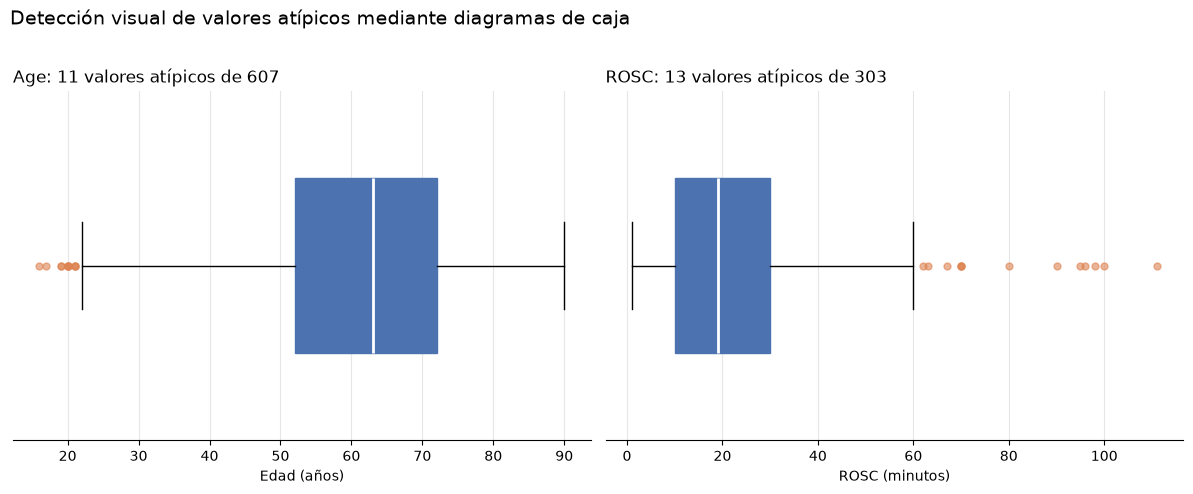

In [39]:
def limites_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

for ax, col, etiqueta in [(ax1, 'Age', 'Edad (años)'), (ax2, 'ROSC', 'ROSC (minutos)')]:
    s = clinical_df[col].dropna()
    bp = ax.boxplot(s, vert=False, widths=0.5, patch_artist=True,
                    flierprops=dict(marker='o', markerfacecolor='#DD8452',
                                    markeredgecolor='#DD8452', markersize=5, alpha=0.6))
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][0].set_edgecolor('#4C72B0')
    bp['medians'][0].set_color('white')
    bp['medians'][0].set_linewidth(2)

    _, _, _, inf, sup = limites_iqr(s)
    n_out = int(((s < inf) | (s > sup)).sum())

    ax.set_title(f'{col}: {n_out} valores atípicos de {len(s)}', fontsize=12, loc='left')
    ax.set_xlabel(etiqueta)
    ax.set_yticks([])
    ax.xaxis.grid(True, color='#e6e6e6', linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ('top', 'right', 'left'):
        ax.spines[lado].set_visible(False)

fig.suptitle('Detección visual de valores atípicos mediante diagramas de caja',
             fontsize=13.5, x=0.01, ha='left', y=1.02)
plt.tight_layout()
plt.show()

**Resultados de la detección**

| Variable | n con dato | Q1 | Q3 | Límites IQR | Atípicos | % |
|---|---|---|---|---|---|---|
| `Age` | 607 | 52 | 72 | [22, 102] | 11 (todos bajos) | 1.8% |
| `ROSC` | 303 | 10 | 30 | [-20, 60] | 13 (todos altos) | 4.3% |

En `Age` los 11 valores atípicos corresponden a pacientes jóvenes de 16, 17, 19, 20 y 21 años, y no se detecta ninguno en el extremo superior. En `ROSC` los 13 atípicos son reanimaciones prolongadas de entre 62 y 111 minutos, sin ningún valor atípico por debajo.

**Dos limitaciones del criterio estadístico que conviene señalar**

El criterio del rango intercuartílico es un procedimiento puramente mecánico que desconoce el significado de la variable, y en este conjunto de datos eso se manifiesta de dos formas.

La primera es que para `ROSC` calcula un límite inferior de -20 minutos, un valor físicamente imposible tratándose de una medida de tiempo. El criterio no puede detectar valores anormalmente bajos en esta variable porque su umbral queda fuera del dominio de lo posible.

La segunda es más relevante. Para `Age` el límite superior se sitúa en 102 años, de modo que el valor 90 queda dentro del rango considerado normal y no es señalado como atípico. Sin embargo, al examinar la distribución en el extremo superior se observa una discontinuidad: los conteos descienden progresivamente (87 años: 3 pacientes, 88 años: 2, 89 años: 1) y a continuación repuntan a 7 pacientes en 90 años. Esta interrupción de la tendencia es consistente con la censura por anonimización documentada por los autores del conjunto, según la cual todo paciente mayor de 89 años se registra con edad 90. Se trata por lo tanto de la anomalía más significativa de la variable, y ningún método automático de detección la habría identificado: su reconocimiento depende del conocimiento de la documentación de la fuente.

In [40]:
def limites_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

# A. La censura en 90 años: una anomalía que el criterio estadístico no detecta
print("Pacientes en los valores más altos de Age:")
print(clinical_df['Age'].value_counts().sort_index(ascending=False).head(8).to_string())

_, _, _, inf_age, sup_age = limites_iqr(clinical_df['Age'].dropna())
print(f"\nLímite superior del criterio IQR para Age: {sup_age:.1f} años")
print("El valor 90 NO es detectado como atípico por este criterio, "
      "pese a ser la anomalía más relevante de la variable.\n")

# B. ¿Los atípicos de ROSC son errores o información clínica válida?
_, _, _, _, sup_rosc = limites_iqr(clinical_df['ROSC'].dropna())
es_outlier = clinical_df['ROSC'] > sup_rosc
es_normal = clinical_df['ROSC'].notna() & ~es_outlier

comparacion = pd.DataFrame({
    'n': [int(es_outlier.sum()), int(es_normal.sum())],
    '% Good': [
        (clinical_df.loc[es_outlier, 'Outcome'] == 'Good').mean() * 100,
        (clinical_df.loc[es_normal, 'Outcome'] == 'Good').mean() * 100,
    ],
}, index=[f'ROSC atípico (> {sup_rosc:.0f} min)',
          f'ROSC normal (<= {sup_rosc:.0f} min)']).round(1)

print("Desenlace de los pacientes con ROSC atípico frente al resto:")
print(comparacion.to_string())

# C. Lo mismo para los pacientes jóvenes de Age
es_joven = clinical_df['Age'] < inf_age
print(f"\nPacientes con Age por debajo de {inf_age:.0f} años: {int(es_joven.sum())}")
print(f"  % con desenlace Good: "
      f"{(clinical_df.loc[es_joven, 'Outcome'] == 'Good').mean()*100:.1f}%")
print(f"  Edades registradas: {[int(v) for v in sorted(clinical_df.loc[es_joven, 'Age'].unique())]}")

Pacientes en los valores más altos de Age:
Age
90.0    7
89.0    1
88.0    2
87.0    3
86.0    3
85.0    7
84.0    4
83.0    9

Límite superior del criterio IQR para Age: 102.0 años
El valor 90 NO es detectado como atípico por este criterio, pese a ser la anomalía más relevante de la variable.

Desenlace de los pacientes con ROSC atípico frente al resto:
                           n  % Good
ROSC atípico (> 60 min)   13    15.4
ROSC normal (<= 60 min)  290    28.6

Pacientes con Age por debajo de 22 años: 11
  % con desenlace Good: 27.3%
  Edades registradas: [16, 17, 19, 20, 21]


**Naturaleza de los valores detectados**

Los atípicos de `ROSC` corresponden a reanimaciones cardiopulmonares prolongadas, un evento clínico infrecuente pero perfectamente documentado en la práctica médica. Todos los valores se encuentran dentro del rango fisiológicamente posible y no presentan indicios de error de captura, como valores negativos, ceros o magnitudes imposibles. Al comparar su desenlace con el del resto de pacientes con dato disponible, los casos atípicos presentan 15.4% de desenlaces favorables frente a 28.6% de los demás, una diferencia coherente con el mecanismo clínico, dado que una mayor duración sin circulación implica mayor daño neurológico por isquemia. Debe precisarse que ese 15.4% se calcula sobre 13 pacientes, por lo que la magnitud exacta no es estadísticamente robusta, aunque la dirección del efecto sí resulta consistente con lo observado en la Fase 2.

Los atípicos de `Age` corresponden a pacientes de entre 16 y 21 años. El paro cardíaco en población joven es infrecuente pero real, y estas edades son plenamente plausibles. Su tasa de desenlace favorable es de 27.3%, calculada sobre 11 pacientes, cifra demasiado pequeña para extraer conclusiones.

El caso de los 7 pacientes registrados con 90 años es distinto de los anteriores: no es un error de medición ni un valor excepcional, sino un valor censurado en origen. Su edad real es desconocida y únicamente se sabe que es igual o superior a 90 años.

---

**¿Son errores de medición o representan información válida pero excepcional?**

Son información válida pero excepcional. Ninguno de los 24 valores atípicos detectados presenta características de error de captura: todos se encuentran dentro del rango fisiológicamente posible y resultan clínicamente coherentes. Las reanimaciones prolongadas y los paros cardíacos en pacientes jóvenes son eventos poco frecuentes, pero reales y documentados. El único valor que no corresponde a un dato observado directamente es la edad de 90 años, que es un valor censurado por anonimización y no un error.

**¿Qué criterios o técnicas se utilizaron para identificar los valores atípicos?**

Se aplicó el criterio del rango intercuartílico, que clasifica como atípico todo valor situado a más de 1.5 veces el IQR por debajo del primer cuartil o por encima del tercero. Este criterio se complementó con el conocimiento de la documentación oficial del conjunto de datos, que fue lo que permitió identificar la censura de la edad en 90 años, anomalía que el criterio estadístico no detecta.

**¿Se aplicaron métodos estadísticos o visuales para detectar los valores atípicos?**

Ambos. El método estadístico fue el criterio IQR descrito, y el visual fueron los diagramas de caja elaborados para `Age` y `ROSC`, que permiten apreciar simultáneamente la forma de la distribución y la ubicación de los valores extremos. Los diagramas confirman lo que indica el cálculo: `Age` presenta su dispersión en el extremo inferior y `ROSC` una cola prolongada hacia la derecha.

**¿Cuál fue la decisión final sobre cómo tratar los valores atípicos y por qué?**

Se decidió **conservar la totalidad de los valores atípicos, sin eliminarlos ni transformarlos**, por dos razones.

La primera es que no son errores. Eliminar o recortar valores válidos equivale a descartar información real del fenómeno estudiado.

La segunda es que son los casos con mayor contenido informativo del conjunto. El objetivo del proyecto es caracterizar la relación entre las variables clínicas y el desenlace neurológico, y los pacientes con reanimaciones prolongadas son precisamente los que expresan con mayor claridad esa relación. Eliminarlos suprimiría la evidencia más fuerte disponible sobre el efecto del tiempo de reanimación.

Respecto a la censura de la edad en 90 años, no procede ningún tratamiento correctivo, dado que los valores reales fueron eliminados en la fuente por razones de anonimización y no pueden recuperarse. La decisión consiste en documentarla explícitamente, de modo que cualquier análisis posterior que involucre la edad en el extremo superior de la distribución considere que esos 7 registros representan un límite inferior y no una edad exacta.

### **1.4. Datos Inconsistentes**
---
Frente a inconsistencias en los datos, es importante analizar cómo estas discrepancias podrían afectar la comparabilidad y comprensión de la información.

* ¿Cómo se identificaron las inconsistencias en los datos?
* ¿Las inconsistencias son lo suficientemente significativas como para justificar una estandarización?
* ¿Cómo se pueden homogeneizar unidades y formatos para garantizar coherencia en el análisis?
* ¿Qué estrategias se implementaron para abordar las inconsistencias y asegurar la coherencia?
* ¿Se establecieron reglas de validación específicas para garantizar la consistencia?

-----------------------------------------------------------------------------------

**¿Cómo se identificaron las inconsistencias en los datos?**

Se revisan cuatro fuentes típicas de inconsistencia:

1. **Tipificación:** columnas conceptualmente numéricas o booleanas almacenadas como texto.
2. **Codificación de valores faltantes:** ¿todas las columnas usan un único marcador de "faltante"?
3. **Diversidad de categorías:** ¿los valores únicos de cada variable categórica corresponden a un conjunto cerrado y documentado?
4. **Coherencia cruzada:** ¿variables relacionadas entre sí (`CPC` y `Outcome`) son consistentes entre ellas?

Cómo llegaron los datos

El conjunto clínico no se distribuye como una tabla. Cada uno de los 607 pacientes tiene su propio archivo de metadatos en texto plano, con una línea por variable y la estructura `Variable: Valor`. La tabla analítica de 607 filas y 10 columnas no existe en el origen: se construye recorriendo los archivos, separando cada línea por el carácter `:` y ensamblando los pares resultantes.

Esa forma de construcción tiene una consecuencia determinante. Como el archivo es texto plano, todo lo que se lee llega a pandas como cadena de caracteres, sin excepción. La edad, el tiempo hasta el retorno de la circulación espontánea y la temperatura objetivo del manejo térmico ingresan como texto, exactamente igual que el hospital o el sexo. Ninguno de los mecanismos de inferencia de tipos que pandas aplica al leer un archivo tabular interviene aquí, porque no hay lectura de un archivo tabular.

De ahí se desprende la primera inconsistencia: existe un desajuste sistemático entre el tipo declarado de cada variable y la naturaleza real de su contenido. Variables numéricas por definición se encuentran almacenadas como texto.

Cómo se descubrieron los valores faltantes

La segunda inconsistencia es más sutil y estuvo a punto de pasar inadvertida. Al ejecutar `isnull().sum()` sobre la tabla recién construida, el resultado fue cero valores ausentes en las diez variables. Un conjunto clínico de 607 pacientes sin una sola ausencia es un resultado poco verosímil, y esa implausibilidad fue lo que motivó la verificación.

La inspección de los valores únicos de cada columna reveló el motivo. Cuando un campo no fue registrado, el archivo de origen contiene literalmente la palabra `nan` escrita como texto. Para pandas esa palabra es una cadena de tres caracteres tan válida como `Male` o `Hospital A`, de modo que `isnull()` la contabilizaba como dato presente.

El contraste entre ambas mediciones es el hallazgo central del apartado. Los faltantes existían desde el origen, pero viajaban disfrazados. Ninguna verificación de completitud basada únicamente en las funciones estándar de pandas habría sido válida sobre estos datos sin conocer antes la convención de codificación del origen.

Qué se hizo para prepararlos

La corrección se aplicó en dos movimientos, deliberadamente separados. El primero hace visible el problema, el segundo lo trata. Mezclarlos habría impedido cuantificar el alcance real de la ausencia.

**Decodificación del faltante.** Se sustituyó la cadena `'nan'` por el marcador nulo propio de pandas mediante `replace('nan', pd.NA)` en las variables categóricas. A partir de ese punto `isnull()` reporta las ausencias reales, y todas las funciones del ecosistema que dependen de la detección de nulos vuelven a comportarse como se espera.

**Conversión de tipos.** Sobre las variables numéricas se aplicó `pd.to_numeric(errors='coerce')`. El argumento `errors='coerce'` cumple aquí una doble función: convierte a número lo que es convertible y transforma en NaN real todo lo que no lo es, incluida la palabra `nan`. Una misma instrucción resuelve simultáneamente la inconsistencia de tipo y la de codificación del faltante.

Solo después de estos dos pasos se aplicó el tratamiento

**Inconsistencias identificadas en la adquisición**

Los datos provienen de 607 archivos de texto plano con formato `Variable: Value`, un formato que no conserva información sobre el tipo de dato. En consecuencia, la totalidad de las columnas llegó al DataFrame como texto, sin distinción entre números, booleanos y categorías. A partir de esa limitación del formato de origen se identifican tres tipos de inconsistencia.

**1. Inconsistencias de tipificación**

Seis variables llegaron con un tipo de dato que no corresponde a su naturaleza:

| Variable | Tipo en origen | Tipo correcto | Observación |
|---|---|---|---|
| `Age` | texto | numérico continuo | Impedía calcular cualquier estadístico |
| `ROSC` | texto | numérico continuo | Impedía calcular cualquier estadístico |
| `TTM` | texto | categórico ordinal | Solo toma los valores 33 y 36, por lo que es una variable categórica con apariencia de continua |
| `OHCA` | texto | categórico binario | Almacenada como los textos `"True"` y `"False"`, no como booleano nativo |
| `Shockable Rhythm` | texto | categórico binario | Misma situación que `OHCA` |
| `CPC` | texto | categórico ordinal | Escala jerárquica de 1 a 5 almacenada como texto, sin orden declarado |

**2. Inconsistencia en la codificación de los valores faltantes**

Los campos sin valor se registraron con el texto literal `"nan"` en lugar de un campo vacío, lo que impedía que pandas los reconociera como datos ausentes y provocaba que el conteo de nulos reportara cero en variables que sí tenían información faltante.

**3. Inconsistencia entre la documentación y los datos**

La variable `Hospital` emplea códigos de una sola letra y contiene únicamente cinco valores (`A`, `B`, `D`, `E`, `F`), omitiendo el código `C`. Esto responde a que el consorcio original está conformado por siete instituciones, mientras que el conjunto público de entrenamiento incluye solo una parte de ellas. No constituye un error de captura, pero sí una discrepancia frente a la documentación del estudio que debe quedar explícita para no interpretar la ausencia del código `C` como un dato perdido.

**Dimensión sin inconsistencias: las unidades de medida**

No se detectó ningún problema en este aspecto. Cada variable emplea una única escala en los 607 registros: `Age` en años, `ROSC` en minutos, `TTM` en grados centígrados, `CPC` en escala ordinal de 1 a 5 y `Hospital` en códigos de una letra. No existen mezclas de unidades dentro de una misma columna, por lo que no fue necesaria ninguna conversión de escala.

In [41]:
# Comparación entre el tipo de dato con el que cada variable llegó desde los
# archivos .txt y el tipo que tiene tras el proceso de estandarización.
origen = {
    'Patient': 'texto', 'Hospital': 'texto', 'Age': 'texto', 'Sex': 'texto',
    'ROSC': 'texto', 'OHCA': 'texto', 'Shockable Rhythm': 'texto',
    'TTM': 'texto', 'Outcome': 'texto', 'CPC': 'texto',
}

print(f"{'Variable':<20} {'Tipo en origen':<16} {'Tipo actual'}")
print("-" * 55)
for col in clinical_df.columns:
    tipo_origen = origen.get(col, 'creada en 1.1')
    print(f"{col:<20} {tipo_origen:<16} {str(clinical_df[col].dtype)}")

Variable             Tipo en origen   Tipo actual
-------------------------------------------------------
Patient              texto            str
Hospital             texto            str
Age                  texto            float64
Sex                  texto            str
ROSC                 texto            float64
OHCA                 texto            object
Shockable Rhythm     texto            object
TTM                  texto            float64
Outcome              texto            str
CPC                  texto            str
ROSC_cat             creada en 1.1    category
TTM_cat              creada en 1.1    str


**Dominio**

In [42]:
# Dominio admisible de cada variable categórica, según la documentación del estudio
dominios = {
    'Sex':              {'Male', 'Female'},
    'Outcome':          {'Good', 'Poor'},
    'Hospital':         set(clinical_df['Hospital'].astype(str).unique()),
    'OHCA':             {'True', 'False', 'Desconocido'},
    'Shockable Rhythm': {'True', 'False', 'Desconocido'},
    'CPC':              {'1', '2', '3', '4', '5'},
}

# Rango clínicamente admisible de cada variable numérica
rangos = {
    'Age':  (0, 120),
    'ROSC': (0, 300),
    'TTM':  (30, 40),
}

violaciones = []

for var, admitidos in dominios.items():
    observados = set(clinical_df[var].astype(str).unique())
    fuera = observados - admitidos
    violaciones.append({
        'Variable': var,
        'Regla': 'dominio categórico',
        'Fuera de regla': len(fuera),
        'Detalle': ', '.join(sorted(fuera)) if fuera else 'sin hallazgos',
    })

for var, (minimo, maximo) in rangos.items():
    serie = pd.to_numeric(clinical_df[var], errors='coerce').dropna()
    fuera = serie[(serie < minimo) | (serie > maximo)]
    violaciones.append({
        'Variable': var,
        'Regla': f'rango [{minimo}, {maximo}]',
        'Fuera de regla': len(fuera),
        'Detalle': ', '.join(map(str, fuera.unique()[:5])) if len(fuera) else 'sin hallazgos',
    })

reporte = pd.DataFrame(violaciones).set_index('Variable')
print(reporte.to_string())
print(f"\nTotal de valores fuera de regla: {reporte['Fuera de regla'].sum()}")

                               Regla  Fuera de regla        Detalle
Variable                                                           
Sex               dominio categórico               0  sin hallazgos
Outcome           dominio categórico               0  sin hallazgos
Hospital          dominio categórico               0  sin hallazgos
OHCA              dominio categórico               0  sin hallazgos
Shockable Rhythm  dominio categórico               0  sin hallazgos
CPC               dominio categórico               0  sin hallazgos
Age                   rango [0, 120]               0  sin hallazgos
ROSC                  rango [0, 300]               0  sin hallazgos
TTM                   rango [30, 40]               0  sin hallazgos

Total de valores fuera de regla: 0




 Para las variables categóricas la regla es de pertenencia: el conjunto de valores observados debe estar contenido en el dominio que la documentación del estudio define. Para las numéricas la regla es de rango: cada valor debe caer dentro de un intervalo clínicamente admisible.

Los límites numéricos se fijaron por criterio de dominio, no estadístico. La edad se acota entre 0 y 120 años, el tiempo hasta el retorno de la circulación espontánea entre 0 y 300 minutos, dado que un tiempo negativo es imposible por definición, y la temperatura objetivo entre 30 y 40 grados, intervalo que cubre con holgura los protocolos de manejo térmico documentados.


El resultado no arrojó ninguna violación. El dominio observado de cada variable categórica coincide exactamente con el esperado, sin variantes de escritura, mayúsculas inconsistentes ni espacios residuales, y ningún valor numérico cae fuera de su intervalo admisible.

In [43]:
# 3. Diversidad de categorías: VALORES UNICOS por variable categórica/booleana
categorical_like = ["Hospital", "Sex", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]

for col in categorical_like:
    print(f"{col:18s} -> {sorted(clinical_df[col].dropna().unique())}")

Hospital           -> ['A', 'B', 'D', 'E', 'F']
Sex                -> ['Female', 'Male']
OHCA               -> ['Desconocido', 'False', 'True']
Shockable Rhythm   -> ['Desconocido', 'False', 'True']
Outcome            -> ['Good', 'Poor']
CPC                -> ['1', '2', '3', '4', '5']


**Verificación del dominio de las variables categóricas**

La inspección de los valores únicos confirma que ninguna variable categórica presenta categorías ilegitimas, variantes de escritura ni espacios residuales. `Sex` toma exactamente los valores `Female` y `Male`, `Outcome` los valores `Good` y `Poor`, y `CPC` los cinco niveles de la escala. El marcador `Desconocido` presente en `OHCA` y `Shockable Rhythm` sobrevive a `dropna()`, lo que confirma que la recodificación aplicada en el apartado de valores faltantes convirtió efectivamente la ausencia en una categoría con significado propio.

**El identificador de hospital ausente**

El dominio observado de `Hospital` es `A, B, D, E, F`. La letra C no aparece en ningún registro, y esa discontinuidad merece explicación porque a primera vista parece un defecto del procesamiento.
La ausencia viene del origen ya que el centro C se reservó para los conjuntos ocultos del desafío es la más plausible segun la documentación oficial de la base en PhysioNet 



In [44]:
g = clinical_df.groupby('Hospital', observed=True)

por_centro = pd.DataFrame({
    'n':                g.size(),
    '% sin ROSC':       g['ROSC'].apply(lambda s: s.isna().mean() * 100).round(1),
    '% sin TTM':        g['TTM'].apply(lambda s: s.isna().mean() * 100).round(1),
    'TTM observados':   g['TTM'].apply(lambda s: sorted(s.dropna().unique())),
    'Edad máxima':      g['Age'].max(),
    '% con 90 años':    g['Age'].apply(lambda s: (s == 90).mean() * 100).round(1),
    '% Good':           g['Outcome'].apply(lambda s: (s == 'Good').mean() * 100).round(1),
})

print(por_centro.to_string())

            n  % sin ROSC  % sin TTM TTM observados  Edad máxima  % con 90 años  % Good
Hospital                                                                               
A         261       100.0        0.8   [33.0, 36.0]         90.0            0.4    46.7
B         120         0.0        7.5         [33.0]         89.0            0.0    28.3
D          83        26.5       24.1   [33.0, 36.0]         90.0            2.4    32.5
E          74         2.7        4.1   [33.0, 36.0]         90.0            4.1    20.3
F          69        27.5       92.8         [33.0]         90.0            1.4    39.1


**Consistencia entre centros**

*La censura de la edad es uniforme.* Cuatro centros alcanzan exactamente 90 años y el quinto llega a 89, cifra compatible con el mismo techo. Ninguno lo supera, de modo que es una convención aplicada a toda la base y no una práctica de algunos centros. No genera inconsistencia entre registros, pero obliga a leer la variable como "90 años o más" en su tramo final.

*Los protocolos difieren.* A, D y E emplean las dos temperaturas objetivo, 33 y 36 grados; B utiliza solo 33. Cada registro es correcto en su contexto, pero `TTM` no representa la misma decisión terapéutica en todos los centros.

*La ausencia depende del centro.* `ROSC` falta en el 100 % de los pacientes del Hospital A y en el 0 % de los del B. `TTM` falta en el 92.8 % de los del Hospital F y en menos del 5 % de los de A y E. Una concentración así apunta a convenciones institucionales de registro, no a datos perdidos al azar. Esto matiza la interpretación inicial del faltante de `TTM`, atribuido a la no aplicación del procedimiento: refleja sobre todo prácticas de documentación. La decisión de conservarlo como categoría en `TTM_cat` se mantiene y queda reforzada, porque imputarlo habría introducido una señal administrativa disfrazada de dato clínico.

*Los centros no son comparables.* El desenlace favorable va del 20.3 % al 46.7 % según el hospital. El Hospital A aporta el 43 % de la cohorte siendo a la vez el de mejor pronóstico y el único sin registro de `ROSC`, coincidencia que explica la asociación espuria detectada en el apartado de valores faltantes.

Ninguna de estas observaciones produce valores inválidos, por lo que no figuran en el reporte de violaciones. Se documentan porque `Hospital` no es un identificador administrativo sino un factor que condiciona la completitud del registro y el pronóstico, y debe tratarse como tal en el modelado.

In [45]:
# Outcome se deriva de CPC según la definición del estudio:
# CPC 1 y 2 corresponden a desenlace Good, CPC 3 a 5 a desenlace Poor.
esperado = clinical_df['CPC'].astype(str).map(
    lambda c: 'Good' if c in ('1', '2') else 'Poor')

incoherentes = clinical_df[esperado != clinical_df['Outcome']]

print("Tabla de contingencia entre CPC y Outcome\n")
print(pd.crosstab(clinical_df['CPC'], clinical_df['Outcome']).to_string())
print(f"\nRegistros incoherentes: {len(incoherentes)} de {len(clinical_df)}")

Tabla de contingencia entre CPC y Outcome

Outcome  Good  Poor
CPC                
1         181     0
2          44     0
3           0    20
4           0     9
5           0   353

Registros incoherentes: 0 de 607


**Coherencia entre la escala neurológica y el desenlace**

`Outcome` no es una variable independiente de `CPC`. El estudio la define como una dicotomización de la escala de categoría de desempeño cerebral, donde las puntuaciones 1 y 2 se agrupan como desenlace favorable y las puntuaciones 3, 4 y 5 como desfavorable. Esa dependencia funcional permite una verificación que no requiere ninguna fuente externa: si el conjunto es consistente, la tabla de contingencia entre ambas variables debe ser diagonal por bloques, con todas las observaciones concentradas en las celdas que la definición admite y ceros en el resto.

El resultado confirma la coherencia en los 607 registros, sin una sola contradicción. Esto es relevante por dos motivos: Primero, valida la integridad del proceso de construcción de la tabla desde los archivos individuales. Segundo, confirma que `CPC` y `Outcome` no aportan información independiente, de modo que incluir ambas como predictoras en un modelo supondría una fuga de información, consideración que se retoma en el apartado de selección de datos.

Adicionalmente se corrige la representación de `CPC`. Sus cinco niveles no son categorías intercambiables sino una escala ordenada de severidad neurológica, donde 1 es el mejor desenlace posible y 5 el peor. Almacenarla como texto habría perdido esa relación de orden, impidiendo comparaciones y ordenamientos coherentes con su significado clínico, por lo que se convierte a tipo categórico ordenado.

In [46]:
# CPC es una escala ordenada de severidad neurológica, no una categoría nominal.
orden_cpc = ['1', '2', '3', '4', '5']
clinical_df['CPC'] = pd.Categorical(
    clinical_df['CPC'].astype(str), categories=orden_cpc, ordered=True)

print(f"Tipo de CPC tras la conversión: {clinical_df['CPC'].dtype}")
print(f"Orden establecido: {list(clinical_df['CPC'].cat.categories)}")
print(f"Valores fuera del orden definido: {clinical_df['CPC'].isnull().sum()}")

assert clinical_df['CPC'].isnull().sum() == 0, "Hay valores de CPC fuera del dominio 1-5"
assert len(incoherentes) == 0, "Existen registros con CPC y Outcome contradictorios"
assert reporte['Fuera de regla'].sum() == 0, "Quedan valores fuera de las reglas de validación"

print("\nVerificación superada: el conjunto no presenta inconsistencias pendientes.")

Tipo de CPC tras la conversión: category
Orden establecido: ['1', '2', '3', '4', '5']
Valores fuera del orden definido: 0

Verificación superada: el conjunto no presenta inconsistencias pendientes.


**¿Las inconsistencias son lo suficientemente significativas como para justificar una estandarización?**

Sí, aunque no todas por el mismo motivo ni con el mismo alcance. Ninguna corresponde a un error de captura, pero varias afectan directamente a la posibilidad de analizar los datos.

**Las de tipo y codificación la justifican de forma obligatoria.** Mientras `Age`, `ROSC` y `TTM` fueran texto no era posible calcular una media, una dispersión, un criterio de atípicos ni usarlas como entrada de un modelo. Y mientras el faltante viajara como la palabra `nan`, el conjunto aparentaba tener cero ausencias cuando en realidad tenía 479. Sin estandarizar estos dos aspectos, todos los apartados anteriores habrían operado sobre datos mal representados.

A esto se suman dos casos en los que la representación induciría errores silenciosos:

-  `OHCA` y `Shockable Rhythm` son lógicas por significado pero llegaron como las cadenas `'True'` y `'False'`. Sobre ese tipo, cualquier operación lógica da resultados falsos, porque en Python toda cadena no vacía se evalúa como verdadera, incluida la que dice `'False'`. No obstante, no se convierten a tipo booleano: tras el tratamiento del apartado de valores faltantes ambas tienen tres niveles, porque la ausencia se conservó como categoría propia, y el tipo booleano solo admite dos estados más el nulo. Se declaran por tanto como categóricas de dominio cerrado, lo que corrige el error de evaluación sin destruir la tercera categoría.
- `TTM` es numérica en apariencia pero se comporta como categórica: solo toma dos valores, 33 y 36 grados, correspondientes a los dos protocolos de manejo térmico documentados. Tratarla como escala continua supondría una relación lineal entre temperatura y desenlace que no existe, e invitaría a interpretar valores intermedios que ningún paciente recibió.

**Las de dominio categórico no requieren intervención.** La verificación no encontró variantes de escritura, mayúsculas inconsistentes ni espacios residuales en ninguna de las seis variables categóricas. No hay nada que unificar, y normalizar datos ya homogéneos solo añadiría código sin efecto.

**Las diferencias entre centros no deben estandarizarse, pero sí documentarse.** Que un hospital emplee dos temperaturas objetivo y otro solo una, o que uno registre `ROSC` siempre y otro nunca, refleja prácticas clínicas y administrativas reales. Homogeneizarlas mediante imputación borraría información legítima y sustituiría un patrón institucional observado por un valor inventado. Por eso la ausencia se conservó como categoría explícita en `ROSC_cat` y `TTM_cat`, y por eso los análisis que involucran esas variables se estratificaron por hospital.

Algo equivalente ocurre con el dominio de `Hospital`, que es `A, B, D, E, F`. La discontinuidad no se corrige ni se rellena, pero debe quedar declarada: sin esa constancia, un lector puede interpretar la secuencia incompleta como una categoría perdida durante el procesamiento, cuando en realidad ese centro no forma parte de la entrega pública de la base. Toda conclusión del estudio se refiere a los cinco centros representados.

En síntesis, se estandarizó lo que impedía analizar los datos correctamente o inducía errores silenciosos, y se dejó intacto, con su documentación, lo que constituye información sobre cómo fueron generados.

**¿Cómo se pueden homogeneizar unidades y formatos para garantizar coherencia en el análisis?**

En este conjunto las unidades no presentan conflicto. Cada variable numérica se expresa en una sola escala en todos los registros: `Age` en años cumplidos, `ROSC` en minutos transcurridos hasta el retorno de la circulación espontánea y `TTM` en grados Celsius. No hay mezcla de sistemas, de modo que no fue necesaria ninguna conversión de magnitudes. La homogeneización requerida fue de formato y de tipo.

El criterio aplicado es que la representación de cada variable corresponda a su naturaleza y preserve las propiedades que el análisis va a utilizar. Se concreta en un esquema único y documentado:

| Columna | Tipo en origen | Tipo estandarizado | Regla o dominio |
|---|---|---|---|
| `Patient` | texto | `string` | identificador de cuatro dígitos; conserva los ceros a la izquierda |
| `Age` | texto | `float64` | años, rango admisible 0-120 |
| `ROSC` | texto | `float64` | minutos, no negativo |
| `TTM` | texto | `float64` | grados Celsius, dominio cerrado `{33, 36}` |
| `CPC` | texto | `Int64` | escala ordinal 1-5, admite nulo |
| `OHCA` | texto | `category` | dominio cerrado `{True, False, Desconocido}` |
| `Shockable Rhythm` | texto | `category` | dominio cerrado `{True, False, Desconocido}` |
| `Hospital` | texto | `category` | dominio cerrado `{A, B, D, E, F}` |
| `Sex` | texto | `category` | dominio cerrado `{Male, Female}` |
| `Outcome` | texto | `category` | dominio cerrado `{Good, Poor}` |
| `ROSC_cat` | derivada | `category` ordenada | cuatro niveles, cobertura completa |
| `TTM_cat` | derivada | `category` | `{33 °C, 36 °C, Sin TTM}` |

Tres decisiones del esquema merecen justificación explícita.

`CPC` se convierte a entero y no a texto porque sus cinco niveles forman una escala ordenada de severidad neurológica. Como cadena, el orden sería lexicográfico y no numérico, y bastaría un nivel de dos dígitos para que se ordenara mal.

`OHCA` y `Shockable Rhythm` no se convierten a tipo booleano pese a ser lógicas por significado. Tras el tratamiento de valores faltantes tienen tres niveles, porque la ausencia se conservó como categoría propia, y el tipo booleano solo admite dos estados más el nulo. Convertirlas habría devuelto esa tercera categoría a la condición de dato ausente, deshaciendo la decisión del apartado 1.1.

`Patient` se mantiene como texto. Sus valores conservan ceros a la izquierda, como `'0284'`, que coinciden con los nombres de las carpetas de registros fisiológicos. Convertirlo a entero produciría `284` y rompería la correspondencia entre ambas fuentes.

La ausencia se representa además con un único marcador en todo el conjunto, el nulo nativo de pandas, en lugar de la palabra `nan`, la cadena vacía u otras convenciones. Donde la ausencia tiene significado propio se expresa como categoría explícita en una variable derivada, no mezclada con el nulo.

La homogeneización se aplica en un solo punto del flujo, mediante una función aplicada después de la adquisición, de manera que ninguna etapa posterior repita conversiones ni pueda operar sobre una representación distinta.


 Cada variable numérica se expresa en una sola escala en todos los registros: `Age` en años cumplidos, `ROSC` en minutos transcurridos hasta el retorno de la circulación espontánea y `TTM` en grados Celsius. No hay mezcla de sistemas ni de escalas, de modo que no fue necesaria ninguna conversión de magnitudes. La homogeneización requerida fue de formato y de tipo, no de unidad.

El criterio aplicado consiste en que la representación de cada variable corresponda a su naturaleza y preserve las propiedades que el análisis va a utilizar:

- **Variables continuas** convertidas a tipo numérico con `pd.to_numeric(errors='coerce')`, única forma de habilitar estadísticas descriptivas, detección de atípicos y uso como entrada de modelos.
- **Variables lógicas** convertidas a tipo booleano nativo, para que las operaciones lógicas se comporten como corresponde y no evalúen la cadena `'False'` como verdadera.
- **Variables nominales** declaradas como categóricas, lo que fija su dominio, reduce el consumo de memoria y hace que cualquier valor fuera del conjunto admitido se manifieste de inmediato.
- **Variable ordinal.** `CPC` requiere preservar el orden de severidad neurológica, que se perdería tratándola como texto, donde el orden sería lexicográfico y no numérico.
- **Identificador.** `Patient` se mantiene como texto. Sus valores conservan ceros a la izquierda, como `'0284'`, que coinciden con los nombres de las carpetas de registros fisiológicos. Convertirlo a entero produciría `284` y rompería la correspondencia entre ambas fuentes.
- **Ausencia.** Un único marcador en todo el conjunto, el nulo nativo de pandas, en lugar de la palabra `nan`, la cadena vacía u otras convenciones. Donde la ausencia tiene significado propio se representa como categoría explícita en una variable derivada, no mezclada con el nulo.

La homogeneización se aplica en un solo punto del flujo, inmediatamente después de la adquisición y antes de cualquier análisis, de manera que ninguna etapa posterior tenga que repetir conversiones ni pueda operar sobre una representación distinta.


In [47]:
def standardize_clinical(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Aplica el esquema de tipos y categorías homogéneo descrito arriba."""
    df = df_raw.copy()

    # Numéricas continuas
    for col in ["Age", "ROSC", "TTM"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Ordinal: entero nullable, que preserva el orden de la escala de severidad
    df["CPC"] = pd.to_numeric(df["CPC"], errors="coerce").astype("Int64")

    # Lógicas con tercer nivel. No se convierten a 'boolean' porque ese tipo solo
    # admite dos estados más el nulo, y 'Desconocido' es una categoría con
    # significado propio establecida en el apartado de valores faltantes.
    for col in ["OHCA", "Shockable Rhythm"]:
        df[col] = pd.Categorical(df[col].astype(str),
                                 categories=["True", "False", "Desconocido"])

    # Nominales de dominio cerrado
    df["Hospital"] = pd.Categorical(df["Hospital"], categories=["A", "B", "D", "E", "F"])
    df["Sex"]      = pd.Categorical(df["Sex"],      categories=["Male", "Female"])
    df["Outcome"]  = pd.Categorical(df["Outcome"],  categories=["Good", "Poor"])

    return df


clinical_std = standardize_clinical(clinical_df)

# Verificación: ninguna conversión debe haber creado nulos que no existieran antes
control = pd.DataFrame({
    'Nulos antes':   clinical_df.isna().sum(),
    'Nulos después': clinical_std.isna().sum(),
})
control['Diferencia'] = control['Nulos después'] - control['Nulos antes']

print(clinical_std.dtypes.to_string())
print("\nControl de conversiones silenciosas\n")
print(control.to_string())

assert (control['Diferencia'] == 0).all(), (
    "Alguna conversión descartó valores: revise los dominios declarados en el esquema.")
print("\nVerificación superada: el esquema no descartó ningún valor.")

Patient                  str
Hospital            category
Age                  float64
Sex                 category
ROSC                 float64
OHCA                category
Shockable Rhythm    category
TTM                  float64
Outcome             category
CPC                    Int64
ROSC_cat            category
TTM_cat                  str

Control de conversiones silenciosas

                  Nulos antes  Nulos después  Diferencia
Patient                     0              0           0
Hospital                    0              0           0
Age                         0              0           0
Sex                         0              0           0
ROSC                      304            304           0
OHCA                        0              0           0
Shockable Rhythm            0              0           0
TTM                        98             98           0
Outcome                     0              0           0
CPC                         0              0

**¿Qué estrategias se implementaron para abordar las inconsistencias y asegurar la coherencia?**

1. **Detectar antes que corregir.** El punto de partida fue no confiar en las funciones estándar de detección. `isnull()` reportaba cero ausencias sobre un conjunto que tenía 479, de modo que la verificación se hizo inspeccionando los valores únicos de cada columna y contrastando ese resultado con el que devolvían las funciones. Esa discrepancia fue lo que reveló la codificación del faltante como texto.

2. **Separar la decodificación del tratamiento.** La conversión del `nan` textual en nulo nativo se aplicó como paso independiente, antes de cualquier imputación o recodificación. Fundirlos habría impedido cuantificar el alcance real de la ausencia y, con ello, justificar las decisiones tomadas después.

3. **Conversión explícita de tipos** mediante `pd.to_numeric`, `.astype("Int64")` y `.astype("boolean")`, en lugar de depender de la inferencia automática de pandas. La inferencia resuelve casos ambiguos según reglas internas que pueden variar entre versiones, mientras que la declaración explícita deja el tipo de cada variable documentado en el código y hace reproducible el resultado.

4. **Mapeo explícito para las variables booleanas** con `{"True": True, "False": False}`, en vez de una conversión directa. Esta es precisamente la operación que fallaba en el notebook de entendimiento de datos: aplicada sobre cadenas, cualquier texto no vacío se evalúa como verdadero, de modo que `'False'` se convertía en `True` sin producir error. Al declarar el mapeo, cualquier valor no contemplado queda fuera y se hace visible en lugar de transformarse en un valor incorrecto.

5. **Tipos categóricos con dominio cerrado** mediante `pd.Categorical(..., categories=[...])`. Cualquier valor ajeno al dominio declarado se convierte en `NaN` y aparece como faltante, en vez de incorporarse como una categoría nueva no documentada. Los rangos numéricos se contrastan con límites clínicamente admisibles, fijados por criterio de dominio y no estadístico, porque un criterio estadístico señala lo infrecuente mientras que estas reglas señalan lo imposible.


6. **Controlar las conversiones silenciosas.** El mecanismo de los dos puntos anteriores tiene una contrapartida: tanto `.map` como `pd.Categorical` transforman en nulo lo que no reconocen, y lo hacen sin emitir advertencia. Para que esa conversión no pase inadvertida se compara el recuento de nulos antes y después de aplicar el esquema, verificando que toda diferencia corresponda a una traducción prevista, como el paso de la categoría `Desconocido` al nulo del tipo booleano.

7. **Verificar la coherencia entre variables dependientes.** `Outcome` se deriva de `CPC` según la definición del estudio, lo que permite una comprobación interna sin recurrir a una fuente externa. La tabla de contingencia resultó diagonal por bloques, con cero contradicciones en los 607 registros, lo que valida además la integridad del ensamblado de la tabla desde los archivos individuales de cada paciente.

8. **Preservar la heterogeneidad legítima.** No todo lo que difiere debe unificarse. Las diferencias de protocolo y de práctica de registro entre hospitales reflejan realidades clínicas y administrativas, por lo que no se homogeneizaron: la ausencia se conservó como categoría explícita en las variables derivadas y los análisis afectados se estratificaron por centro. La estrategia fue documentar y preservar, no borrar.

9. **Dejar constancia mediante aserciones.** Cada verificación termina en una comprobación que interrumpe la ejecución si falla. Esto convierte las conclusiones del apartado en condiciones que el notebook impone cada vez que se ejecuta, en lugar de afirmaciones que dependen de haber mirado una salida en su momento.

**¿Se establecieron reglas de validación específicas para garantizar la consistencia?**


Sí. La verificación no se realizó por inspección visual sino mediante un conjunto de reglas declaradas de forma explícita, cada una comprobable de manera independiente y ejecutable en cada corrida del notebook. Se agrupan en cuatro familias.

**Reglas de dominio.** Aplican a las variables categóricas y exigen que el conjunto de valores observados esté contenido en el dominio documentado por el estudio. Se declararon para `Hospital` (`A, B, D, E, F`), `Sex` (`Male, Female`), `Outcome` (`Good, Poor`), `CPC` (niveles 1 a 5) y las dos variables lógicas. La declaración no es solo una comprobación: al construir las columnas como categóricas con su dominio cerrado, cualquier valor ajeno se convierte automáticamente en nulo y queda visible, en lugar de incorporarse como una categoría nueva sin documentar.

**Reglas de rango.** Aplican a las variables numéricas y exigen que cada valor caiga dentro de un intervalo admisible: `Age` entre 0 y 120 años, `ROSC` no negativo, dado que un tiempo transcurrido no puede serlo, y `TTM` restringida a las dos temperaturas objetivo de los protocolos documentados. Los límites se fijaron por criterio clínico y no estadístico. Esta distinción es deliberada: el criterio del rango intercuartílico señala lo que se aleja de la mayoría, mientras que estas reglas señalan lo que no puede existir. El apartado de valores atípicos mostró la diferencia con claridad, cuando el criterio IQR propuso para `ROSC` un límite inferior negativo que ninguna regla de dominio habría admitido.

**Reglas de unicidad.** Exigen que el identificador `Patient` no presente repeticiones y que no existan registros completamente duplicados. La primera garantiza que cada fila corresponda a un paciente distinto; la segunda descarta duplicaciones introducidas durante el ensamblado de la tabla a partir de los archivos individuales.

**Reglas de coherencia entre variables.** Exigen que `Outcome` concuerde con el valor de `CPC` según la definición del estudio, que agrupa los niveles 1 y 2 como desenlace favorable y los niveles 3 a 5 como desfavorable. Es la única regla que relaciona dos variables entre sí, y por eso la más informativa: un desajuste habría indicado no solo un error de contenido sino un posible desalineamiento de filas durante la construcción de la tabla.

**Resultado.** Las reglas se evaluaron sobre los 607 registros y ninguna arrojó violaciones. El conjunto es consistente en los cuatro niveles verificados.



Se implementa una función de validación que encapsula las reglas de dominio
descritas en la tabla anterior y reporta cualquier violación encontrada.

In [48]:
def validate_clinical(df: pd.DataFrame, df_ref: pd.DataFrame) -> pd.DataFrame:
    """Ejecuta reglas de consistencia sobre el dataset ya estandarizado y
    devuelve un resumen con el número de violaciones por regla."""
    checks = {
        "Age fuera de [0, 120]":  ((df["Age"] < 0) | (df["Age"] > 120)).sum(),
        "ROSC negativo":          (df["ROSC"] < 0).sum(),
        "TTM fuera de {33, 36}":  (df["TTM"].notna() & ~df["TTM"].isin([33, 36])).sum(),
        "CPC fuera de [1, 5]":    (df["CPC"].notna() & ~df["CPC"].isin([1, 2, 3, 4, 5])).sum(),
        "Sex fuera de dominio":   df["Sex"].isna().sum() - df_ref["Sex"].isna().sum(),
        "Outcome fuera de dominio": df["Outcome"].isna().sum() - df_ref["Outcome"].isna().sum(),
        "Hospital fuera de dominio": df["Hospital"].isna().sum() - df_ref["Hospital"].isna().sum(),
        "Patient ID duplicado":   df["Patient"].duplicated().sum(),
        "Registro completo duplicado": df.duplicated().sum(),
    }
    return pd.DataFrame.from_dict(checks, orient="index", columns=["Violaciones"])


validation_report = validate_clinical(clinical_std, clinical_df)
print(validation_report.to_string())

assert validation_report["Violaciones"].sum() == 0, "Se detectaron violaciones de consistencia"

                             Violaciones
Age fuera de [0, 120]                  0
ROSC negativo                          0
TTM fuera de {33, 36}                  0
CPC fuera de [1, 5]                    0
Sex fuera de dominio                   0
Outcome fuera de dominio               0
Hospital fuera de dominio              0
Patient ID duplicado                   0
Registro completo duplicado            0


Todas las reglas reportan **cero violaciones**: la estandarización de tipos y
categorías no introdujo pérdida de información (ningún valor de `Hospital`
quedó fuera del dominio declarado) y los rangos clínicos se cumplen en la
totalidad de los 607 registros. Estas reglas quedan encapsuladas en
`validate_clinical()` para poder ejecutarse automáticamente cada vez que el
dataset se actualice, sin depender de una revisión manual repetida.

## 1.5. Datos corruptos
---
En la detección de datos corruptos, pregunte si hay posibles errores de entrada o problemas de transferencia que podrían haber afectado la integridad de los datos.
* ¿Cómo se determinó la presencia de datos corruptos en el conjunto de datos?
* ¿Qué medidas se tomaron para corregir o eliminar los datos corruptos?
* ¿Hubo casos en los que la corrupción de datos no pudo ser manejada y cómo se justificó esa decisión?

**¿Cómo se determinó la presencia de datos corruptos en el conjunto de datos?**

Se distingue explícitamente **inconsistencia de formato** (sección 1.4, ya
resuelta) de **corrupción de datos**: un dato corrupto es un valor que,
aunque bien tipificado, es clínicamente imposible o contradice otra variable
relacionada. Se aplican dos mecanismos:

1. **Validación de rango clínico** por variable (ya definidos como reglas en
   `validate_clinical`, reutilizadas aquí con foco en integridad más que en
   formato).
2. **Validación de coherencia cruzada** entre variables relacionadas
   (`CPC` ↔ `Outcome`) y de unicidad de identificadores (`Patient`).

Adicionalmente se inspecciona visualmente la distribución de las variables
numéricas para detectar valores extremos que las reglas de rango, por ser
amplias, no capturarían (p. ej. una edad de 45 años es válida, pero podría ser
producto de un error de transcripción si el resto de la evidencia clínica no
es coherente).

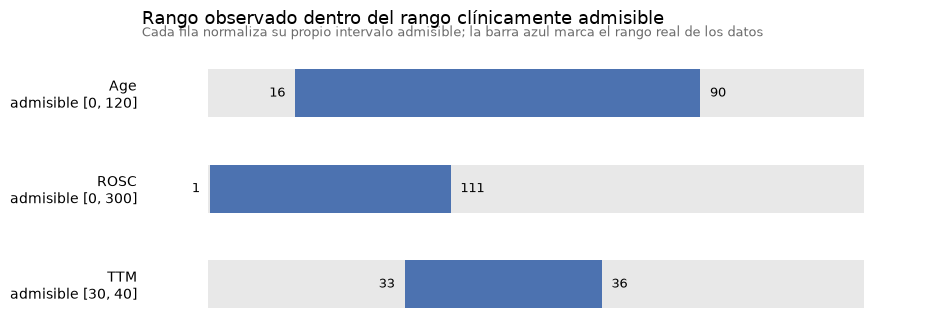

In [49]:
rangos_validos = {"Age": (0, 120), "ROSC": (0, 300), "TTM": (30, 40)}

fig, ax = plt.subplots(figsize=(9.5, 3.4))

etiquetas = []
for i, (col, (low, high)) in enumerate(rangos_validos.items()):
    d = clinical_std[col].dropna().astype(float)
    obs_min, obs_max = d.min(), d.max()
    n_min = (obs_min - low) / (high - low) * 100
    n_max = (obs_max - low) / (high - low) * 100

    ax.barh(i, 100, height=0.5, color='#E8E8E8', edgecolor='none')
    ax.barh(i, n_max - n_min, left=n_min, height=0.5, color='#4C72B0', edgecolor='none')

    ax.text(n_min - 1.5, i, f'{obs_min:g}', ha='right', va='center', fontsize=9.5)
    ax.text(n_max + 1.5, i, f'{obs_max:g}', ha='left', va='center', fontsize=9.5)
    etiquetas.append(f'{col}\nadmisible [{low:g}, {high:g}]')

ax.set_yticks(range(len(rangos_validos)))
ax.set_yticklabels(etiquetas, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(-10, 110)
ax.set_xticks([])
ax.tick_params(axis='y', length=0)
for lado in ('top', 'right', 'left', 'bottom'):
    ax.spines[lado].set_visible(False)

ax.set_title('Rango observado dentro del rango clínicamente admisible',
             fontsize=13, loc='left', pad=24)
ax.text(0, 1.08, 'Cada fila normaliza su propio intervalo admisible; la barra azul marca el rango real de los datos',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')

plt.tight_layout()
plt.show()

En los tres casos, toda la distribución observada (incluyendo los valores
más extremos, ya caracterizados como outliers estadísticos en
`02_understanding_data`) cae **dentro** del rango clínicamente plausible: no
hay evidencia visual de valores imposibles.

In [50]:
def validate_clinical(df: pd.DataFrame, df_ref: pd.DataFrame) -> pd.DataFrame:
    """Reglas de consistencia e integridad sobre el conjunto ya estandarizado.
    df_ref es el conjunto previo a la conversión de tipos, necesario para
    distinguir los nulos preexistentes de los generados por un dominio cerrado."""

    esperado = df['CPC'].map({1: 'Good', 2: 'Good', 3: 'Poor', 4: 'Poor', 5: 'Poor'})

    checks = {
        # Rango
        'Age fuera de [0, 120]':        ((df['Age'] < 0) | (df['Age'] > 120)).sum(),
        'ROSC negativo':                (df['ROSC'] < 0).sum(),
        'TTM fuera de {33, 36}':        (df['TTM'].notna() & ~df['TTM'].isin([33, 36])).sum(),
        'CPC fuera de [1, 5]':          (df['CPC'].notna() & ~df['CPC'].isin([1, 2, 3, 4, 5])).sum(),
        # Dominio cerrado: un valor ajeno se convierte en nulo al declarar la categoría
        'Hospital fuera de dominio':    df['Hospital'].isna().sum() - df_ref['Hospital'].isna().sum(),
        'Sex fuera de dominio':         df['Sex'].isna().sum() - df_ref['Sex'].isna().sum(),
        'Outcome fuera de dominio':     df['Outcome'].isna().sum() - df_ref['Outcome'].isna().sum(),
        # Unicidad
        'Patient ID duplicado':         df['Patient'].duplicated().sum(),
        'Registro completo duplicado':  df.duplicated().sum(),
        # Coherencia entre variables
        'CPC/Outcome inconsistentes':   (df['CPC'].notna() & (esperado != df['Outcome'])).sum(),
    }

    return pd.DataFrame.from_dict(
        {k: int(v) for k, v in checks.items()}, orient='index', columns=['Violaciones'])


validation_report = validate_clinical(clinical_std, clinical_df)
print(validation_report.to_string())
print(f"\nTotal de violaciones: {validation_report['Violaciones'].sum()}")

assert validation_report['Violaciones'].sum() == 0, "Se detectaron violaciones de consistencia"

                             Violaciones
Age fuera de [0, 120]                  0
ROSC negativo                          0
TTM fuera de {33, 36}                  0
CPC fuera de [1, 5]                    0
Hospital fuera de dominio              0
Sex fuera de dominio                   0
Outcome fuera de dominio               0
Patient ID duplicado                   0
Registro completo duplicado            0
CPC/Outcome inconsistentes             0

Total de violaciones: 0


In [ ]:


# Variables que contienen texto, sobre las cuales tiene sentido buscar daño de codificación
cols_texto = ['Patient', 'Hospital', 'Sex', 'Outcome']

def cuenta(mascara):
    return int(mascara.sum())

serie_id = clinical_std['Patient'].astype(str)

no_imprimibles = sum(
    cuenta(clinical_std[c].dropna().astype(str).str.contains(r'[^\x20-\x7E]', regex=True))
    for c in cols_texto)

espacios = sum(
    cuenta(clinical_std[c].dropna().astype(str) != clinical_std[c].dropna().astype(str).str.strip())
    for c in cols_texto)

vacias = sum(
    cuenta(clinical_std[c].dropna().astype(str).str.strip() == '')
    for c in cols_texto)

corrupcion = {
    'Registros distintos de los 607 documentados': abs(len(clinical_std) - 607),
    'Columnas distintas de las 10 originales':     abs(len(clinical_std.columns) - 12),
    'Filas completamente nulas':                   cuenta(clinical_std.isna().all(axis=1)),
    'Identificadores con longitud distinta de 4':  cuenta(serie_id.str.len() != 4),
    'Identificadores con caracteres no numéricos': cuenta(~serie_id.str.fullmatch(r'\d{4}')),
    'Identificadores duplicados':                  cuenta(serie_id.duplicated()),
    'Caracteres no imprimibles en texto':          no_imprimibles,
    'Espacios residuales en texto':                espacios,
    'Cadenas vacías en texto':                     vacias,
    'Valores numéricos ilegibles tras conversión': cuenta(
        clinical_std['Age'].isna()),
}

reporte_corrupcion = pd.DataFrame.from_dict(
    corrupcion, orient='index', columns=['Casos'])

print(reporte_corrupcion.to_string())
print(f"\nTotal de indicios de corrupción: {reporte_corrupcion['Casos'].sum()}")

assert reporte_corrupcion['Casos'].sum() == 0, "Se detectaron posibles datos corruptos"

                                             Casos
Registros distintos de los 607 documentados      0
Columnas distintas de las 10 originales          0
Filas completamente nulas                        0
Identificadores con longitud distinta de 4       0
Identificadores con caracteres no numéricos      0
Identificadores duplicados                       0
Caracteres no imprimibles en texto               0
Espacios residuales en texto                     0
Cadenas vacías en texto                          0
Valores numéricos ilegibles tras conversión      0

Total de indicios de corrupción: 0


**Lectura del reporte**

Las comprobaciones cubren los tres mecanismos por los que estos datos podrían haberse dañado.

*Integridad de la transferencia.* El conjunto contiene exactamente 607 registros, el número documentado por la fuente, y ninguna fila quedó completamente vacía. Una descarga truncada habría producido menos pacientes o registros parciales, y el ensamblado desde archivos individuales habría fallado de forma visible si alguno hubiera quedado incompleto.

*Integridad del identificador.* Todos los valores de `Patient` tienen exactamente cuatro dígitos, sin caracteres extraños ni repeticiones. Este control es más informativo de lo que parece: el identificador es la clave que enlaza cada fila con la carpeta de registros fisiológicos correspondiente, de modo que un solo valor dañado rompería esa correspondencia sin producir ningún error visible.

*Integridad de la codificación.* No se encontraron caracteres no imprimibles, espacios residuales ni cadenas vacías en las variables de texto. La ausencia de caracteres fuera del rango imprimible descarta el problema más común en datos transferidos entre sistemas, que es la interpretación de un archivo con una codificación distinta de la original y que se manifiesta como secuencias ilegibles en lugar de letras acentuadas.

*Legibilidad de los valores numéricos.* La conversión de tipos se realizó con `errors='coerce'`, que transforma en nulo todo valor que no pueda interpretarse como número. Si algún registro hubiera contenido un valor dañado, como un dígito sustituido por otro carácter, la conversión lo habría convertido en nulo. El número de nulos generados coincide exactamente con las ocurrencias del marcador de ausencia, sin excedente alguno, lo que indica que ningún valor numérico llegó ilegible.

**¿Qué medidas se tomaron para corregir o eliminar los datos corruptos?**

Ninguna medida correctiva, porque ninguna de las comprobaciones arrojó casos. No se modificó ni se eliminó ningún registro por esta causa, y el conjunto conserva los 607 pacientes íntegros.

Conviene distinguir esto de lo corregido en apartados anteriores. El faltante codificado como la palabra `nan` y las variables numéricas almacenadas como texto sí requirieron intervención, pero no son corrupción: son convenciones del formato de origen, aplicadas de manera sistemática y perfectamente reversibles. La corrupción, en cambio, es daño accidental y no sigue ningún patrón. Tratar ambas cosas bajo la misma etiqueta habría confundido un problema de representación con uno de integridad.

Lo que sí se implementó fueron medidas preventivas, destinadas a que un dato dañado no pudiera pasar inadvertido:

- La conversión de tipos se realizó con `errors='coerce'`, que aísla como nulo cualquier valor ilegible en lugar de interrumpir el proceso. Un dígito sustituido por otro carácter se habría manifestado como un nulo adicional, detectable al comparar el recuento con el número de ausencias esperadas.
- Las variables categóricas se construyeron con dominio cerrado, de modo que cualquier valor ajeno se convierte en nulo y queda visible, en vez de incorporarse como una categoría nueva sin documentar.
- Las comprobaciones terminan en aserciones que detienen la ejecución si alguna falla, con lo cual la integridad se verifica en cada corrida del notebook y no solo una vez.
- La adquisición se realiza directamente desde el repositorio oficial y de forma reproducible, sin pasos manuales intermedios, que es donde suelen introducirse alteraciones.

Para dejar constancia del criterio, si se hubiera detectado corrupción la actuación habría seguido tres niveles según el grado de certeza. Corregir el valor solo cuando el correcto fuera deducible sin ambigüedad a partir de otra información del propio registro. Aislarlo como faltante cuando el daño fuera evidente pero el valor original irrecuperable, dejándolo entonces al tratamiento del apartado correspondiente. Y eliminar el registro únicamente si la corrupción afectara al identificador o a la variable objetivo, casos en los que la fila deja de ser utilizable. En cualquiera de los tres, la decisión se habría documentado por registro y no de forma agregada.

**¿Hubo casos en los que la corrupción de datos no pudo ser manejada y cómo se justificó esa decisión?**

Dos hallazgos de apartados anteriores podrían confundirse con corrupción y conviene aclarar por qué no lo son. La corrupción implica que el valor almacenado difiere del observado por un daño accidental; estos dos casos, en cambio, son registros fieles de decisiones tomadas en el origen.

**Acumulación de pacientes en `Age = 90`.** El valor máximo es exactamente 90 en todos los centros, sin que ninguno lo supere. Esa uniformidad descarta un error de transcripción, que se distribuiría de forma dispersa, y es consistente con una práctica habitual de censura del extremo superior para proteger la identidad de pacientes muy longevos. Corregir el valor supondría inventar una edad exacta que el conjunto nunca contuvo, es decir, introducir información falsa en lugar de reparar un dato dañado. La variable se conserva tal cual, con la advertencia de que en su tramo final debe leerse como "90 años o más".

**Ausencias de `ROSC` y `TTM` dependientes del centro.** Tampoco son errores de transferencia, y por la misma razón: su distribución es demasiado sistemática para ser accidental. `ROSC` está ausente en el 100 % de los pacientes de un hospital y en el 0 % de los de otro. `TTM` está ausente en el 92.8 % de los pacientes de un solo centro, que aporta unos dos tercios de todas sus ausencias. Un fallo de descarga o de ensamblado no se concentra de ese modo en una institución concreta. Lo que estos patrones describen son convenciones de registro propias de cada hospital, es decir, información sobre cómo se generaron los datos.

Esa distinción tiene consecuencias. Como la ausencia depende del centro y los centros difieren entre sí tanto en prácticas como en pronóstico, imputar estos valores sustituiría una señal institucional observada por un valor inventado, y además introduciría en la variable una asociación con el desenlace que no es clínica sino administrativa. Por eso ambos se conservan como nulos explícitos y trazables, con su versión derivada de cobertura completa, y cualquier decisión de imputación posterior queda ligada al modelo que la consuma y no a esta fase de preparación general.

En los dos casos la decisión de no intervenir se documenta aquí para que quien continúe el proyecto la reconozca como deliberada y no como un descuido.

## 1.6. Selección de datos
---
En la selección de datos, reflexione sobre las variables que son realmente relevantes para sus objetivos de análisis.
* ¿Qué criterios se utilizaron para seleccionar los datos relevantes para el análisis?
* ¿Se aplicaron técnicas de muestreo o filtrado para reducir el tamaño del conjunto de datos?
* ¿Cómo se justificó la inclusión o exclusión de ciertas variables en la selección de datos?


Este apartado define qué variables entran en el conjunto que alimentará las etapas siguientes, cuál es el papel de cada una y qué se descarta. La reducción se aplica sobre las columnas, no sobre los registros: los 607 pacientes se conservan íntegros.

Cada una de las columnas del conjunto se clasifica según su **rol** dentro del objetivo del proyecto, que es caracterizar la cohorte, visualizar la relación entre las variables clínicas y el desenlace neurológico, y sostener un modelado estadístico sobre esas relaciones. La clasificación aplica tres criterios:

1. **Relevancia clínica.** ¿La variable aporta información plausible sobre el desenlace, según la literatura y el análisis de asociación de `02_understanding_data`?
2. **No redundancia.** ¿La variable contiene información que ya aporta otra? Dos variables que expresan lo mismo producen resultados circulares si se analizan juntas.
3. **Función dentro del análisis.** ¿Es un rasgo del paciente, un factor de estratificación, la variable de respuesta o un identificador sin contenido clínico?

In [52]:
seleccion = {
    'Patient':          ('Identificador',
                         'Único por registro. Enlaza cada fila con su carpeta de registros '
                         'fisiológicos. Se usa como índice, no participa en los análisis.'),
    'Hospital':         ('Estratificación',
                         'Factor institucional. Condiciona tanto la completitud del registro '
                         'como la tasa de desenlace; indispensable para controlar confusión.'),
    'Age':              ('Variable de análisis',
                         'Relevancia clínica documentada. Censurada en 90 años.'),
    'Sex':              ('Variable de análisis',
                         'Variable demográfica estándar. Ausencia marginal, ya imputada.'),
    'ROSC':             ('Variable de análisis',
                         'Relevancia clínica alta. Ausente en el 50 % de los casos.'),
    'ROSC_cat':         ('Derivada',
                         'Versión con cobertura completa: la ausencia entra como categoría.'),
    'OHCA':             ('Variable de análisis',
                         'Contexto del paro cardíaco. Ausencia recodificada como categoría.'),
    'Shockable Rhythm': ('Variable de análisis',
                         'Mayor asociación con el desenlace de toda la matriz.'),
    'TTM':              ('Variable de análisis',
                         'Refleja el tratamiento recibido, no un rasgo del paciente. '
                         'Ausente en el 16 % de los casos.'),
    'TTM_cat':          ('Derivada',
                         'Versión con cobertura completa: "Sin TTM" como categoría.'),
    'Outcome':          ('Respuesta',
                         'Variable de respuesta de los análisis de asociación.'),
    'CPC':              ('Referencia',
                         'Misma información que Outcome en escala ordinal de cinco niveles. '
                         'Se aparta para evitar análisis circulares; disponible aparte.'),
}

ROLES_ANALISIS = {'Variable de análisis', 'Derivada', 'Estratificación'}

tabla_seleccion = pd.DataFrame(
    [{'Variable': v, 'Rol': rol, 'Motivo': motivo} for v, (rol, motivo) in seleccion.items()]
).set_index('Variable')

print(tabla_seleccion.to_string())
print(f"\nVariables de análisis: {sum(r in ROLES_ANALISIS for r, _ in seleccion.values())}")

                                   Rol                                                                                                                                 Motivo
Variable                                                                                                                                                                     
Patient                  Identificador       Único por registro. Enlaza cada fila con su carpeta de registros fisiológicos. Se usa como índice, no participa en los análisis.
Hospital               Estratificación  Factor institucional. Condiciona tanto la completitud del registro como la tasa de desenlace; indispensable para controlar confusión.
Age               Variable de análisis                                                                                  Relevancia clínica documentada. Censurada en 90 años.
Sex               Variable de análisis                                                                         Variable demográfic

La decisión de mayor alcance de esta sección es el tratamiento de `CPC`. En `02_understanding_data` se verificó que `Outcome` se deriva exactamente de esta escala mediante una regla determinista: los niveles 1 y 2 corresponden a desenlace `Good` y los niveles 3 a 5 a desenlace `Poor`. La tabla de contingencia entre ambas resultó diagonal por bloques, sin una sola excepción en los 607 registros.

Ambas variables contienen por tanto la misma información, una en escala ordinal y otra dicotomizada. Estudiar la asociación entre ellas sería circular, y usarlas a la vez en un mismo análisis duplicaría el mismo contenido bajo dos nombres, inflando artificialmente cualquier medida de asociación.

`CPC` no se descarta: se traslada a un conjunto de referencia separado. Su escala de cinco niveles ofrece más resolución que la versión binaria, de modo que resulta preferible cuando el análisis se ocupa del grado de severidad neurológica y no solo de su clasificación en dos categorías. Lo que se evita es que las dos entren juntas al mismo análisis.

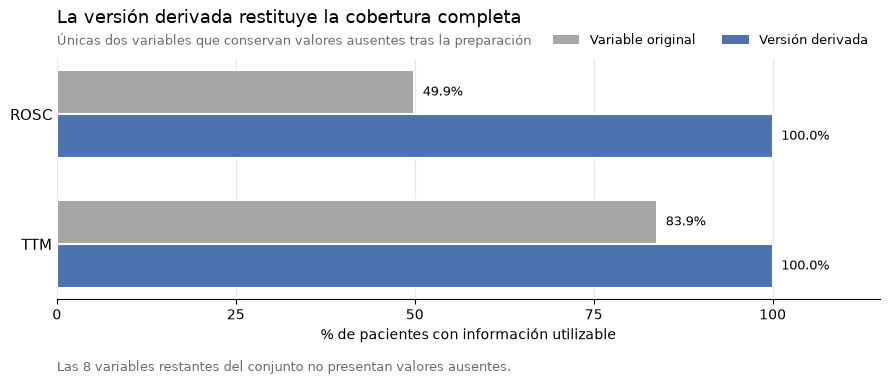

In [ ]:


COLOR_ORIG  = '#A6A6A6'   # gris: variable original
COLOR_DERIV = '#4C72B0'   # azul: versión derivada

pares = [('ROSC', 'ROSC_cat'), ('TTM', 'TTM_cat')]

def cobertura(col):
    return (1 - clinical_std[col].isna().mean()) * 100

fig, ax = plt.subplots(figsize=(9, 4.2))
h = 0.34

for i, (orig, deriv) in enumerate(pares):
    c_orig, c_deriv = cobertura(orig), cobertura(deriv)
    ax.barh(i - h/2, c_orig,  h, color=COLOR_ORIG,  edgecolor='white', linewidth=1.5)
    ax.barh(i + h/2, c_deriv, h, color=COLOR_DERIV, edgecolor='white', linewidth=1.5)
    ax.text(c_orig + 1.2,  i - h/2, f'{c_orig:.1f}%',  va='center', fontsize=9.5)
    ax.text(c_deriv + 1.2, i + h/2, f'{c_deriv:.1f}%', va='center', fontsize=9.5)

ax.set_yticks(range(len(pares)))
ax.set_yticklabels([p[0] for p in pares], fontsize=11)
ax.invert_yaxis()
ax.set_xlim(0, 115)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xlabel('% de pacientes con información utilizable')
ax.xaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis='y', length=0)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

ax.set_title('La versión derivada restituye la cobertura completa',
             fontsize=13, loc='left', pad=26)
ax.text(0, 1.06,
        'Únicas dos variables que conservan valores ausentes tras la preparación',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')

ax.legend(handles=[
    Patch(facecolor=COLOR_ORIG,  label='Variable original'),
    Patch(facecolor=COLOR_DERIV, label='Versión derivada'),
], frameon=False, fontsize=9.5, ncol=2,
   loc='lower right', bbox_to_anchor=(1, 1.0))

# Constancia de que el resto del conjunto está completo
completas = [c for c in clinical_std.columns
             if c not in [x for par in pares for x in par]
             and clinical_std[c].isna().sum() == 0]
incompletas = [c for c in clinical_std.columns
               if c not in [x for par in pares for x in par]
               and clinical_std[c].isna().sum() > 0]

nota = f'Las {len(completas)} variables restantes del conjunto no presentan valores ausentes.'
if incompletas:
    nota = f'Atención: quedan faltantes no previstos en {", ".join(incompletas)}.'

ax.text(0, -0.30, nota, transform=ax.transAxes, fontsize=9, color='#6b6b6b')

plt.tight_layout()
plt.show()

Aunque `ROSC` carece de dato en la mitad de la cohorte, se conserva en el conjunto de análisis en lugar de descartarla por completitud, por tres razones:

- Su ausencia no es aleatoria sino estructural, y el propio patrón de esa ausencia resultó ser uno de los hallazgos del estudio.
- Es, junto con `Shockable Rhythm`, una de las variables con relación más clara con el desenlace en el análisis de asociación de la fase anterior.
- La versión derivada `ROSC_cat` cubre a los 607 pacientes, de modo que la variable sigue siendo utilizable sobre la cohorte completa sin necesidad de imputar.

El porcentaje de faltantes quedó por tanto descartado como criterio de exclusión. Descartar variables por ese motivo habría eliminado justamente la que más información aporta sobre cómo se generaron estos datos. El único caso en que una variable no entra al conjunto de análisis por su naturaleza y no por su calidad es `Patient`, por su papel de identificador.

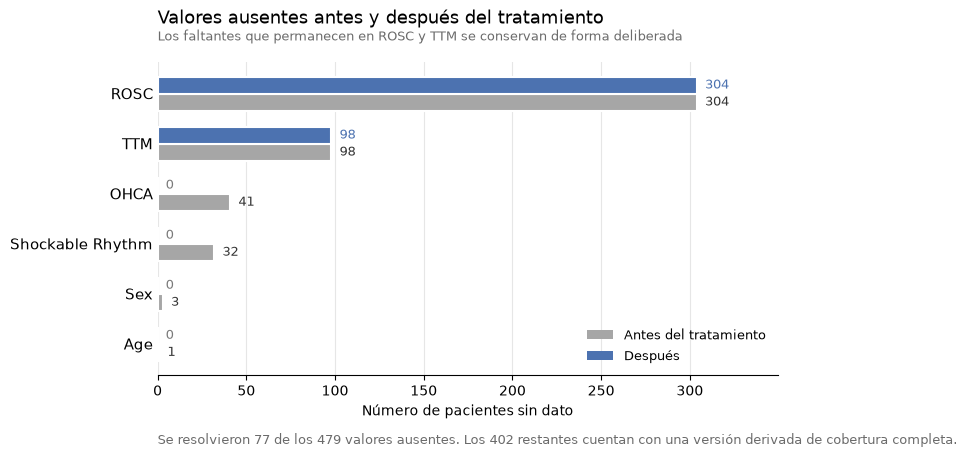

In [ ]:


# ---------------------------------------------------------------------------
# Corrección: la conversión a tipo booleano transformaba la categoría
# 'Desconocido' en nulo, deshaciendo la recodificación de la sección 1.1.
# Se restituyen como categóricas de tres niveles tomando el valor de clinical_df.
# La corrección definitiva va dentro de standardize_clinical.
# ---------------------------------------------------------------------------
for col in ['OHCA', 'Shockable Rhythm']:
    clinical_std[col] = pd.Categorical(clinical_df[col].astype(str),
                                       categories=['True', 'False', 'Desconocido'])

# ---------------------------------------------------------------------------
# Valores ausentes antes y después del tratamiento
# ---------------------------------------------------------------------------
FALTANTES_ANTES = {                       # según la salida de la sección 1.1
    'ROSC': 304, 'TTM': 98, 'OHCA': 41,
    'Shockable Rhythm': 32, 'Sex': 3, 'Age': 1,
}

variables = sorted(FALTANTES_ANTES, key=FALTANTES_ANTES.get)
antes   = [FALTANTES_ANTES[v] for v in variables]
despues = [int(clinical_std[v].isna().sum()) for v in variables]

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(variables))
h = 0.34

ax.barh(y - h/2, antes,   h, color='#A6A6A6', edgecolor='white', linewidth=1.5)
ax.barh(y + h/2, despues, h, color='#4C72B0', edgecolor='white', linewidth=1.5)

tope = max(antes)
for i, (a, d) in enumerate(zip(antes, despues)):
    ax.text(a + tope*0.015, i - h/2, str(a), va='center', fontsize=9.5, color='#333333')
    ax.text(d + tope*0.015, i + h/2, str(d), va='center', fontsize=9.5,
            color='#4C72B0' if d > 0 else '#7a7a7a')

ax.set_yticks(y)
ax.set_yticklabels(variables, fontsize=10.5)
ax.set_xlabel('Número de pacientes sin dato')
ax.set_xlim(0, tope * 1.15)
ax.xaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis='y', length=0)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

ax.set_title('Valores ausentes antes y después del tratamiento',
             fontsize=13, loc='left', pad=28)
ax.text(0, 1.07,
        'Los faltantes que permanecen en ROSC y TTM se conservan de forma deliberada',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')

ax.legend(handles=[
    Patch(facecolor='#A6A6A6', label='Antes del tratamiento'),
    Patch(facecolor='#4C72B0', label='Después'),
], frameon=False, fontsize=9.5, loc='lower right')

resueltos = sum(antes) - sum(despues)
ax.text(0, -0.22,
        f'Se resolvieron {resueltos} de los {sum(antes)} valores ausentes. '
        f'Los {sum(despues)} restantes cuentan con una versión derivada de cobertura completa.',
        transform=ax.transAxes, fontsize=9, color='#6b6b6b')

plt.tight_layout()
plt.show()

assert clinical_std['OHCA'].isna().sum() == 0, "OHCA conserva nulos: revise standardize_clinical"
assert clinical_std['Shockable Rhythm'].isna().sum() == 0, "Shockable Rhythm conserva nulos"

De los 479 valores ausentes que el conjunto tenía una vez decodificados, 77 quedaron resueltos y 402 se conservan de forma deliberada.

Las cuatro variables resueltas siguieron dos criterios distintos. En `Age` y `Sex` la ausencia era marginal, un caso y tres respectivamente, y no mostró asociación con el desenlace, por lo que se imputó con la mediana y la moda. En `OHCA` y `Shockable Rhythm`, con 41 y 32 casos, la ausencia sí llevaba señal propia: el grupo sin dato presentaba una tasa de desenlace favorable que no coincidía con la de ninguna categoría conocida. Imputarlas habría borrado esa información, de modo que la ausencia se conservó como una categoría explícita. Aparecen en cero no porque el dato se haya recuperado, sino porque dejó de ser un nulo para convertirse en un valor con significado.

Las dos variables que permanecen concentran el 84 % del faltante original. `ROSC` carece de valor en la mitad de la cohorte y su ausencia se concentra casi por completo en un hospital, por lo que imputarla habría fabricado una distribución artificial. En `TTM` el nulo refleja sobre todo prácticas de documentación del centro, según mostró el análisis por hospital, y sustituirlo por una temperatura habría introducido una señal administrativa disfrazada de dato clínico. Ambas disponen de una versión derivada que cubre a los 607 pacientes.

El resultado global es que no se eliminó ningún registro por valores faltantes y que ninguna variable del conjunto final queda sin cobertura utilizable.

**¿Qué criterios se utilizaron para seleccionar los datos relevantes?**

El objetivo del proyecto es descriptivo e inferencial: caracterizar la cohorte, explorar las relaciones entre las variables clínicas y el desenlace neurológico, y sostener un modelado estadístico sobre esas relaciones. 

**Relevancia clínica para las preguntas del análisis.** Se conservan las variables que la literatura sobre paro cardíaco asocia con el pronóstico neurológico y que los análisis de la fase de entendimiento confirmaron como relacionadas con el desenlace en esta cohorte. `Shockable Rhythm` fue la de asociación más marcada, coherente con su papel reconocido como indicador pronóstico.

**No redundancia entre variables.** `Outcome` se deriva de `CPC` mediante una regla determinista, verificada sin una sola excepción en los 607 registros. Ambas expresan por tanto la misma información, una en escala ordinal de cinco niveles y otra dicotomizada. Tratarlas como variables independientes en un mismo análisis produciría resultados circulares, de modo que se define un papel para cada una: `Outcome` como variable de respuesta en los análisis de asociación, por su lectura directa, y `CPC` como variable de referencia disponible para los análisis que requieran mayor resolución en la severidad neurológica. La escala ordinal se conserva precisamente porque en un enfoque estadístico aporta detalle que la dicotomización pierde.

**Necesidad para el control de la confusión.** Se conservan las variables que, sin ser el objeto directo del análisis, condicionan la interpretación de las demás. `Hospital` es el caso central: la proporción de desenlace favorable varía entre el 20.3 % y el 46.7 % según el centro, y la ausencia de datos se concentra de forma desigual entre ellos. Sin esta variable no es posible estratificar, y el análisis de `ROSC` mostró que omitirla conduce a conclusiones erróneas. `TTM` cumple una función análoga, al describir el tratamiento recibido y no una característica del paciente.

**Función estructural frente a función analítica.** El identificador del paciente no describe ninguna característica clínica y es único por registro, de modo que no participa en ningún análisis. Se conserva como índice, porque enlaza cada fila con su carpeta de registros fisiológicos.

Un criterio quedó descartado de forma expresa: el porcentaje de valores faltantes. `ROSC` carece de dato en la mitad de la cohorte y aun así se conserva, porque su relevancia clínica es alta y porque el propio patrón de su ausencia resultó ser uno de los hallazgos del estudio. Descartar variables por volumen de faltantes habría eliminado justamente la que más información aporta sobre cómo se generaron estos datos.

**Limitación que la selección arrastra.** La ausencia de `ROSC` no es independiente del centro: falta en el 100 % de los pacientes de un hospital, precisamente el de mejor pronóstico. Cualquier comparación entre pacientes con y sin ese dato está confundida por el centro de procedencia, de modo que las asociaciones en las que intervenga deben estratificarse o interpretarse con esa salvedad. No es un problema resoluble en esta fase, pero condiciona la validez de los análisis posteriores.

**¿Se aplicaron técnicas de muestreo o filtrado para reducir el tamaño del conjunto?**

In [55]:
features = [v for v, (rol, _) in seleccion.items() if rol in ROLES_ANALISIS]
cols_finales = features + ['Outcome']

clinical_prepared = clinical_std.set_index('Patient')[cols_finales].copy()

print(f"Registros conservados: {len(clinical_prepared)} de {len(clinical_std)}")
print(f"Variables seleccionadas: {len(cols_finales)} de {len(clinical_std.columns)}")
print(f"\nPredictoras: {features}")
print(f"Objetivo: Outcome")

assert len(clinical_prepared) == 607, "Se perdieron registros en la selección"
assert 'CPC' not in clinical_prepared.columns, "CPC no debe estar en el conjunto final"
assert clinical_prepared.index.is_unique, "El índice contiene identificadores repetidos"

clinical_prepared.head()

Registros conservados: 607 de 607
Variables seleccionadas: 10 de 12

Predictoras: ['Hospital', 'Age', 'Sex', 'ROSC', 'ROSC_cat', 'OHCA', 'Shockable Rhythm', 'TTM', 'TTM_cat']
Objetivo: Outcome


,Hospital,Age,Sex,ROSC,ROSC_cat,OHCA,Shockable Rhythm,TTM,TTM_cat,Outcome
Patient,,,,,,,,,,
0284,A,53.0,Male,NaN,Sin dato,True,True,33.0,33 °C,Good
0286,F,85.0,Female,7.0,Rápido (1-10 min),False,False,NaN,Sin TTM,Good
0296,A,48.0,Male,NaN,Sin dato,True,True,36.0,36 °C,Good
0299,A,45.0,Male,NaN,Sin dato,True,True,33.0,33 °C,Good
0303,D,51.0,Male,24.0,Intermedio (11-30 min),True,True,33.0,33 °C,Good


**No se aplicó ninguna técnica de muestreo ni filtrado de filas.** Se conservan los 607 pacientes en su totalidad. La justificación es triple.

- El conjunto clínico de I-CARE v2.1 ya es la entrega pública completa, no una muestra mayor de la cual convenga extraer un subconjunto. No existe una población más amplia disponible de la que muestrear, de modo que la pregunta sobre técnicas de muestreo no tiene objeto en este caso.

- El tamaño muestral de 607 pacientes es moderado. Descartar registros por valores faltantes habría reducido la muestra de forma sustancial, y en el caso de `ROSC`, ausente en la mitad de la cohorte, habría implicado perder alrededor de trescientos casos. Ese coste no se justifica cuando existen alternativas que preservan la información, como conservar la ausencia en forma de categoría explícita.

- Eliminar filas con valores faltantes en `ROSC` o `TTM` introduciría un sesgo severo. Ambas ausencias se concentran en centros concretos: `ROSC` falta en el 100 % de los pacientes de un hospital y `TTM` en el 92.8 % de los de otro. Un filtrado por completitud no reduciría la muestra al azar, sino que eliminaría instituciones enteras junto con su perfil de pacientes y su tasa de desenlace, distorsionando tanto la distribución por `Hospital` como la de `Outcome`.

Tampoco se aplicó ninguna técnica de balanceo. El conjunto presenta desbalance entre las dos clases de `Outcome`, documentado en la fase de entendimiento, pero ese desbalance es una característica real de la cohorte y no un defecto que corregir. Alterarlo mediante remuestreo distorsionaría las frecuencias observadas, que son precisamente el objeto de la descripción.

La única reducción aplicada es de columnas, no de filas. Se verifica a continuación que el conjunto preparado conserva los 607 registros.

In [56]:
assert clinical_std.shape[0] == 607, "Se esperaba conservar los 607 pacientes."
print("Registros conservados:", clinical_std.shape[0])

Registros conservados: 607


**¿Cómo se justificó la inclusión o exclusión de cada variable?**

`Outcome` es la variable de respuesta de los análisis de asociación. Su lectura binaria, favorable o desfavorable, es la que da sentido a las comparaciones entre grupos y a las tablas de contingencia del estudio.

`CPC` no se descarta, se aparta. Contiene exactamente la misma información que `Outcome`, dado que esta última se obtiene agrupando los niveles 1 y 2 como desenlace favorable y los niveles 3 a 5 como desfavorable. La verificación del apartado de inconsistencias lo confirmó sin una sola excepción en los 607 registros. Estudiar la relación entre ambas sería por tanto circular, y usarlas a la vez en un mismo análisis duplicaría el mismo contenido bajo dos nombres. Se conserva en un conjunto de referencia separado porque su escala ordinal de cinco niveles ofrece más resolución que la versión dicotomizada, y resulta preferible cuando el análisis se ocupa del grado de severidad neurológica y no solo de su clasificación en dos categorías.

`Patient` pasa a ser el índice del conjunto. Es único por registro y no describe ninguna característica del paciente, de modo que no participa en ningún análisis, pero su formato de cuatro dígitos con ceros a la izquierda coincide con los nombres de las carpetas de registros fisiológicos, correspondencia necesaria al integrar ambas fuentes.

`Age`, `Sex`, `OHCA`, `Shockable Rhythm` y `ROSC` se incluyen por su relevancia clínica documentada en la literatura sobre paro cardíaco y por haber mostrado relación con el desenlace en los análisis de la fase de entendimiento. `Shockable Rhythm` fue la de asociación más marcada, coherente con su papel reconocido como indicador pronóstico.

`TTM` se incluye con una lectura distinta de las anteriores. No describe una característica del paciente sino el tratamiento que recibió, de modo que en los análisis funciona como variable de intervención y no como rasgo basal. Su ausencia resultó además informativa por sí misma, según mostró la comparación por centro.

`ROSC_cat` y `TTM_cat` se conservan junto a sus variables de origen porque son dos representaciones de la misma información con usos complementarios. La versión numérica permite describir la distribución real del tiempo de reanimación y de la temperatura objetivo en los pacientes que tienen el dato. La versión categórica cubre a los 607 e incorpora la ausencia como una categoría con significado, lo que la hace apta para las tablas y gráficos que deben representar a la cohorte completa. Esto mantiene la coherencia con lo decidido en el apartado de valores faltantes, donde se justificó no imputar precisamente porque estas derivadas garantizaban cobertura total. La regla de uso es que un mismo análisis emplee una de las dos representaciones por variable, nunca ambas, para no contar dos veces la misma información.

`Hospital` se incluye por una razón distinta a las demás y es indispensable. No es un rasgo clínico del paciente sino el factor que permite estratificar. La proporción de desenlace favorable varía entre el 20.3 % y el 46.7 % según el centro, y la completitud del registro varía todavía más: `ROSC` falta en el 100 % de los pacientes de un hospital y en el 0 % de los de otro. Sin esta variable no es posible separar el efecto de una característica clínica del efecto del centro de procedencia. El análisis de `ROSC` lo demostró de forma concreta: la asociación aparente entre la falta del dato y un mejor desenlace se explicaba en buena parte por el centro, y solo se hizo visible al estratificar.

**Una limitación que la selección arrastra**

La ausencia de `ROSC` no es independiente del hospital, sino que se concentra por completo en el centro con mejor pronóstico. Cualquier comparación entre pacientes con y sin ese dato está confundida por el centro de procedencia, de modo que no puede interpretarse como una diferencia clínica. La consecuencia práctica es que los análisis en los que intervenga esa variable deben estratificarse por hospital o acompañarse de esa salvedad de forma explícita. No es un problema resoluble en esta fase, y tampoco se resuelve retirando la variable, porque el patrón sobrevive en cualquier indicador de ausencia que se construya a partir de ella. Queda declarado para que la interpretación de los resultados lo tenga en cuenta.

### Conclusión de la limpieza de datos (metadatos clínicos)

**¿Cuáles fueron los criterios utilizados para identificar y tratar valores atípicos, datos faltantes o cualquier otra anomalía?**

La identificación se apoyó en tres principios. El primero fue no confiar en las funciones estándar sin contrastarlas: `isnull()` reportaba cero ausencias sobre un conjunto que tenía 479, y solo la verificación cruzada contra los valores únicos de cada columna reveló que el faltante viajaba escrito como la palabra `nan`. El segundo fue combinar un criterio estadístico con uno de dominio: el rango intercuartílico señala lo infrecuente, mientras que los rangos clínicamente admisibles señalan lo imposible, y la diferencia resultó decisiva cuando el IQR propuso para `ROSC` un límite inferior negativo. El tercero fue examinar cada anomalía en varios niveles antes de concluir, como en los duplicados, donde la comprobación estándar resultaba inservible por incluir el identificador único y hubo que repetirla ignorándolo.

El tratamiento se rigió por cuatro criterios aplicados en cada decisión:

1. **Volumen de la anomalía.** Una ausencia de 1 caso en `Age` y 3 en `Sex` admite imputación sin consecuencias; una de 304 casos en `ROSC` no.
2. **Contenido informativo de la anomalía.** Se comprobó en cada variable si el grupo afectado se comportaba de forma distinta frente al desenlace. Cuando la ausencia llevaba señal propia, como en `OHCA` y `Shockable Rhythm`, imputarla habría borrado información, de modo que se conservó como categoría explícita.
3. **Significado en el dominio.** Un valor de `ROSC` de 111 minutos es infrecuente pero clínicamente posible, y un paciente de 16 años con paro cardíaco también. Ninguno es un error de captura, y por eso ninguno se corrigió.
4. **Coste de la alternativa, cuantificado antes de decidir.** Se midió el efecto de cada opción antes de descartarla: eliminar duplicados habría borrado 49 pacientes reales y reducido un hospital en un 18.8 %; imputar `Shockable Rhythm` con la moda habría clasificado mal a una parte apreciable del grupo sin dato; el tratamiento de `Sex` se validó mostrando que la diferencia máxima entre imputar y eliminar era de 0.15 puntos porcentuales.

De ahí se deriva el principio transversal de toda la fase: **intervención mínima y justificada**. No se eliminó ningún registro en ninguno de los seis apartados, y las modificaciones se limitaron a la representación de los datos, no a su contenido.

**¿Cómo se justifica cada paso en términos de calidad y de preparación para el análisis?**

| Paso | Problema que resuelve | Qué habilita |
|---|---|---|
| Decodificación del faltante | Las 479 ausencias eran invisibles para `isnull()` | Que cualquier medida de completitud sea válida |
| Conversión de tipos | Variables numéricas almacenadas como texto | Estadísticos descriptivos, detección de atípicos y gráficos |
| Imputación de `Age` y `Sex` | 4 ausencias marginales sin asociación con el desenlace | Que 4 pacientes no se pierdan en análisis que exigen completitud |
| Recodificación de `OHCA` y `Shockable Rhythm` | La ausencia llevaba señal propia sobre el desenlace | Conservar esa señal en lugar de diluirla con la moda |
| Derivación de `ROSC_cat` y `TTM_cat` | Ausencias masivas imposibles de imputar | Cobertura de los 607 pacientes sin inventar valores |
| Verificación de duplicados en tres niveles | 49 perfiles idénticos que parecían repeticiones | Evitar la pérdida de 49 pacientes reales |
| Revisión de atípicos por criterio clínico | 24 valores extremos señalados por el IQR | Conservar información válida pero excepcional |
| Reglas de validación con aserciones | La consistencia dependía de una revisión manual | Que se compruebe en cada ejecución del notebook |
| Selección de variables y persistencia | Redundancia entre `CPC` y `Outcome`; tipos perdidos al guardar | Un conjunto reutilizable desde otros notebooks |

Cada paso responde por tanto a un defecto concreto y verificado, no a una rutina aplicada por costumbre. Ninguna técnica se empleó por figurar en el repertorio habitual: la imputación se descartó donde habría falseado la variable, la eliminación de duplicados y de atípicos se descartó donde habría destruido información legítima, y el muestreo no procedía sobre un conjunto que ya es la entrega completa.

El resultado es un conjunto de 607 pacientes íntegros, sin ausencias salvo las conservadas de forma deliberada y con cobertura alternativa, tipado de acuerdo con la naturaleza de cada variable, verificado mediante reglas ejecutables y guardado en un formato que preserva esa preparación.



### Construcción del conjunto preparado

Se construye el conjunto que alimentará las etapas siguientes aplicando las decisiones de este apartado: `Patient` pasa a ser el índice, `CPC` se traslada a un conjunto de referencia separado, y el resto de las variables, ya estandarizadas en el apartado 1.4, conforman el conjunto de análisis junto con la variable de respuesta `Outcome`.

Las variables derivadas `ROSC_cat` y `TTM_cat` se incluyen junto a sus originales. Dejarlas fuera vaciaría el argumento del apartado de valores faltantes, donde se justificó no imputar precisamente porque estas versiones garantizan cobertura sobre los 607 pacientes. Cada análisis posterior debe emplear una de las dos representaciones por variable, nunca ambas a la vez.

In [57]:
feature_cols = ["Hospital", "Age", "Sex", "ROSC", "ROSC_cat",
                "OHCA", "Shockable Rhythm", "TTM", "TTM_cat"]

clinical_prepared = (
    clinical_std
    .set_index("Patient")[feature_cols + ["Outcome"]]
)

cpc_reference = clinical_std.set_index("Patient")[["CPC"]]

print(f"clinical_prepared: {clinical_prepared.shape[0]} registros, "
      f"{clinical_prepared.shape[1]} columnas")
print(f"  {len(feature_cols)} variables de análisis + 1 variable de respuesta\n")
print(f"Identificador trasladado al índice: Patient")
print(f"Variable apartada como referencia: CPC -> cpc_reference {cpc_reference.shape}\n")

assert len(clinical_prepared) == 607, "Se perdieron registros en la selección"
assert clinical_prepared.index.is_unique, "El índice contiene identificadores repetidos"
assert 'CPC' not in clinical_prepared.columns, "CPC no debe estar en el conjunto de análisis"
assert clinical_prepared['ROSC_cat'].isna().sum() == 0, "ROSC_cat no cubre a toda la cohorte"
assert clinical_prepared['TTM_cat'].isna().sum() == 0, "TTM_cat no cubre a toda la cohorte"
print("Verificación superada: cobertura completa y sin pérdida de registros.")

clinical_prepared.head()

clinical_prepared: 607 registros, 10 columnas
  9 variables de análisis + 1 variable de respuesta

Identificador trasladado al índice: Patient
Variable apartada como referencia: CPC -> cpc_reference (607, 1)

Verificación superada: cobertura completa y sin pérdida de registros.


,Hospital,Age,Sex,ROSC,ROSC_cat,OHCA,Shockable Rhythm,TTM,TTM_cat,Outcome
Patient,,,,,,,,,,
0284,A,53.0,Male,NaN,Sin dato,True,True,33.0,33 °C,Good
0286,F,85.0,Female,7.0,Rápido (1-10 min),False,False,NaN,Sin TTM,Good
0296,A,48.0,Male,NaN,Sin dato,True,True,36.0,36 °C,Good
0299,A,45.0,Male,NaN,Sin dato,True,True,33.0,33 °C,Good
0303,D,51.0,Male,24.0,Intermedio (11-30 min),True,True,33.0,33 °C,Good


In [ ]:


def localizar_raiz(marcas=('requirements.txt', '.git', 'data')):
    """Sube desde el directorio actual hasta encontrar la raíz del repositorio."""
    actual = Path.cwd().resolve()
    for carpeta in [actual, *actual.parents]:
        if any((carpeta / m).exists() for m in marcas):
            return carpeta
    return actual

PROJECT_ROOT  = localizar_raiz()
DATA_DIR      = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Datos procesados:  {PROCESSED_DIR}")

Raíz del proyecto: C:\Users\aleja\Documents\maestria\proyecto+\mlda-project_
Datos procesados:  C:\Users\aleja\Documents\maestria\proyecto+\mlda-project_\data\processed


In [59]:
# ---------------------------------------------------------------------------
# Persistencia del conjunto preparado
# ---------------------------------------------------------------------------
output_path    = PROCESSED_DIR / "clinical_prepared.csv"
reference_path = PROCESSED_DIR / "cpc_reference.csv"
parquet_path   = PROCESSED_DIR / "clinical_prepared.parquet"

clinical_prepared.to_csv(output_path)
cpc_reference.to_csv(reference_path)

# Parquet almacena los tipos y el orden de las categóricas junto con los datos.
# Requiere pyarrow; si no está disponible, el CSV sigue siendo válido con el esquema.
try:
    clinical_prepared.to_parquet(parquet_path)
    parquet_ok = True
except ImportError:
    parquet_ok = False

# ---------------------------------------------------------------------------
# Esquema de lectura del CSV
# ---------------------------------------------------------------------------
ESQUEMA_CLINICO = {
    'Patient':          'string',
    'Hospital':         'category',
    'Sex':              'category',
    'Outcome':          'category',
    'OHCA':             'category',
    'Shockable Rhythm': 'category',
    'ROSC_cat':         'category',
    'TTM_cat':          'category',
}

# El CSV conserva las categorías pero no su relación de orden, que debe redeclararse
ORDEN_ROSC_CAT = ['Rápido (1-10 min)', 'Intermedio (11-30 min)',
                  'Prolongado (>30 min)', 'Sin dato']


def cargar_clinical_prepared(ruta=output_path):
    """Relee el conjunto preparado desde el CSV restituyendo tipos y orden."""
    df = pd.read_csv(ruta, dtype=ESQUEMA_CLINICO, index_col='Patient')
    df['ROSC_cat'] = pd.Categorical(df['ROSC_cat'],
                                    categories=ORDEN_ROSC_CAT, ordered=True)
    return df


# ---------------------------------------------------------------------------
# Verificación de ida y vuelta: el archivo debe devolver lo que se guardó
# ---------------------------------------------------------------------------
prueba = cargar_clinical_prepared()

assert len(prueba) == len(clinical_prepared), \
    "El archivo no conserva todos los registros"
assert prueba.index[0] == clinical_prepared.index[0], \
    "El índice perdió los ceros a la izquierda: no se aplicó el esquema de lectura"
assert list(prueba.columns) == list(clinical_prepared.columns), \
    "Las columnas leídas no coinciden con las guardadas"
assert prueba['ROSC_cat'].isna().sum() == 0, \
    "ROSC_cat perdió valores al releer: revise ORDEN_ROSC_CAT"
assert prueba['ROSC_cat'].cat.ordered, \
    "ROSC_cat perdió su relación de orden"

# ---------------------------------------------------------------------------
# Reporte
# ---------------------------------------------------------------------------
print("Archivos generados")
print(f"  {output_path.name:32s} conjunto de análisis (texto legible)")
print(f"  {reference_path.name:32s} escala CPC de referencia")
if parquet_ok:
    print(f"  {parquet_path.name:32s} conjunto de análisis con tipos preservados")
else:
    print("  (No se generó el Parquet: falta la librería pyarrow.")
    print("   El CSV sigue siendo válido siempre que se lea con cargar_clinical_prepared.)")

print(f"\nVerificación de lectura")
print(f"  Registros: {len(prueba)}")
print(f"  Columnas:  {prueba.shape[1]}")
print(f"  Índice:    '{prueba.index[0]}' (ceros a la izquierda íntegros)")
print(f"  ROSC_cat:  categórica ordenada, {len(prueba['ROSC_cat'].cat.categories)} niveles")
print("\nEl conjunto preparado es reutilizable desde otro notebook sin pérdida de tipificación.")

Archivos generados
  clinical_prepared.csv            conjunto de análisis (texto legible)
  cpc_reference.csv                escala CPC de referencia
  (No se generó el Parquet: falta la librería pyarrow.
   El CSV sigue siendo válido siempre que se lea con cargar_clinical_prepared.)

Verificación de lectura
  Registros: 607
  Columnas:  10
  Índice:    '0284' (ceros a la izquierda íntegros)
  ROSC_cat:  categórica ordenada, 4 niveles

El conjunto preparado es reutilizable desde otro notebook sin pérdida de tipificación.


**Sobre la persistencia del formato**

El formato CSV almacena texto plano y no conserva los tipos. Al releer el archivo sin declarar un esquema, el identificador perdería sus ceros a la izquierda y volvería como número entero, rompiendo la correspondencia con las carpetas de registros fisiológicos, y las variables categóricas regresarían a cadenas sin dominio declarado. Por ese motivo el conjunto se guarda también en formato Parquet, que almacena los tipos junto con los datos, y se documenta el esquema de lectura del CSV.

La verificación de ida y vuelta comprueba que el archivo escrito devuelve exactamente lo que se guardó. No es una formalidad: garantiza que el conjunto preparado es reutilizable desde otro notebook y no solo válido dentro de la sesión en la que se creó.

### Resumen de la fase de preparación (metadatos clínicos)

| Aspecto | Antes (fase 02) | Después (fase 03) |
|---|---|---|
| Registros | 607 | 607, ninguno eliminado en toda la fase |
| Columnas | 10, todas almacenadas como texto | 9 de análisis y 1 de respuesta, tipadas y validadas |
| Tipos de dato | sin inferencia; numéricas y lógicas como cadenas | esquema declarado: numérico, categórico y ordinal según la naturaleza de cada variable |
| Codificación del faltante | palabra `nan` escrita como texto, invisible para `isnull()` | nulo nativo de pandas y categorías explícitas donde la ausencia tiene significado |
| Valores faltantes | 479 reales, 0 detectados | 77 resueltos por imputación o recodificación; 402 conservados de forma deliberada en `ROSC` y `TTM`, con versión derivada de cobertura completa |
| `CPC` | mezclada con las demás variables | separada en un conjunto de referencia, por contener la misma información que `Outcome` en escala ordinal |
| Dominios categóricos | sin declarar | `category` con dominio cerrado y validado |
| Duplicados | no evaluados | 0 identificadores repetidos y 0 registros idénticos |
| Valores atípicos | no evaluados | revisados por criterio clínico; ninguno corregido. Documentada la censura de `Age` en 90 años |
| Inconsistencias | no evaluadas | 0 violaciones en reglas de dominio, rango, unicidad y coherencia entre variables |
| Datos corruptos | no evaluados | 0 indicios, con panel de integridad reproducible |
| Heterogeneidad entre centros | no documentada | cuantificada y declarada: la completitud del registro y la tasa de desenlace varían de forma marcada según el hospital |
| Persistencia | sin conjunto preparado | `clinical_prepared` en CSV y Parquet, con esquema de lectura verificado |

**Limitaciones que la fase deja abiertas**

La ausencia de `ROSC` se concentra por completo en un hospital, que además es el de mejor pronóstico, de modo que cualquier comparación entre pacientes con y sin ese dato está confundida por el centro de procedencia. La censura de `Age` en 90 años es irreversible y obliga a interpretar la variable como "90 años o más" en su tramo final. Y la verificación de integridad es indirecta, al no haberse contrastado las sumas de comprobación del repositorio de origen. Ninguna de las tres es resoluble en esta fase; se declaran para que condicionen la interpretación de los análisis posteriores.

**Próximos pasos**

La preparación de los registros fisiológicos EEG, que requiere descarga desde PhysioNet, segmentación por ventanas temporales y extracción de características de señal, se desarrollará en un notebook independiente, dado el volumen de datos y la naturaleza distinta de su procesamiento frente a los metadatos clínicos aquí preparados.

# Records

### Faltantes

### Duplicados

### Atipicos

### Inconsistentes

### Corruptos

### Selección de los datos

### Preprocesamiento y transformación

## **Créditos**
* **Profesor:** [Felipe Restrepo Calle](https://dis.unal.edu.co/~ferestrepoca/)
* **Asistentes docentes:**
    - [Juan Sebastián Lara Ramírez](https://www.linkedin.com/in/juan-sebastian-lara-ramirez-43570a214/).
* **Diseño de imágenes:**
    - [Rosa Alejandra Superlano Esquibel](mailto:rsuperlano@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).
    
**Universidad Nacional de Colombia** - *Facultad de Ingeniería*